In this notebook, I try to simulate spectra using FSPS to produce spectra like COSMOS-dw1 to see what would happen .. 

The goal of this notebook is to understand if using redrock it is possible to identify quenched dwarf galaxies at some reasonable fiber mags .. 

In [1]:
# import sys
# !{sys.executable} -m pip install specutils


In [2]:
# import sys
# !{sys.executable} -m pip install fsps

import numpy as np
from astropy.cosmology import Planck18
from astropy import units as u
from scipy.interpolate import interp1d
from astropy.convolution import convolve, Gaussian1DKernel
from astropy.io import fits
from astropy.table import Table
import sys
import os
import pandas as pd
rootdir = '/global/u1/v/virajvm/'
sys.path.append(os.path.join(rootdir, 'DESI2_LOWZ'))
from desi_lowz_funcs import read_vac_line_info, make_subplots

import matplotlib as mpl
from matplotlib.colors import LogNorm

mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['axes.xmargin'] = 1
mpl.rcParams['xtick.labelsize'] = 'x-large'
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['ytick.labelsize'] = 'x-large'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.major.width'] = 1.5
mpl.rcParams['legend.frameon'] = False


def plt_between(ax, xvals, med, err,color="k",alpha=0.2,plot_med=True,label = None,ls = "-"):
    ax.plot(xvals, med,color = color,label = label,ls = ls)
    ax.fill_between(xvals, med - err,med + err,alpha = alpha, color =color )
    return


### do the full redshift range from z = 0 to z0.15
import speclite.filters
decam = speclite.filters.load_filters('decam2014-r','decam2014-z' )


def catas_redshift(z_true, z_meas,cut = 0.0033):
    '''
    The fidicual cut is for redshift to be consistent to within 1000 km/s. Function returns True if redshift is consistent
    '''
    
    temp_vals = np.abs(z_true - z_meas) / (1 + z_true)
    
    return (temp_vals < cut)



def get_purity_fracs(sum_tab, dchi2_bins, dchi2_lab=None, zwarn_lab = None, zrr_lab = None,return_catas_frac=False):
    '''
    
    Interestingly, it seems that even if one gets non 0/4 ZWARN flags, in the forward model spectra I do not get those?? Not sure why ... 
    Is there a reason for this? This could be hinting at some problem??
    '''
    purity_frac_900 = []
    purity_frac_900_err = []
    
    for i in range(len(dchi2_bins)-1):
        #filter for the relevant objects

        temp_sum = sum_tab[ (sum_tab[dchi2_lab] > dchi2_bins[i]) & (sum_tab[dchi2_lab] < dchi2_bins[i+1])]

        #then we need to get all the objects that have ZWARN = 0 or ZWARN = 4
        
        temp_sum = temp_sum[(temp_sum[zwarn_lab] == 0) | (temp_sum[zwarn_lab] == 4)]
        
        #then we find the redshifs with catastrophic failures
        if return_catas_frac == False:
            isgood_zred = catas_redshift(temp_sum["Z"], temp_sum[zrr_lab])
        if return_catas_frac:
            isgood_zred = ~catas_redshift(temp_sum["Z"], temp_sum[zrr_lab])
        
        #then compute the purity fraction
        pure_frac = np.sum(isgood_zred)/len(isgood_zred)

        purity_frac_900.append(pure_frac)
        purity_frac_900_err.append(  np.sqrt( pure_frac * (1-pure_frac) / len(isgood_zred) ) )
        
        
    return purity_frac_900, purity_frac_900_err




def get_line_flux(ssp_obj,line="Ha",zred=0.005,Lgal = 2e7,use_redshift=False):
    halpha_w = 6564.61
    emline_waves = ssp_obj.emline_wavelengths
    emline_lumis = ssp_obj.emline_luminosity
    
    line_lumi = emline_lumis[ np.abs(emline_waves - halpha_w) < 1 ]
        
    if use_redshift:
        dist_cm = Planck18.luminosity_distance(zred).to(u.cm).value

        flux_factor = 1/(4*np.pi*dist_cm**2)
    
        return line_lumi * Lsolar * Lgal * flux_factor 
    else:
        
        return line_lumi * Lsolar * Lgal

    
Lsolar = 3.826e33 #erg/s


def get_spectrum(ssp_obj,age,zred=0.001,Lgal = 2e7,use_redshift=False):
    '''
    Scale the flux in the spectrum to account for redshift luminosity distance and galaxy luminosity 
    '''
    # ssp_obj.params["zred"] = zred
    # it seems like the redshift parameter is not changing the flux at all??
    # the flux is always returned in solar luminosities, but that should still impact the spectrum amplitude 
    # it also not redshifting the wavelenght.
    ## so the zred parameter does nothing to the get_spectrum function ...
    
    wave, flux = ssp_obj.get_spectrum(tage = age, peraa = True)
    wave_2 = wave[(wave > 2000) & (wave < 2e4)]
    flux_2 = flux[(wave > 2000) & (wave < 2e4)]
    

    if use_redshift == False:
        #no correction for redshift and stuff
        return wave_2, flux_2 * Lsolar * Lgal 
    
    else:
        #computing luminosity distance stuff
        dist_cm = Planck18.luminosity_distance(zred).to(u.cm).value
        flux_factor = 1/(4*np.pi*dist_cm**2)
    
        return wave_2*(1+zred), flux_2 * Lsolar * Lgal * flux_factor 


def add_scores(file_path,cts = 100):
    with fits.open(file_path, mode='update') as hdulist:
        # open a random hdu
        table_hdu = fits.open("/pscratch/sd/v/virajvm/lowz_mock_spectra/temp_lowz_object_1.fits")["SCORES"]
        # Get the data and slice to only include the first two rows
        original_data = table_hdu.data
        new_data = original_data[:cts]
        new_table_hdu = fits.BinTableHDU(data=new_data, header=table_hdu.header)
        hdulist.append(new_table_hdu)
        hdulist.flush()  # This writes the updates to the file
        
    return


ModuleNotFoundError: No module named 'desi_lowz_funcs'

In [1]:
import matplotlib.pyplot as plt
import fsps
from tqdm import trange


RuntimeError: SPS_HOME environment variable '/global/u1/v/virajvm/fsps/' is not a directory

In [4]:
halpha_w = 6564.61
hbeta_w = 4861.333

### Generating mock FSPS spectrum that are similar to that of COSMOS dw-1 or quenched dwarfs ..

In [599]:
# age: 0.5, 1, 1.5, 2, 3.5, 8 Gyr
# [Fe/H]: -2, -1.5, -1
# smoothing to resolution of LRIS in wavelength space

# ssp = fsps.StellarPopulation(sfh = 1,tau=3,smooth_velocity = True,sigma_smooth = 50,dust_type=2, dust2=0.2)

ssp_neb2 = fsps.StellarPopulation(zcontinuous = 1, add_neb_emission = 1, dust_type = 2, dust2= 0.2, sfh=1,tau=1)


In [603]:

#for no nebular model
# ssp.params['logzsol'] = -2.5 # stellar population metallicity

##for nebular model
ssp_neb2.params['logzsol'] = -1.5
# # set parameters for nebular model
ssp_neb2.params['gas_logz'] = -1.5 # gas metallicity
ssp_neb2.params['gas_logu'] = -1.5 # ionization parameter

In [604]:
##get a sample spectrym

age = 1 # 3 Myr (in units of Gyr)
# lam, spec = ssp.get_spectrum(peraa=True, tage=age) 
lam, espec = ssp_neb2.get_spectrum(peraa=True, tage=age)


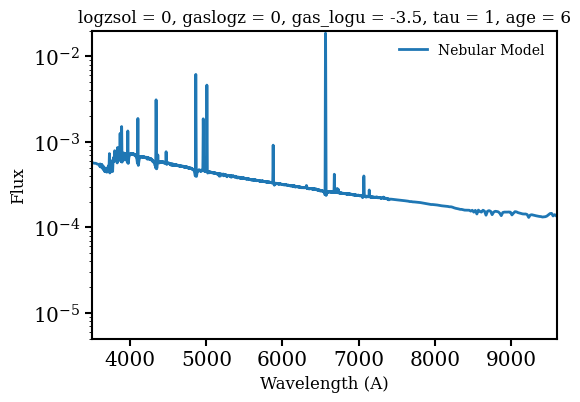

In [605]:

fig, ax = plt.subplots(1,1, figsize=(6,4))
plt.title("logzsol = 0, gaslogz = 0, gas_logu = -3.5, tau = 1, age = 6")
# ax.loglog(lam, spec, label='No Nebular Model', lw=2)
ax.plot(lam, espec, label='Nebular Model', lw=2)
ax.set_xlim([3500., 9600.])
ax.set_ylim(5e-6, 2e-2)
plt.yscale("log")
ax.legend(loc=0, frameon=False)
ax.set_xlabel(r'Wavelength (A)', size=12)
ax.set_ylabel(r'Flux', size=12)
plt.show()

In [486]:
ssp_neb2.emline_luminosity[np.abs(ssp_neb2.emline_wavelengths - hbeta_w) < 5]

array([0.02061461])

In [487]:
ssp_neb2.emline_luminosity[np.abs(ssp_neb2.emline_wavelengths - halpha_w) < 1]

array([0.06395191])

In [41]:
# spl.integral(6587,6610) - spl.integral(6550,6550+23)
ssp_neb.emline_luminosity.shape

(166,)

In [39]:
## what is the emission line flux as given by the ssp object

ssp_neb.emline_luminosity[np.abs(ssp_neb.emline_wavelengths - halpha_w) < 1]


array([0.00109576])

In [16]:
zred = 0.005
dist_cm = Planck18.luminosity_distance(zred).to(u.cm).value
flux_factor = 1/(4*np.pi*dist_cm**2)
Lgal = 2e7

print(0.01260529 * Lsolar *  Lgal * flux_factor)

1.6299807515392576e-14


In [17]:
## looks like the flux computed these two different ways is making sense!!

In [ ]:
def get_line_flux(ssp_obj,line="Ha",zred=0.005,Lgal = 2e7,use_redshift=False):
    halpha_w = 6564.61
    emline_waves = ssp_obj.emline_wavelengths
    emline_lumis = ssp_obj.emline_luminosity
    
    line_lumi = emline_lumis[ np.abs(emline_waves - halpha_w) < 1 ]
        
    if use_redshift:
        dist_cm = Planck18.luminosity_distance(zred).to(u.cm).value

        flux_factor = 1/(4*np.pi*dist_cm**2)
    
        return line_lumi * Lsolar * Lgal * flux_factor 
    else:
        
        return line_lumi * Lsolar * Lgal

In [ ]:
get_line_flux(ssp_neb)

array([1.6299803e-14])

## Make sure magnitudes are going well as well

I think the best think to do is to compute magnitudes in a post process step by just shifting the flux etc. 


In [140]:
sdss_bands = ['sdss_g', 'sdss_r', 'sdss_z']
# ssp_neb.params["zred"] = 0.005
# print(ssp_neb.get_mags(tage=5, bands=sdss_bands,redshift = 0.005))


In [202]:
ssp_neb.get_mags(tage=5, bands=sdss_bands) - 2.5*np.log10(2e7)


array([18.42807673, 18.21980033, 18.29417337])

In [94]:
# ## set cosmology here 
# from astropy.cosmology import FlatLambdaCDM
# cosmo = FlatLambdaCDM(H0=70, Om0=0.3, Tcmb0=2.725)

# ## can I accurate capture the effect of redshift here??
# # dist_cm = Planck18.luminosity_distance(0.005).to(u.cm).value   
# # dist_cm = cosmo.luminosity_distance(0.005).to(u.cm).value    

# # flux_factor1 = 1/(4*np.pi*dist_cm**2)

# # dist_10pc = (10*u.pc).to(u.cm).value
# # flux_factor2 = 1/(4*np.pi*dist_10pc**2)


In [141]:
import speclite
import speclite.filters

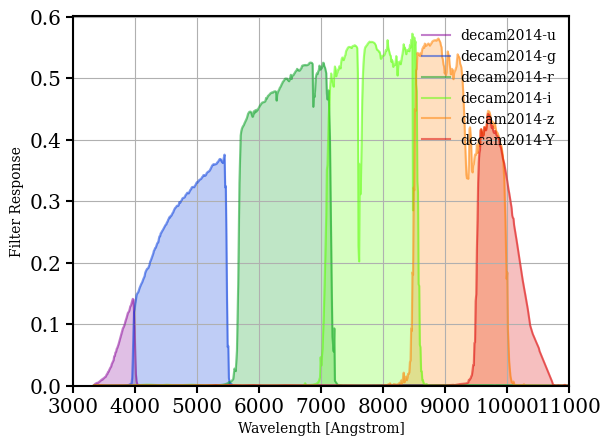

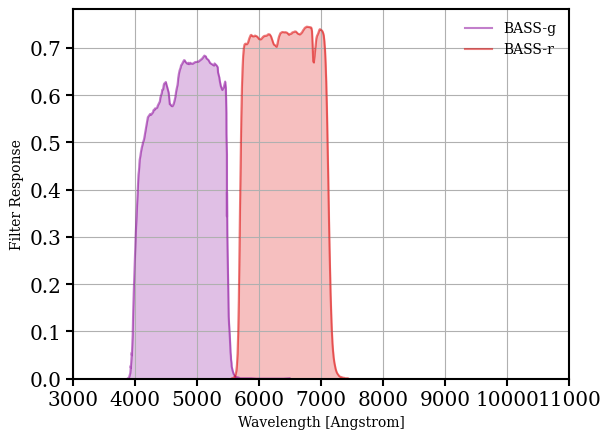

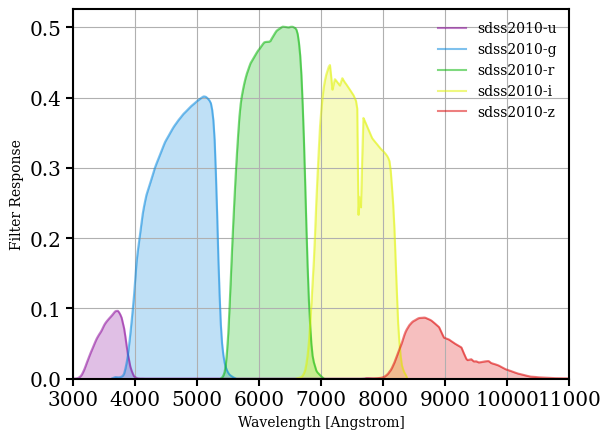

In [142]:
decam = speclite.filters.load_filters('decam2014-*')
bass = speclite.filters.load_filters('BASS-*')
sdss = speclite.filters.load_filters('sdss2010-*')

speclite.filters.plot_filters(decam, wavelength_limits=(3000, 11000))
speclite.filters.plot_filters(bass, wavelength_limits=(3000, 11000))
speclite.filters.plot_filters(sdss, wavelength_limits=(3000, 11000))

###### Can I convolve the spectra with the filters to get magnitudes directly?

In [62]:
# https://speclite.readthedocs.io/en/latest/api.html#filters-api 
## let use the decam filters 

wlen = wave_new5 * u.Angstrom
flux = flux_new5 * u.erg / (u.cm**2 * u.s * u.Angstrom)

mags_decam = decam.get_ab_magnitudes(flux, wlen)
mags_bass = bass.get_ab_magnitudes(flux, wlen)
mags_sdss = sdss.get_ab_magnitudes(flux, wlen)

print(mags["decam2014-r"].data)
print(mags_bass["BASS-r"].data)
print(mags_sdss["sdss2010-r"].data)

[18.36374939]
[18.3647099]
[18.35031845]


How do I know this is correct though? I should confirm by taking a real spectrum and then convoling this with that ...

In [149]:
## example check ...

# g=21.07, r=20.54, z=20.14
tgid_i = 39627629048890596
specdata, zcat_sel = get_spectra(tgid_i,zpix_cat,plot=False)
# I need an aperture correction factor here 


[0.10345777] [2745.06156158]
Number of spectra found =  1
INFO:spectra.py:291:read_spectra: iotime 0.206 sec to read coadd-sv1-bright-22731.fits at 2024-10-20T16:04:31.142705


In [189]:
flux_rd = np.concatenate(([0], specdata.flux["brz"][0] , [0] ) )
wave_rd = np.concatenate( ([3000],specdata.wave["brz"] , [110000] ))


# I need an aperture correction factor here 
#this is obtaind for this object 
flux_real = 1.68 * flux_rd * 1e-17 * u.erg / (u.cm**2 * u.s * u.Angstrom)
wave_real =  wave_rd *  u.Angstrom

In [196]:

decam = speclite.filters.load_filters('decam2014-r','decam2014-z' )
mags_decam = decam.get_ab_magnitudes(flux_real, wave_real)
mags_bass = bass.get_ab_magnitudes(flux_real, wave_real)

print(mags_decam["decam2014-r"].data)
print(mags_bass["BASS-r"].data)

## this magnitude is similar to the actual magnitude! Same for g-band magnitude!!
## this comparison is not entirely accurate as we should be using decam filters .. 

[20.49356549]
[20.49944524]


## Get code to generate a wide range of mock spectra to do mock simulations with 

We will span some range in ionization parameters, metallicity, tau values, and ages 

In [154]:
zmetals = np.array([-1,-0.75,-0.5,-0.25]) #4
gas_logus = np.array([-3, -2.5, -2.0, -1.5, -1.0]) #5
tau = np.array([2])
ages = np.arange(5,12,0.5) # 

##we will keep the velocity dispersions and dust same for now.

In [7]:
ssp_cont = fsps.StellarPopulation(zcontinuous = 1,smooth_velocity = True,sigma_smooth = 50, dust_type = 2, dust2= 0.2, sfh=1)


In [156]:
len(ages)

14

In [ ]:
#for now we are just going to generate the mock spectra and save them ...
# ssp_neb = fsps.StellarPopulation(zcontinuous = 1, add_neb_emission = 1, 
#                                  smooth_velocity = True,sigma_smooth = 50, dust_type = 2, dust2= 0.2, sfh=1)

from tqdm.notebook import trange

all_logz = []
all_logu = []
all_tau = []
all_age = []
all_halpha_flux = []
all_Lgals = []

save_path = "fsps_model_spectra/"

index = 0

for zi in trange(len(zmetals)):
    for ui in range(len(gas_logus)):
        for ti in range(len(tau)):
            #setting up the spectra object
            zmet_i = zmetals[zi]
            logu_i = gas_logus[ui]
            tau_i = tau[ti]

            ## setting the parameters now 
            ssp_cont.params['logzsol'] = zmet_i
            # # set parameters for nebular model
            ssp_cont.params['gas_logz'] = zmet_i # gas metallicity
            ssp_cont.params['gas_logu'] = logu_i # ionization parameter
            ssp_cont.params["tau"] = tau_i
            
            print(ssp_cont.params["logzsol"],ssp_cont.params['gas_logz'],ssp_cont.params['gas_logu'],ssp_cont.params["tau"]  )
            #then go over all the ages
            for ai in range(len(ages)):
                ages_i = ages[ai]
                
                #save all the useful info
                all_logz.append(zmet_i)
                all_logu.append(logu_i)
                all_tau.append(tau_i)
                all_age.append(ages_i)
                all_Lgals.append(2e7)
                
                wave_i, flux_i = get_spectrum(ssp_cont,ages_i,zred=0.001,Lgal = 2e7,use_redshift=False)
                #this means that the units are in luminosity and not flux and we can multiply the redshift factor later in mock observing
                #the units are in ergs/s/A
                #wave is in A
                
                #get halpha flux for this spectrum 
                ha_flux_i = get_line_flux(ssp_cont,Lgal = 2e7,use_redshift=False)
                all_halpha_flux.append(ha_flux_i)
                
                #name of file to save the wave and flux array
                name_i = "mlogz_%.1f_mlogu_%.1f_tau_%d_age_%.2f"%(-1*zmet_i, -1*logu_i, tau_i, ages_i)
                
                # np.savetxt(save_path + "spectra_cont_" + name_i  + ".txt", np.array([wave_i, flux_i]).T  )
                
                plt.figure(figsize = (7,4))
                plt.title("logZ = %.1f, logU = %.1f, tau = %d, age = %.2f, HALPHA_FLUX = %.1e"%(zmet_i, logu_i, tau_i, ages_i, ha_flux_i),fontsize= 9)
                plt.plot(wave_i,flux_i)
                plt.xlim([3000,1e4])
                plt.yscale("log")
                # plt.savefig(save_path + "plot_cont_%s.png"%name_i)
                index += 1
                
                if index % 6 == 0:
                    plt.show()
                else:
                    plt.close


In [13]:
all_spec_data = {"logZ" : all_logz, "logU" : all_logu, "tau" : all_tau , "age" : all_age, "Lgal" : all_Lgals, "HALPHA_FLUX": np.concatenate(all_halpha_flux)} 



spec_df = pd.DataFrame(all_spec_data)

## save this 

spec_df.to_csv("fsps_model_spectra/fsps_cont_model_summary.csv")

# Generating model spectra for the Nebular emission case

In [3]:
from specutils import Spectrum1D
from specutils.fitting import fit_generic_continuum
from specutils import SpectralRegion
from specutils.analysis import equivalent_width
    
def get_line_ew(waves, fluxs,plot=True):
    '''
    Function that computes the line flux
    '''
    lamb = waves * u.Angstrom
    flux = fluxs * u.Unit('erg cm-2 s-1 AA-1')
    spec = Spectrum1D(spectral_axis=lamb, flux=flux) 
    cont_norm_spec = spec / fit_generic_continuum(spec)(spec.spectral_axis)
    ew_val = equivalent_width(cont_norm_spec, regions=SpectralRegion(6556.5 * u.AA, 6575 * u.AA))
    
    
    if plot:
        f, ax = plt.subplots(figsize = (5,5))  
        ax.step(cont_norm_spec.wavelength, cont_norm_spec.flux)  
        ax.set_xlim([6540,6600])
        ax.vlines(x = 6556.5, ymin=0.5,ymax=5,color = "k",ls = "dotted")
        ax.vlines(x = 6575, ymin=0.5,ymax=5,color = "k",ls = "dotted")
        plt.show()

    return ew_val.value
    
    

In [17]:
# get_line_ew(wave_i, flux_i*1e-50,plot=True)

In [4]:
ssp_neb = fsps.StellarPopulation(zcontinuous = 1, add_neb_emission = 1, 
                                 smooth_velocity = True,sigma_smooth = 50, dust_type = 2, dust2= 0.2, sfh=1)


  0%|          | 0/4 [00:00<?, ?it/s]

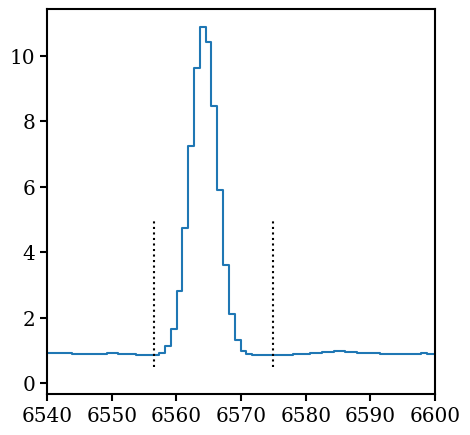

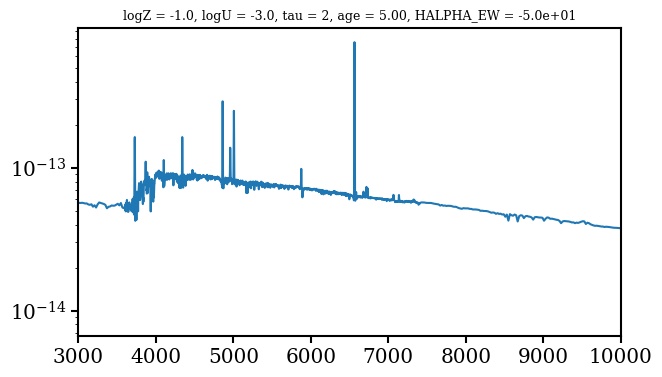

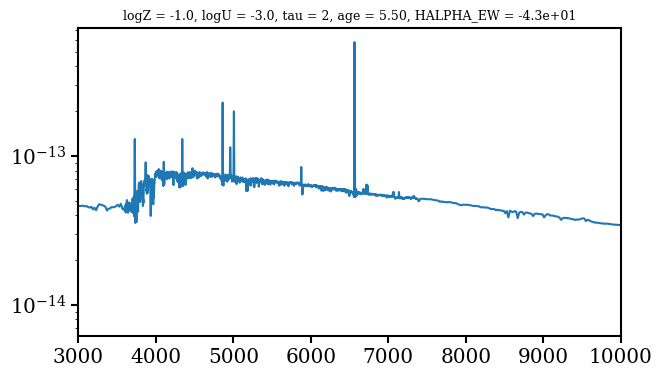

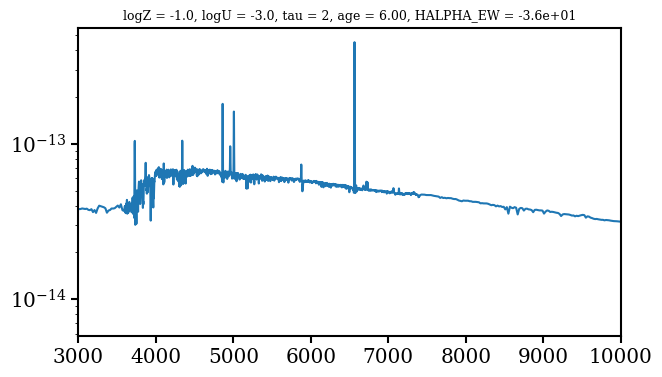

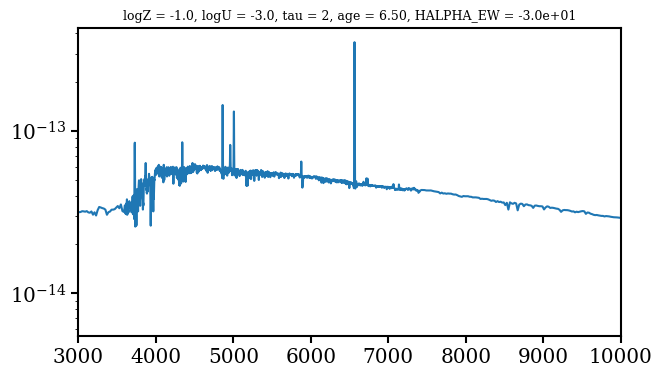

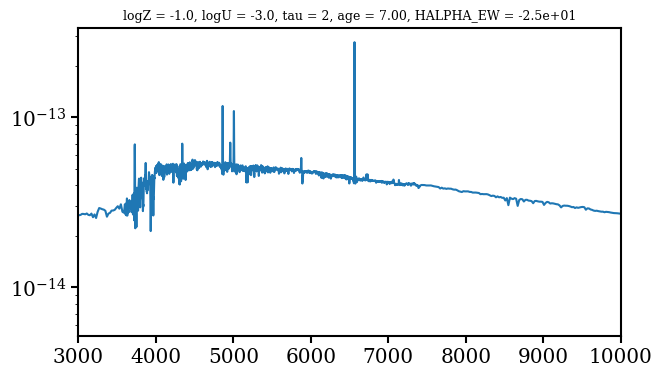

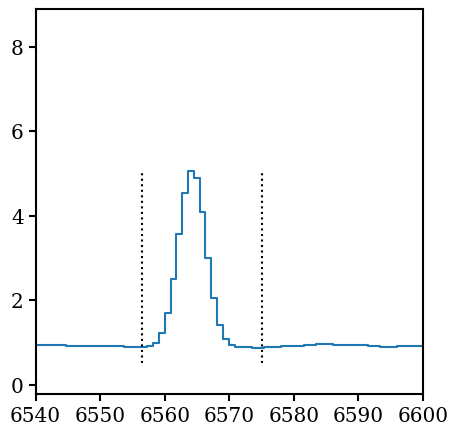

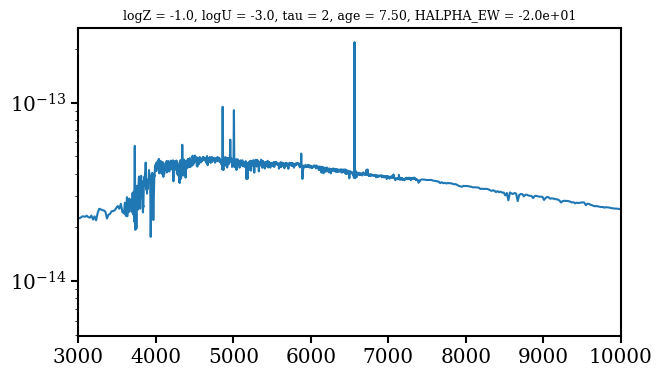

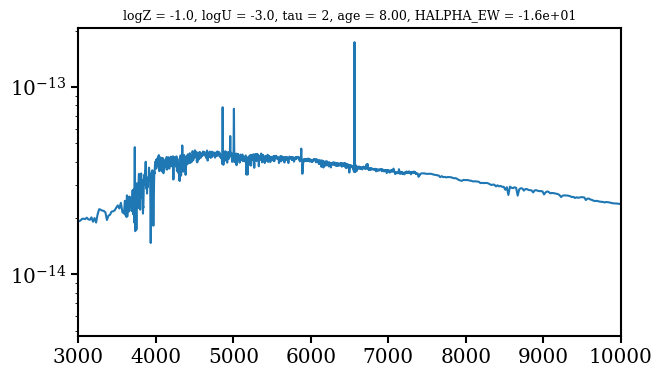

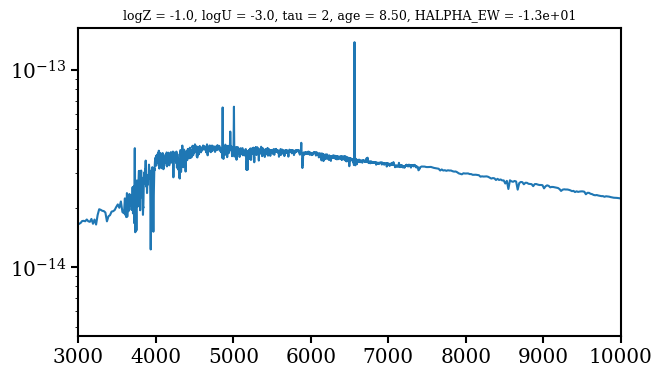

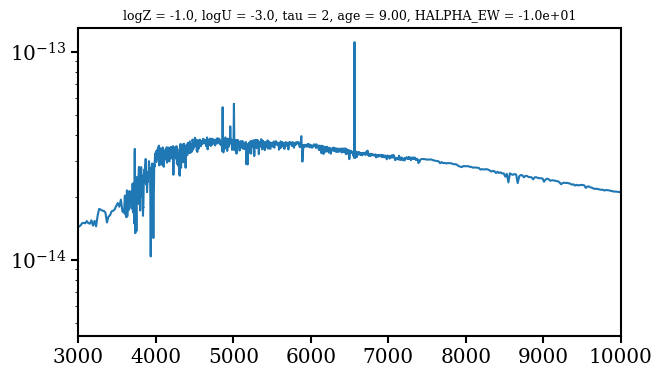

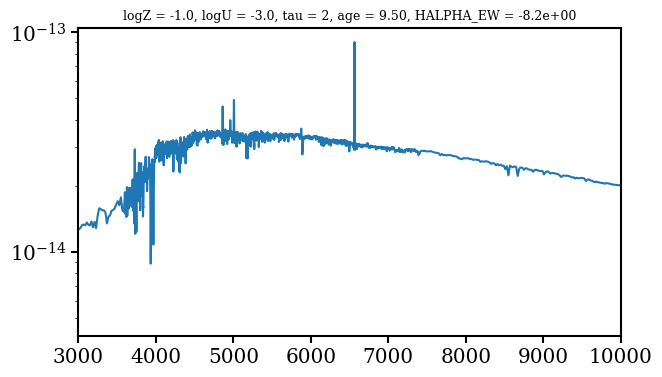

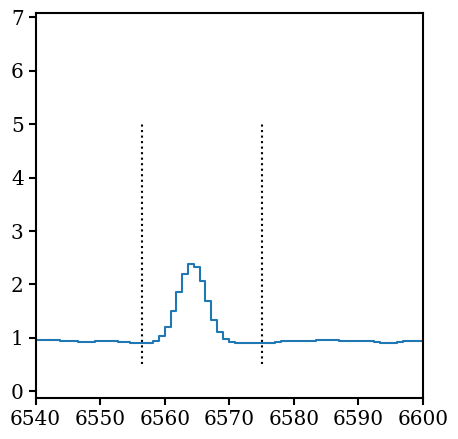

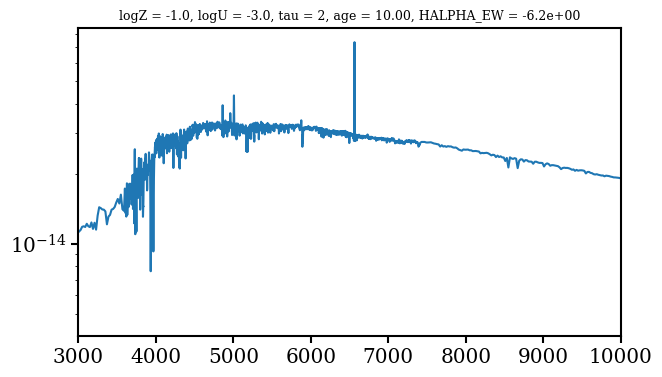

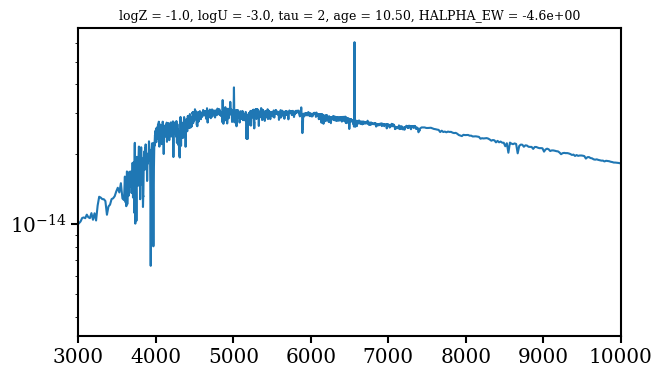

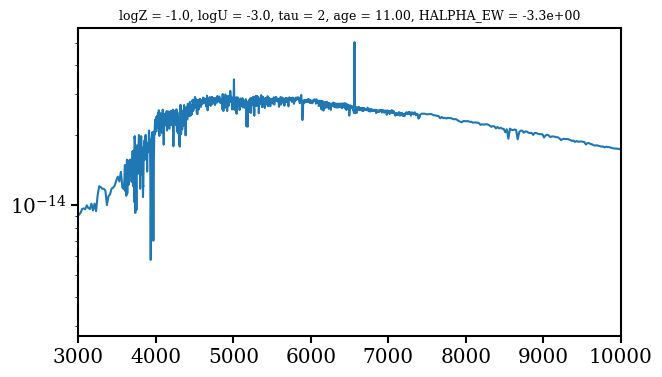

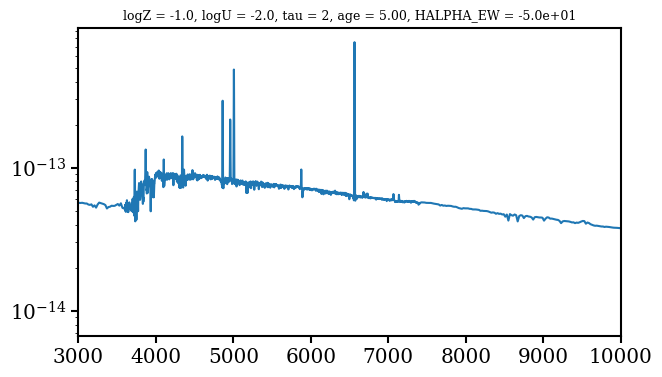

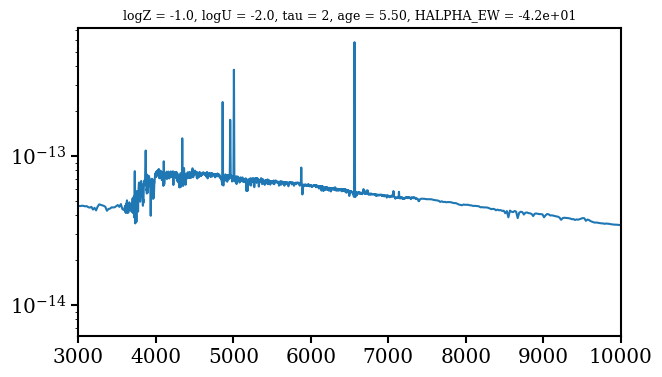

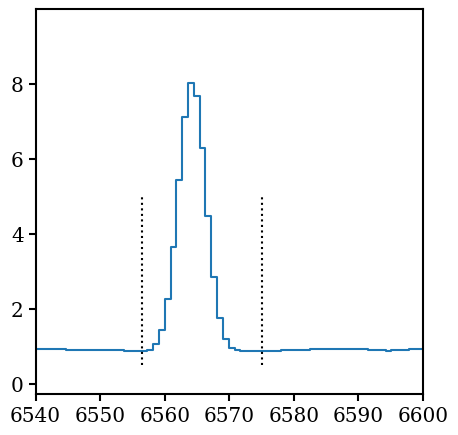

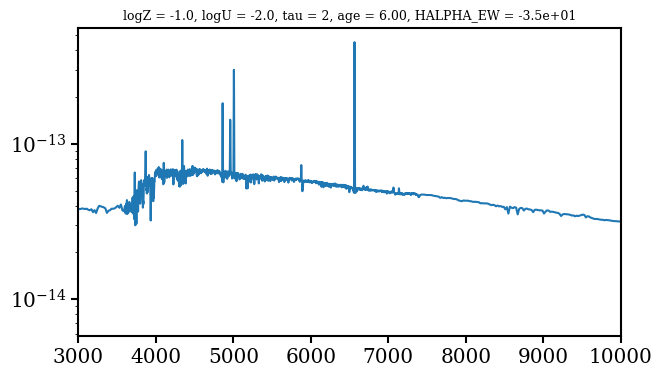

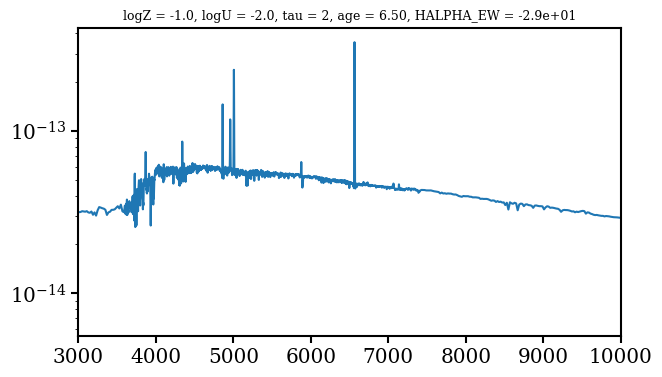

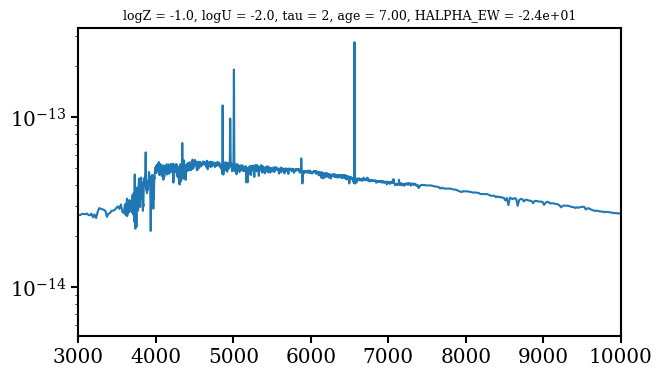

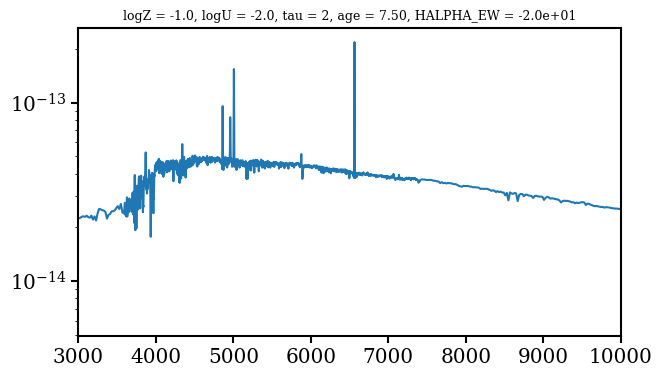

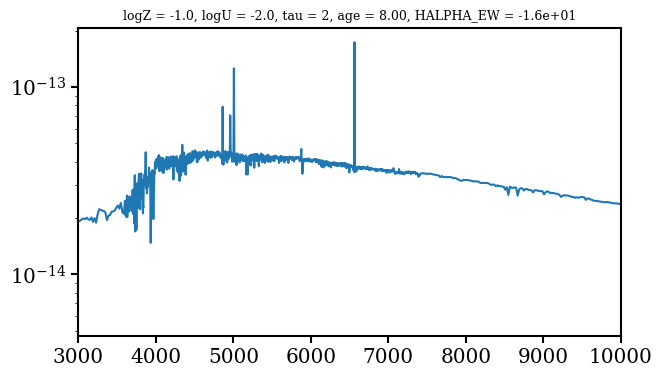

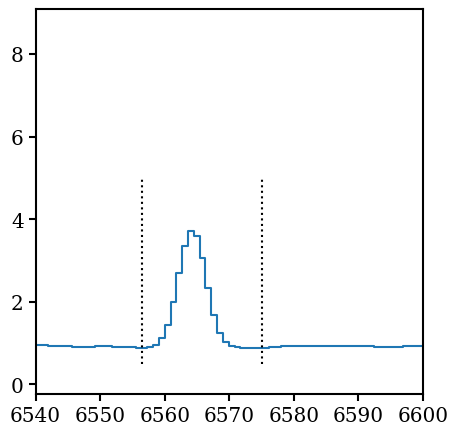

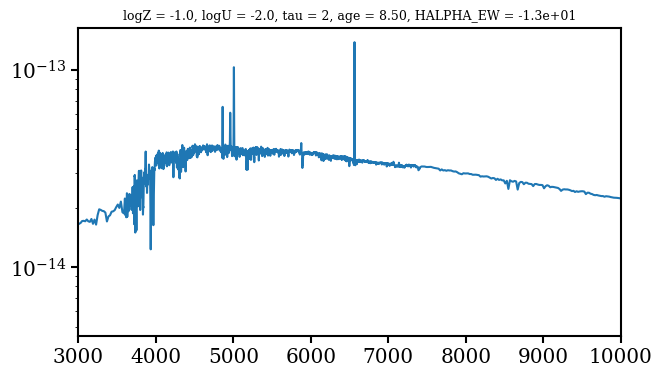

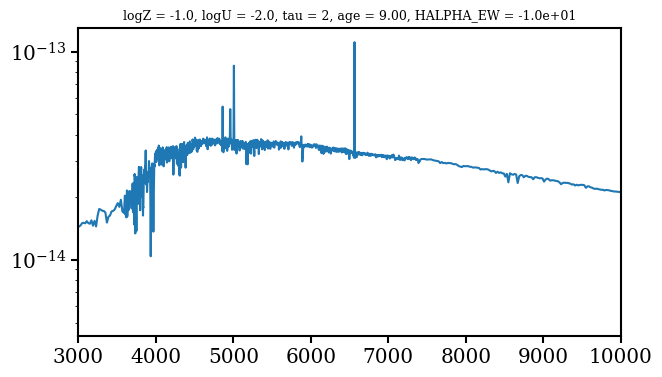

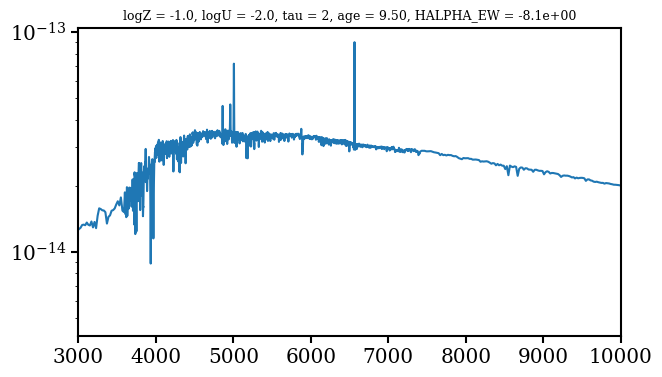

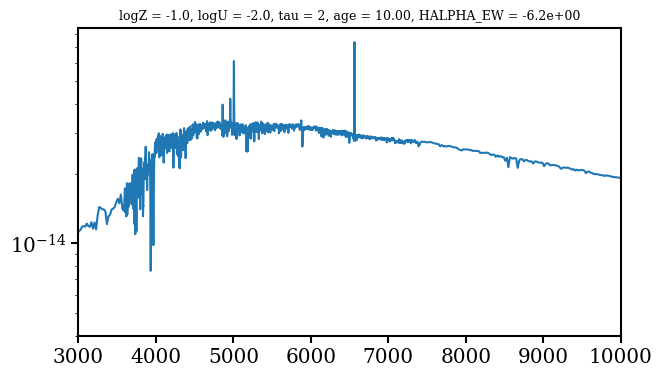

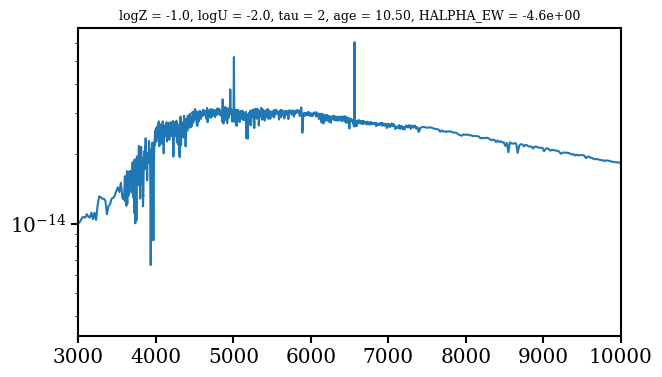

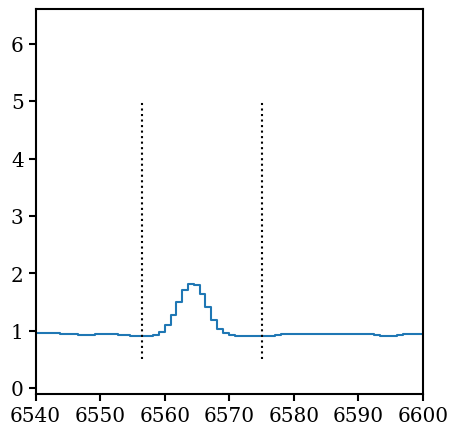

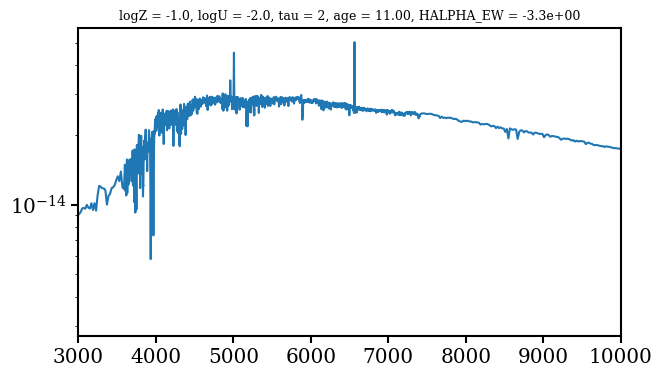

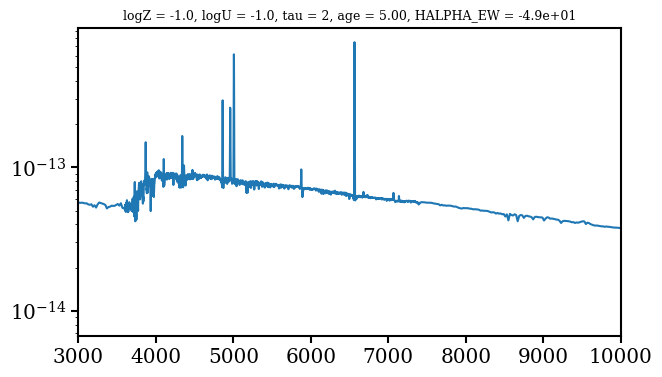

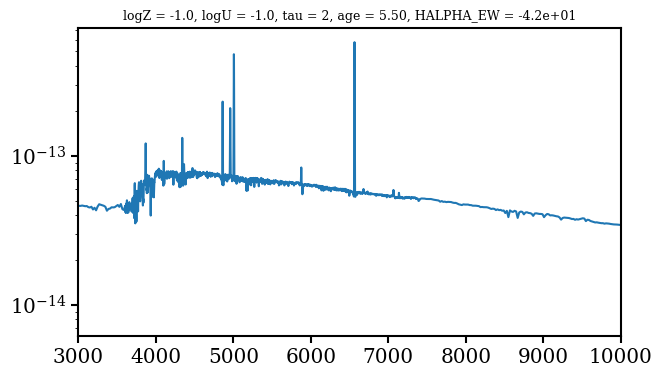

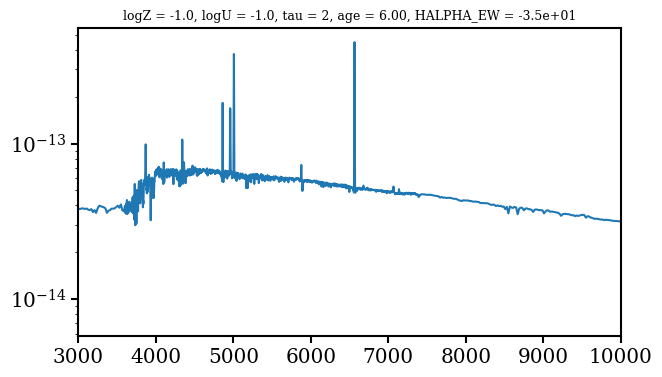

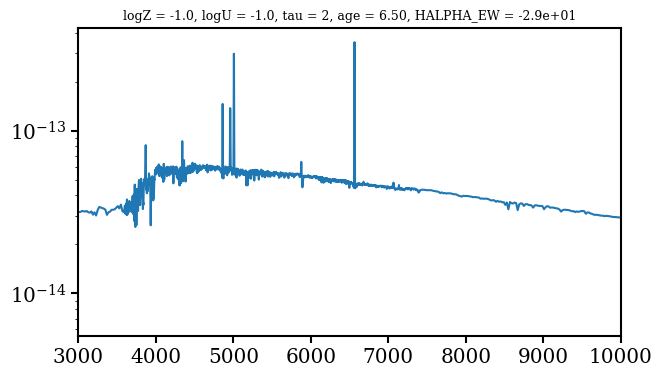

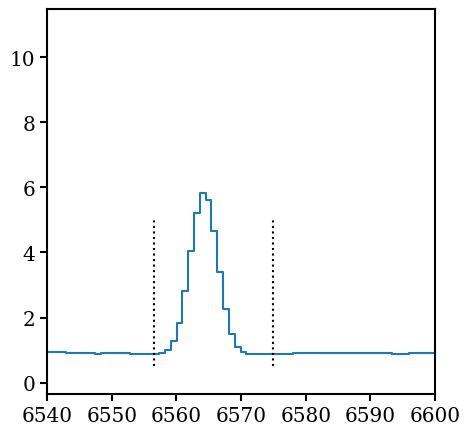

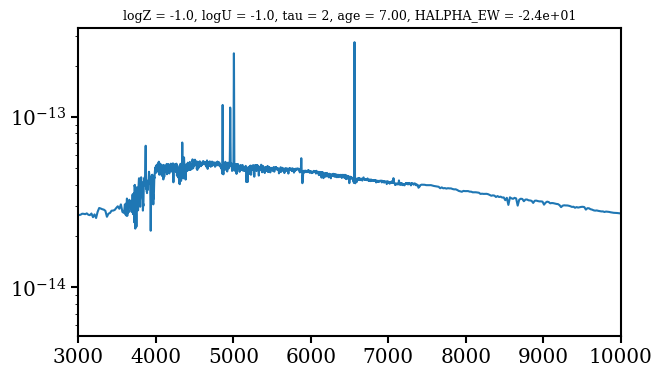

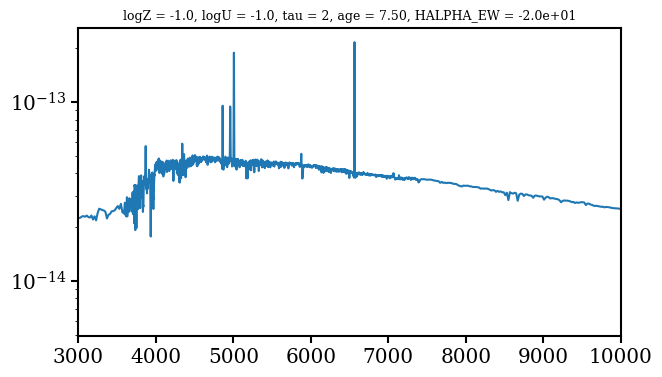

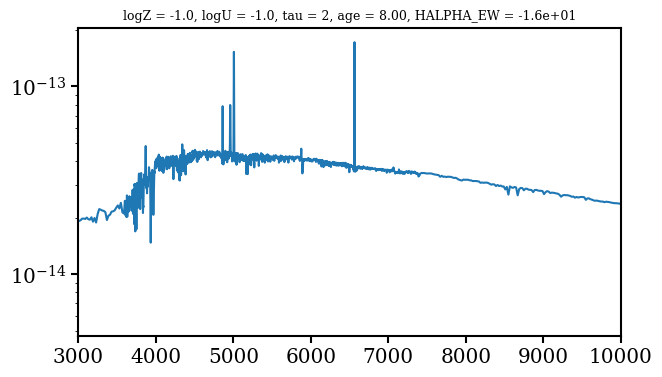

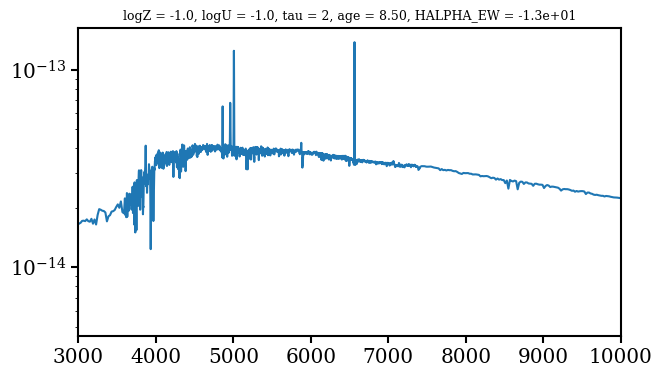

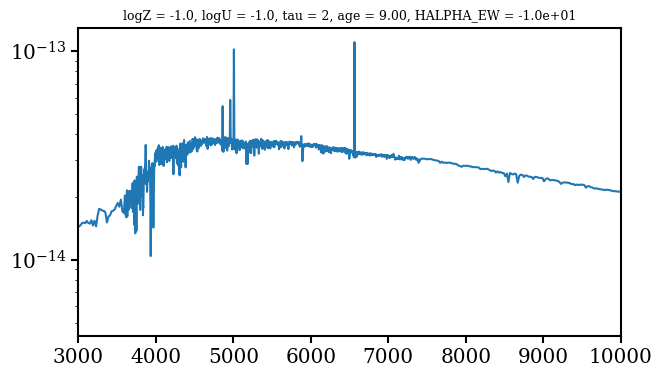

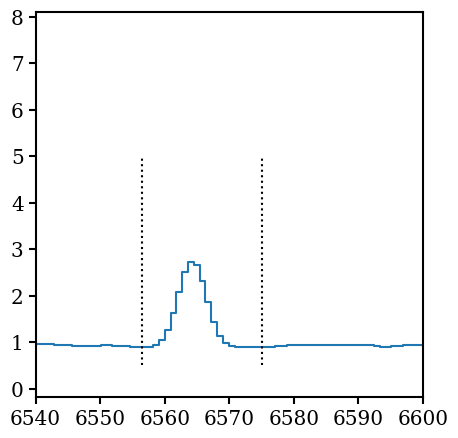

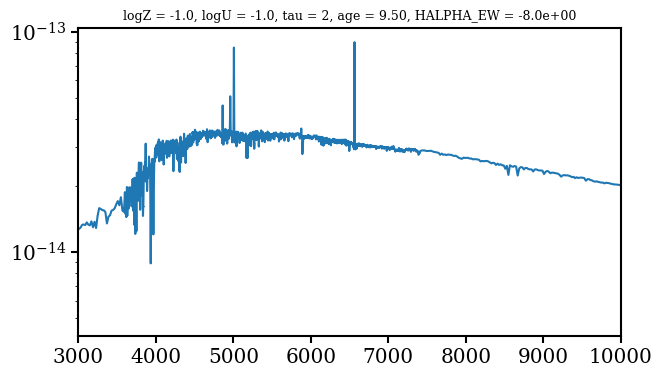

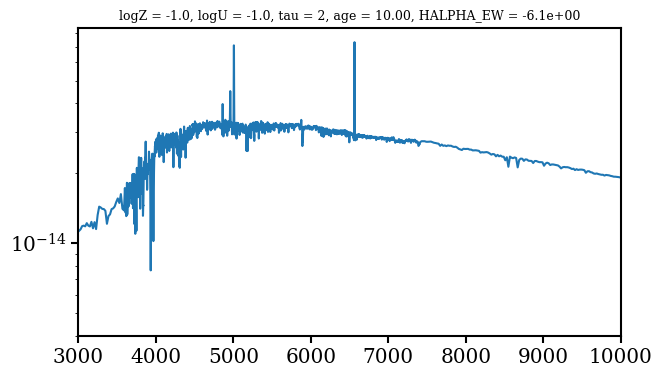

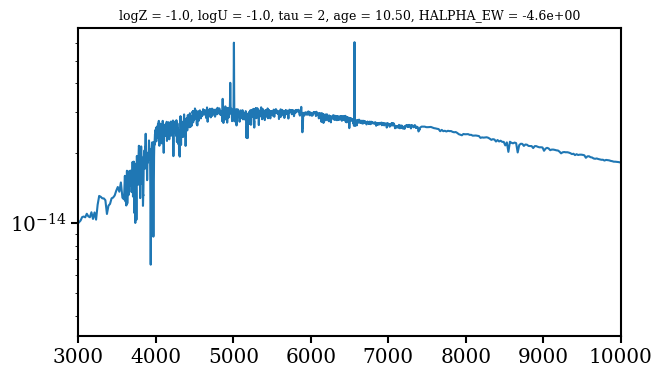

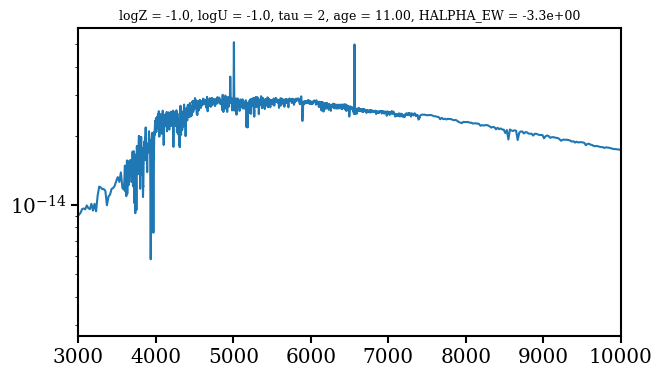

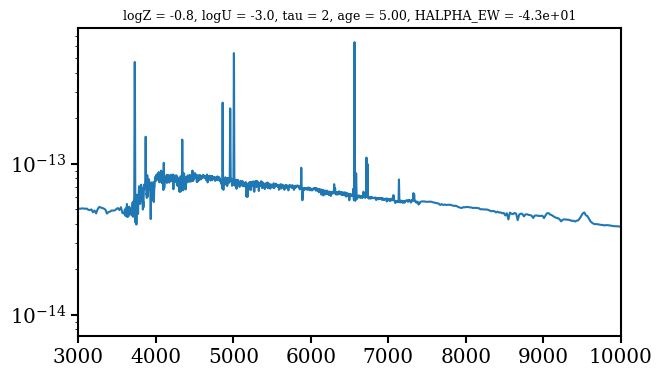

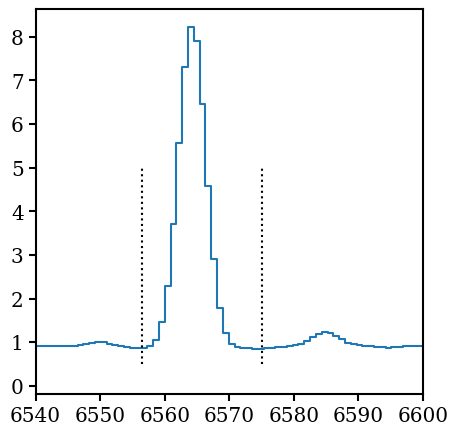

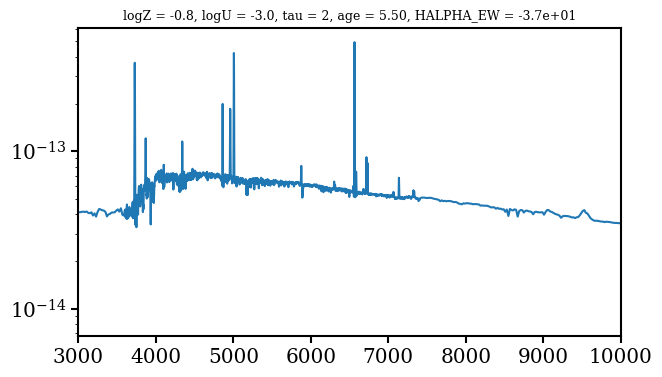

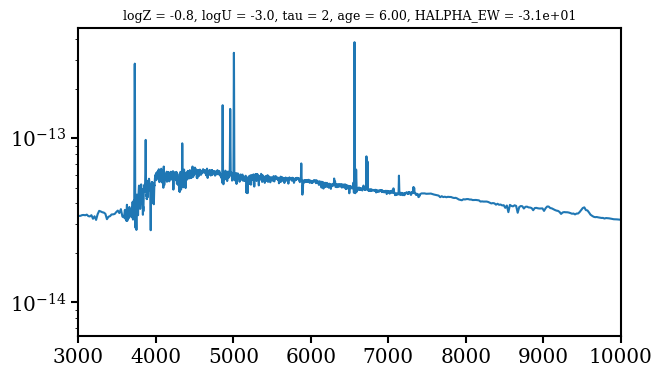

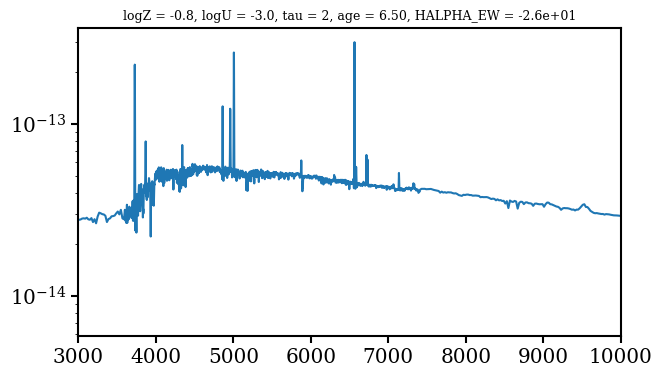

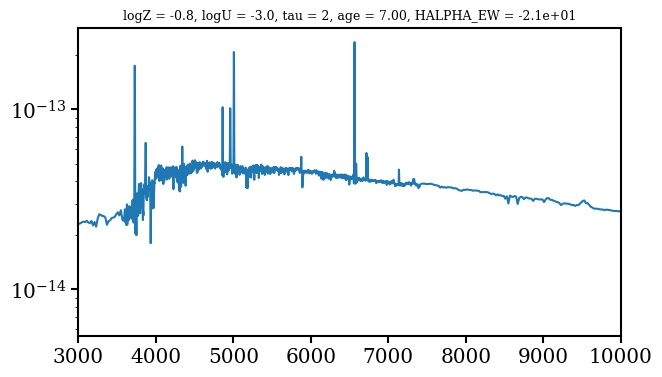

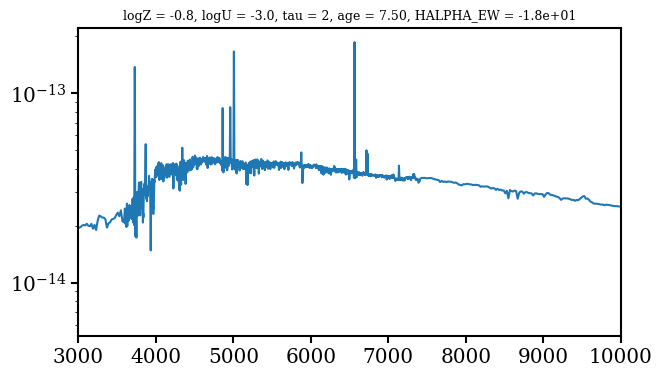

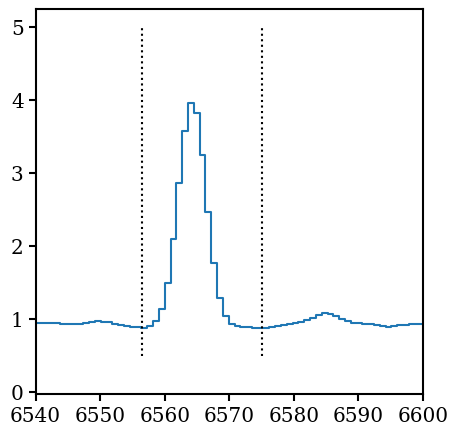

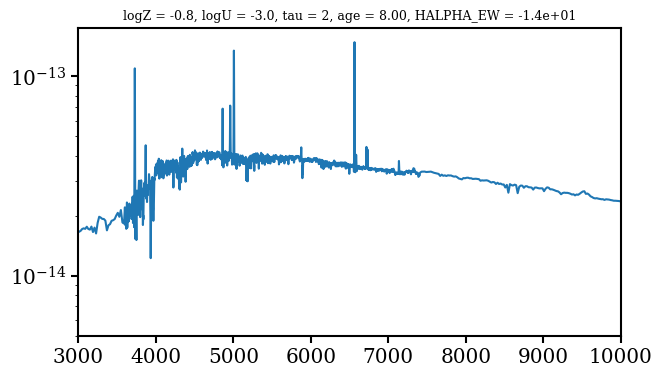

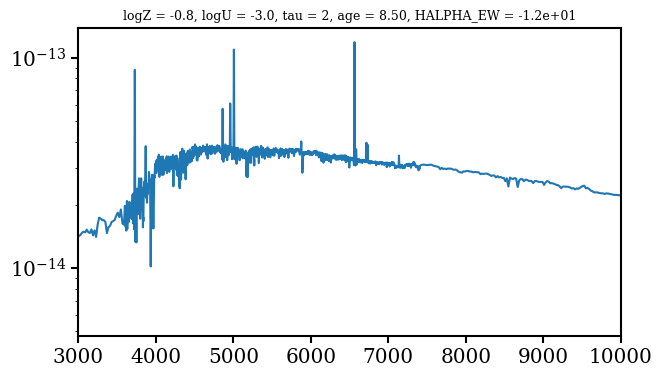

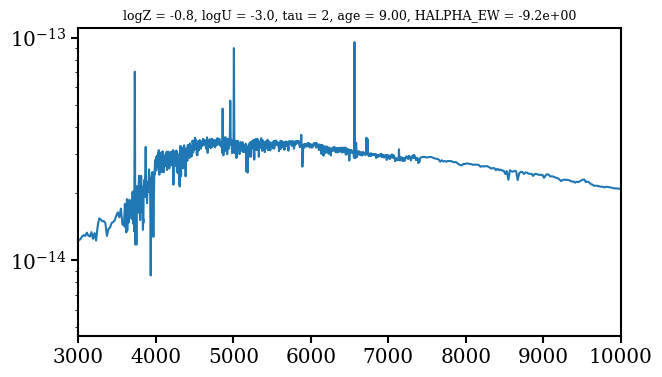

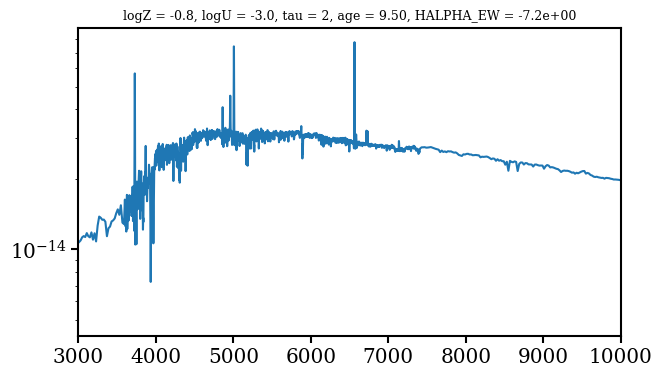

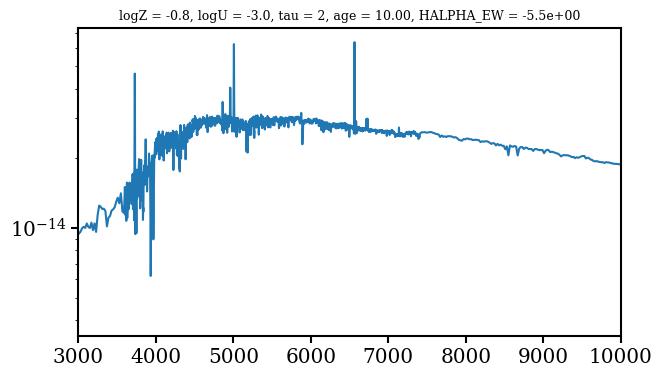

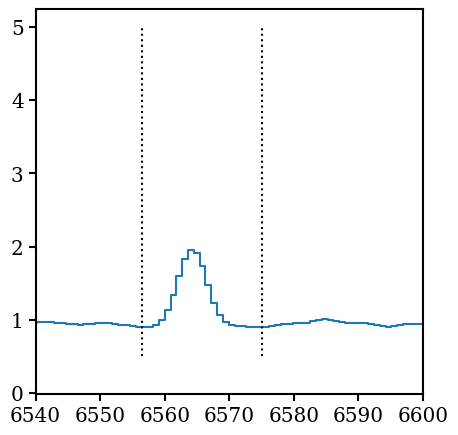

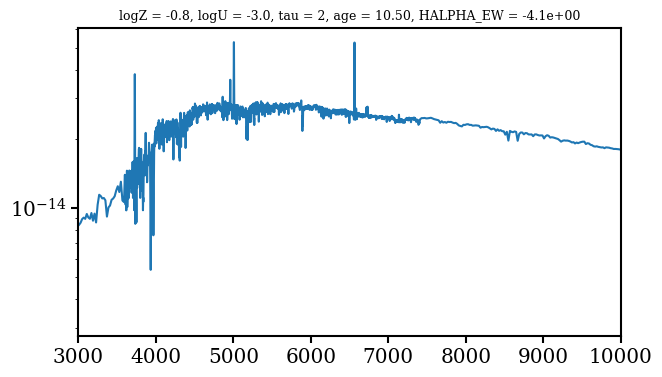

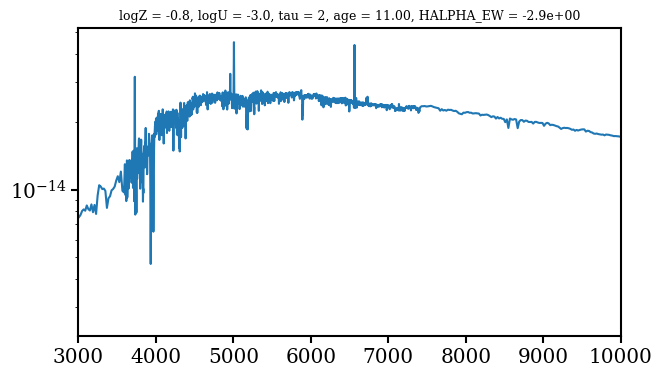

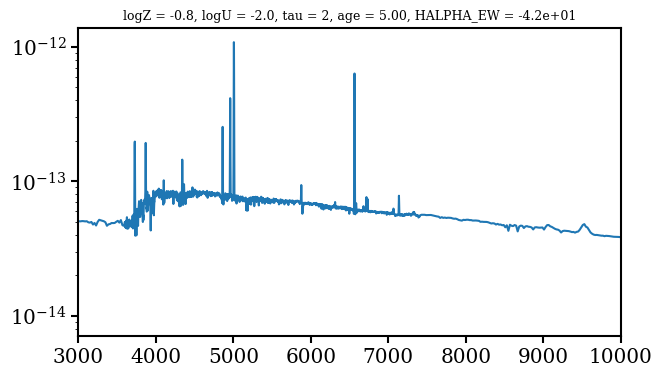

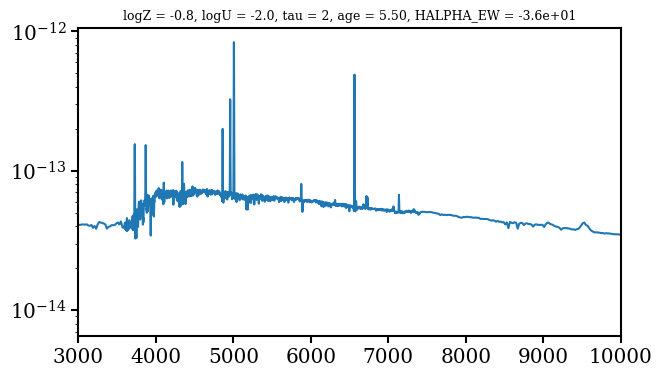

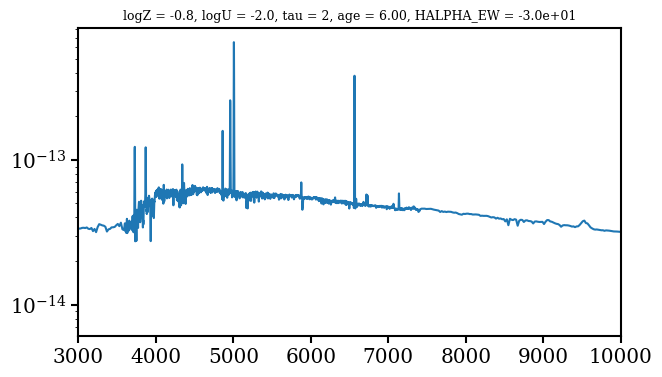

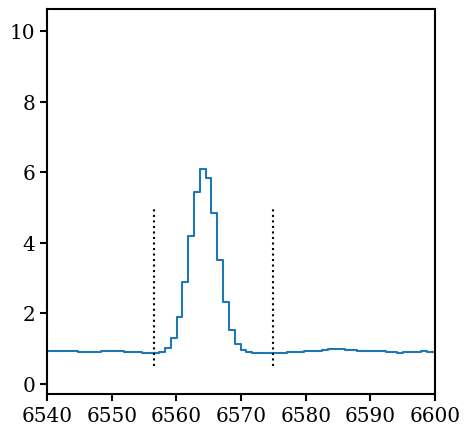

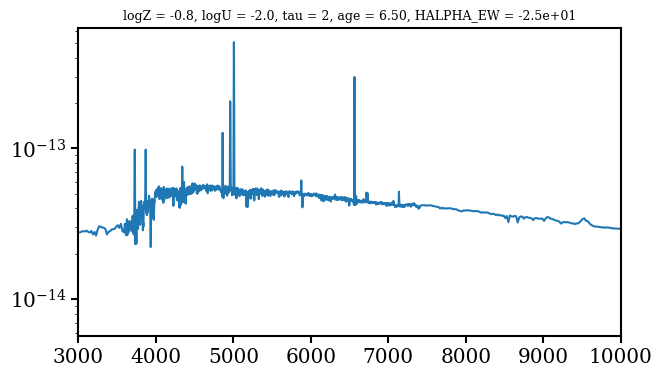

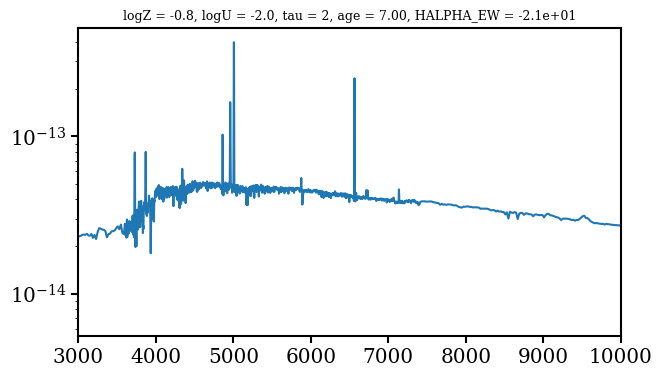

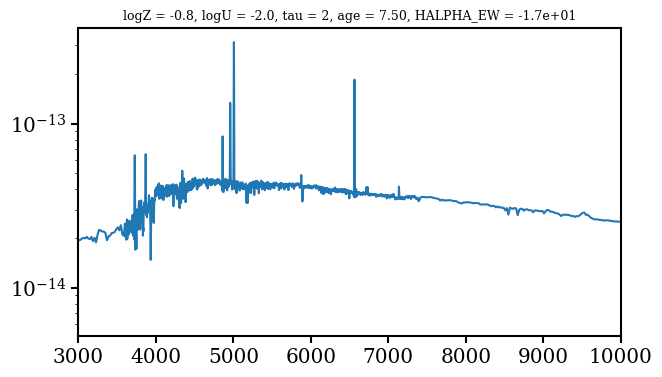

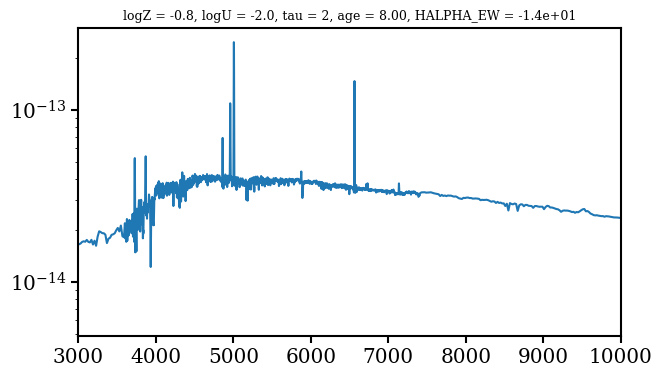

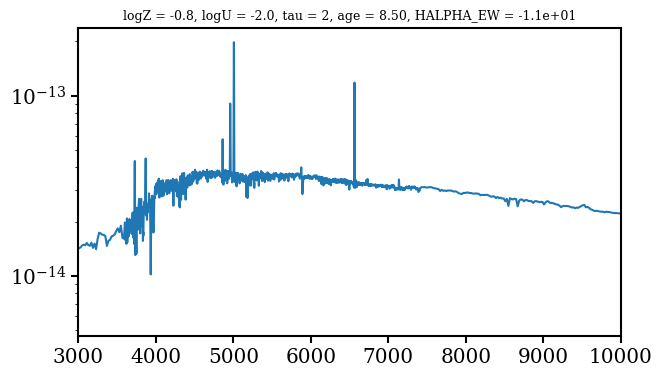

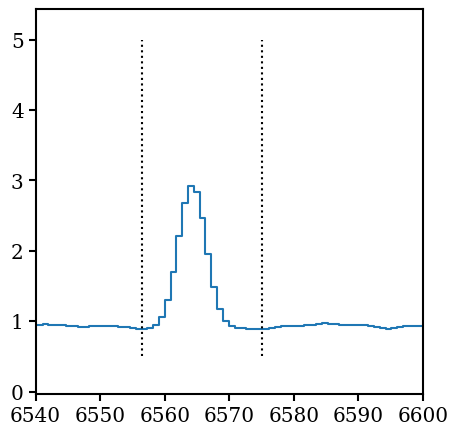

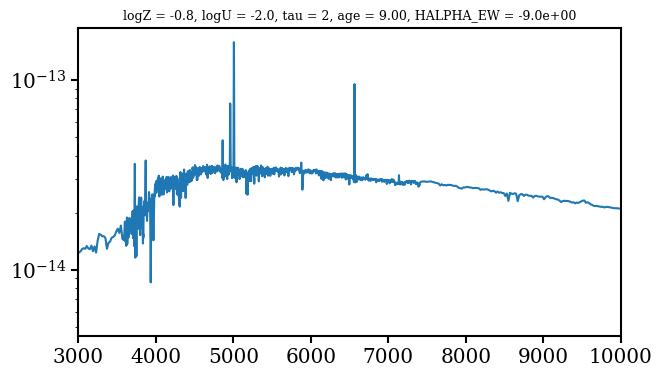

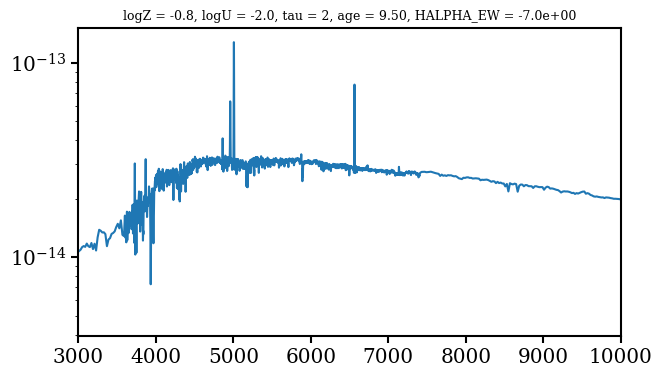

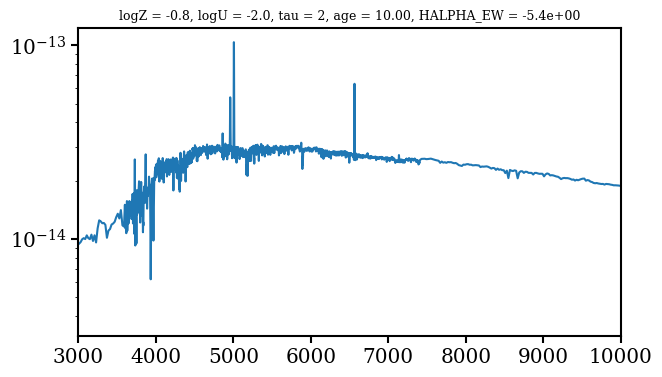

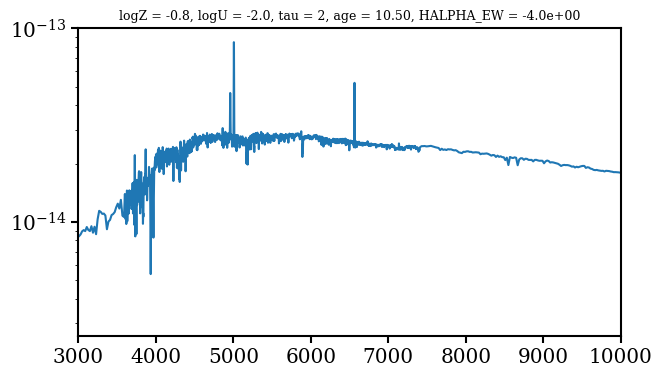

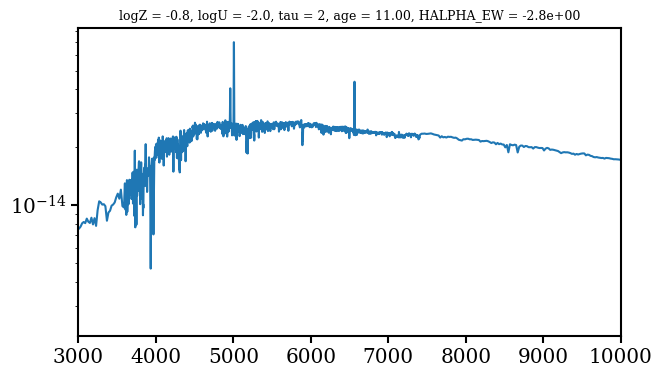

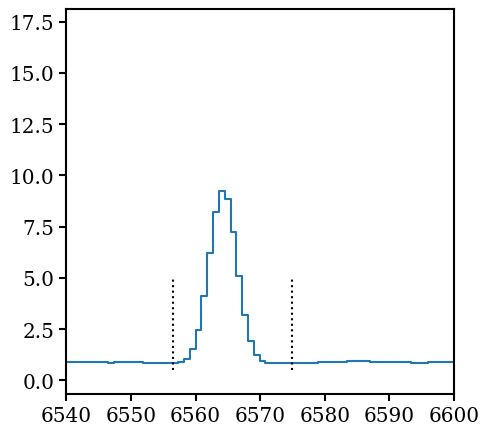

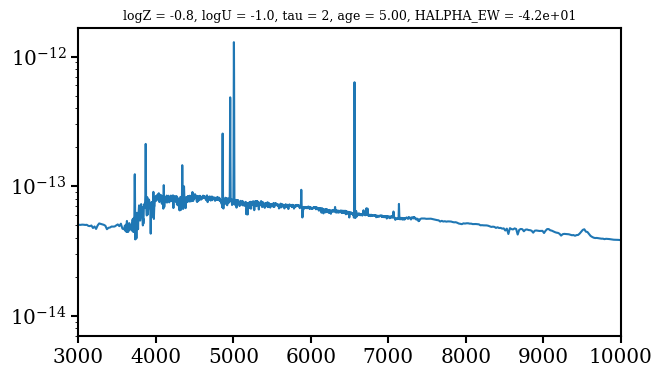

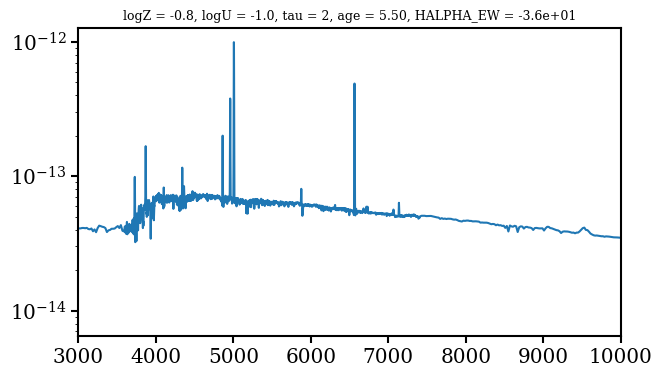

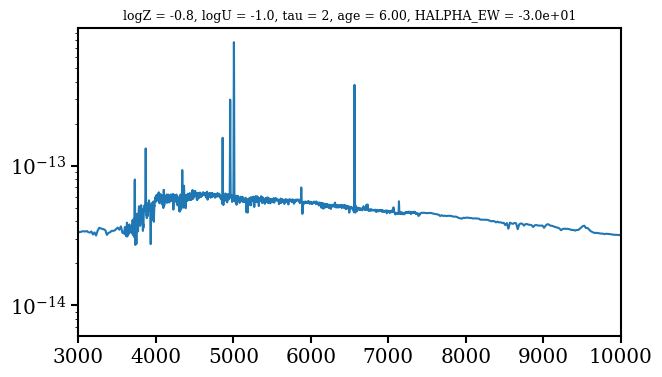

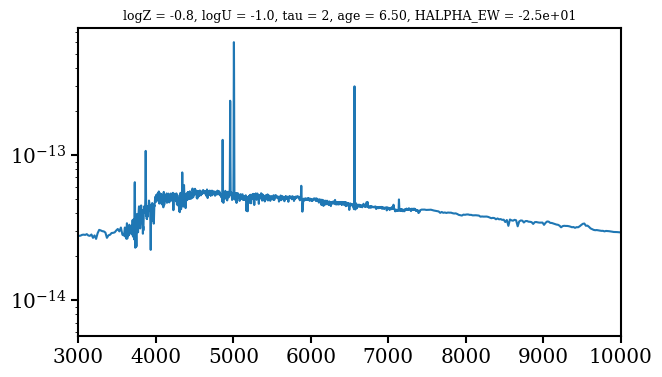

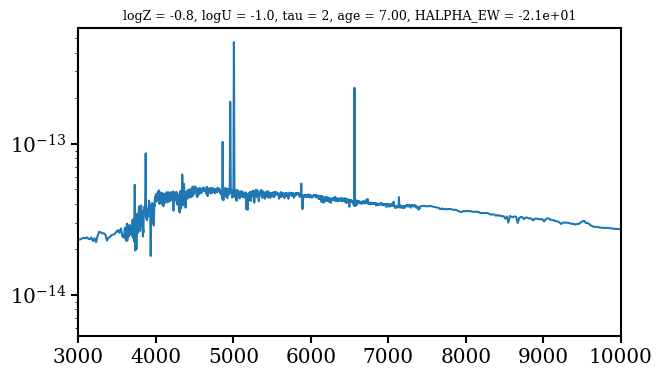

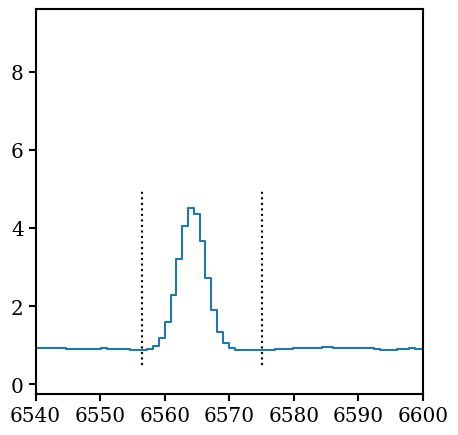

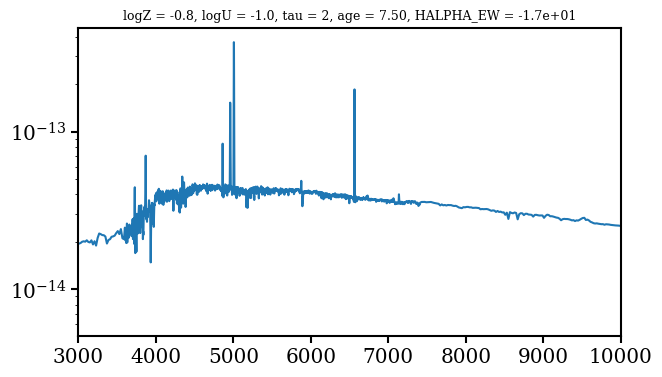

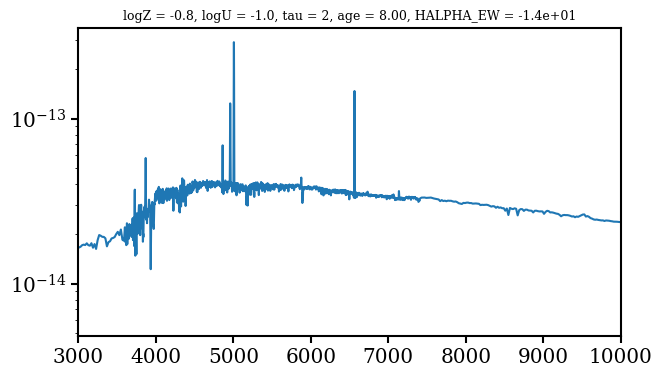

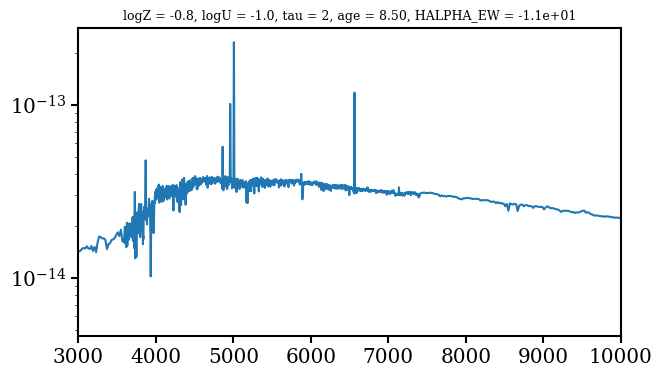

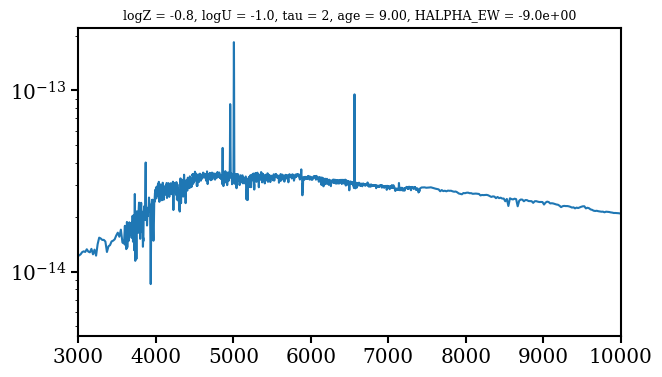

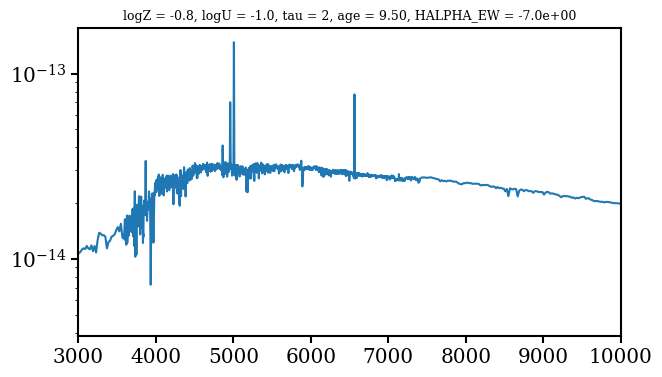

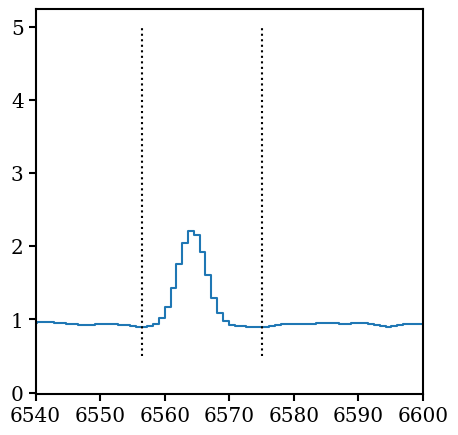

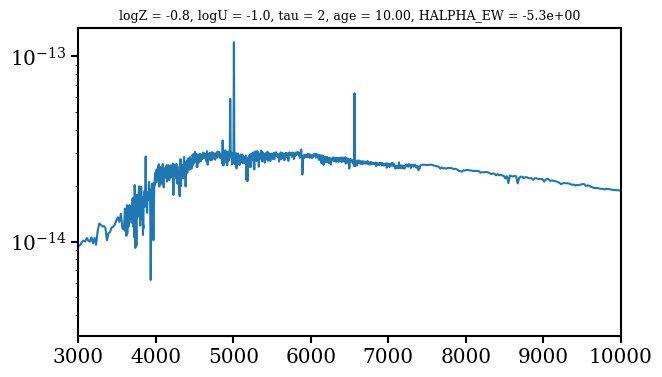

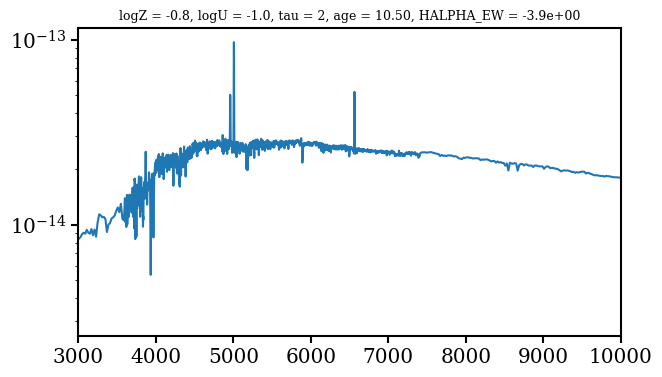

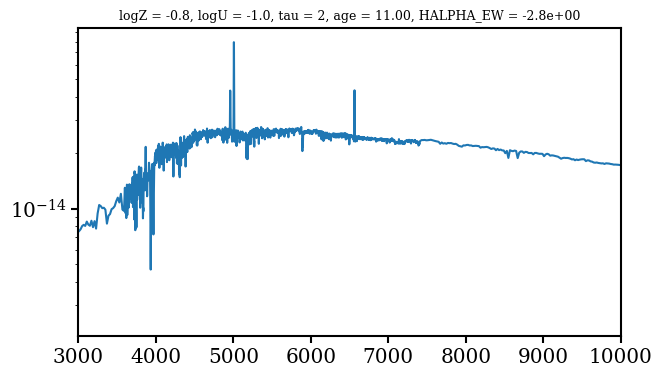

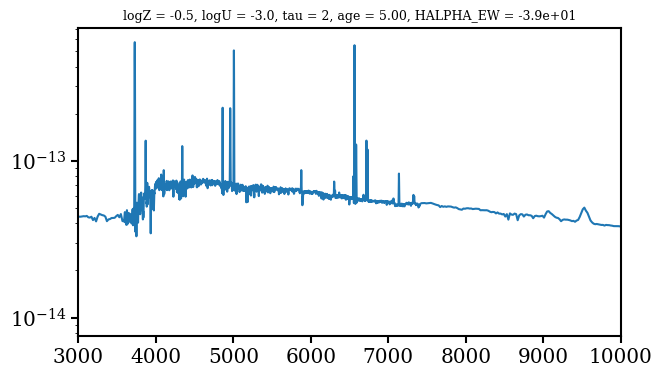

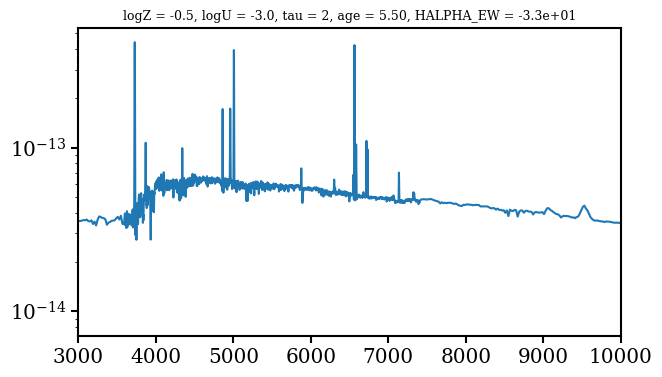

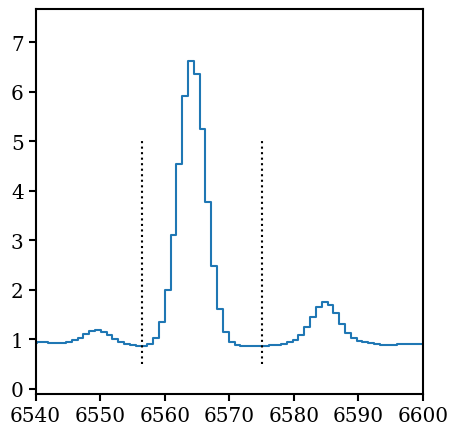

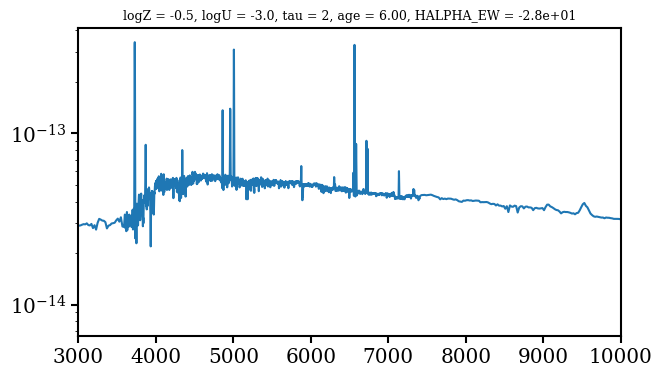

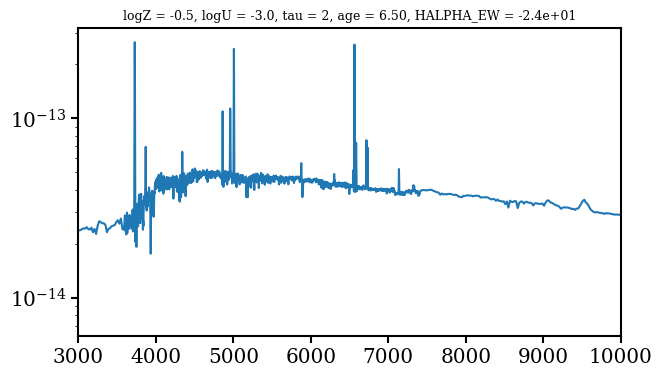

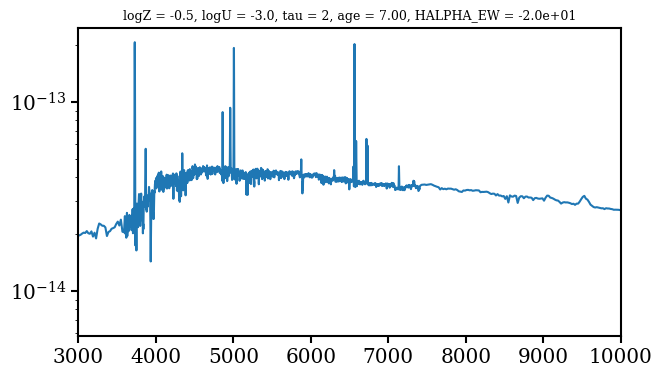

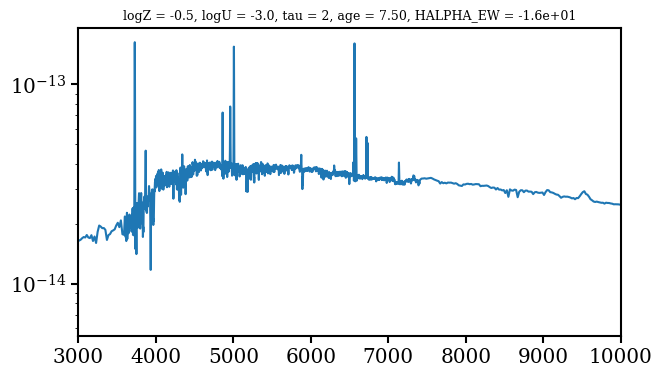

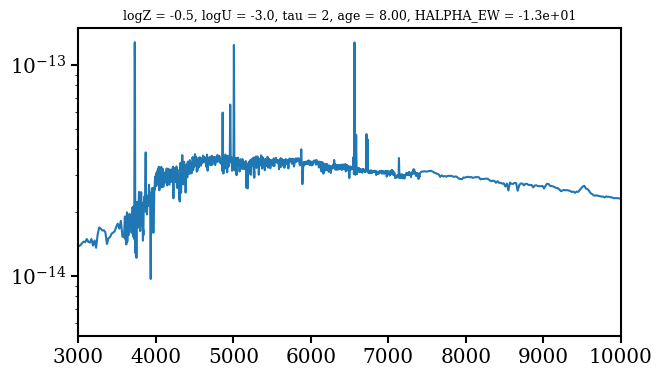

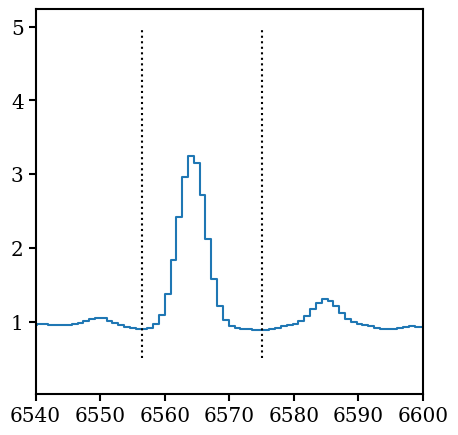

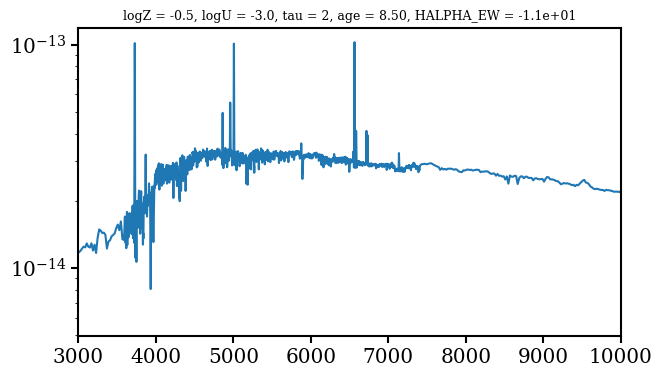

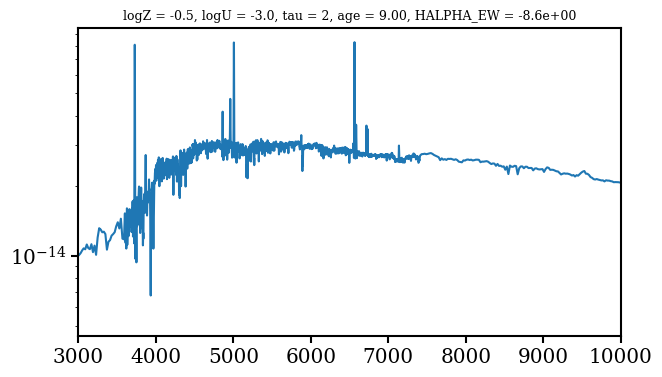

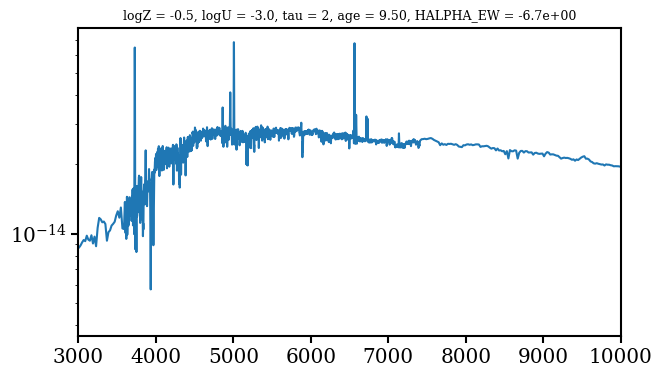

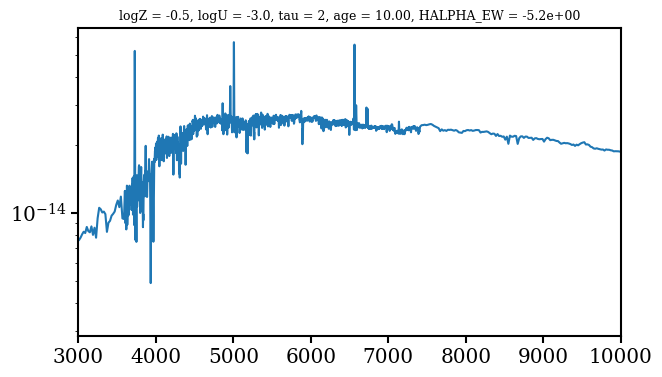

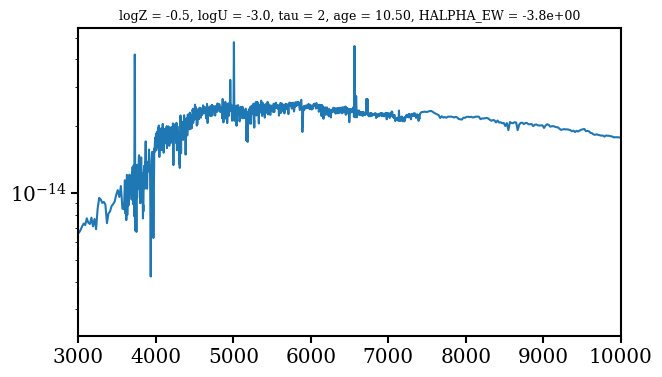

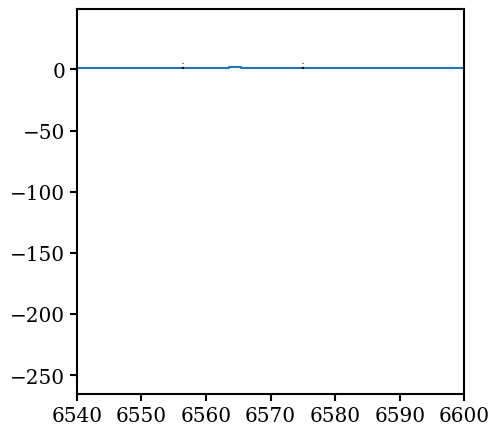

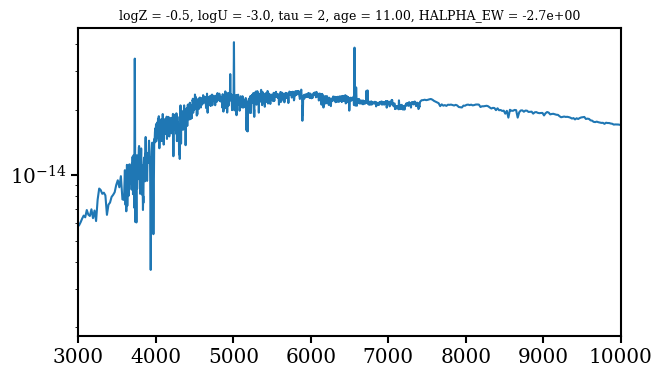

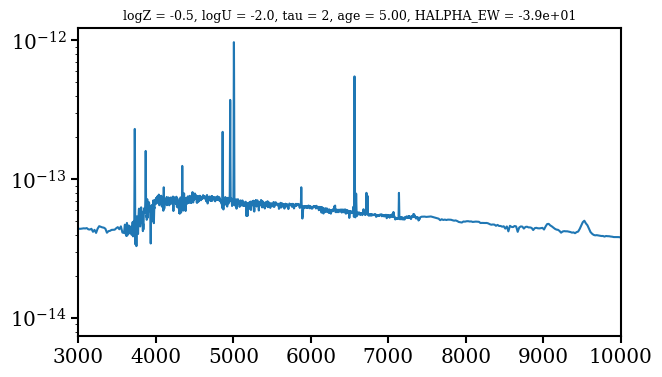

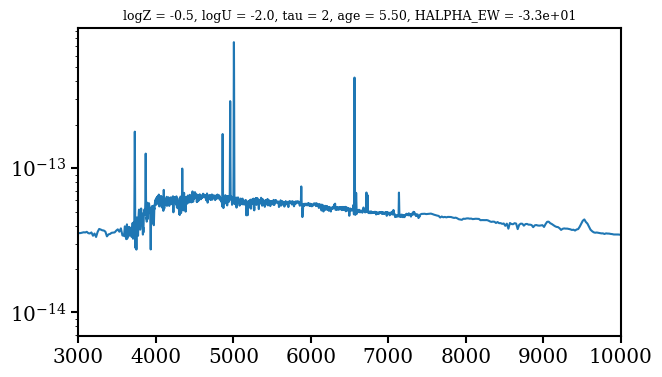

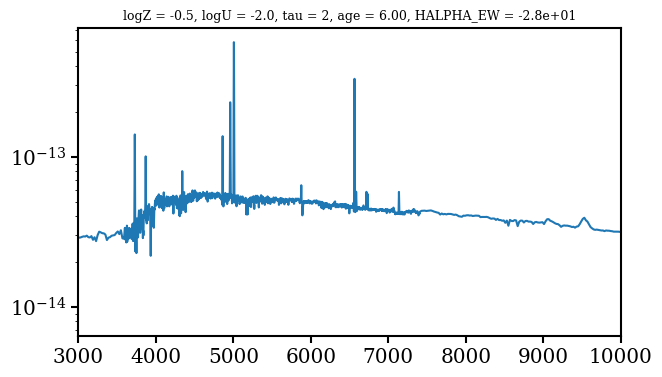

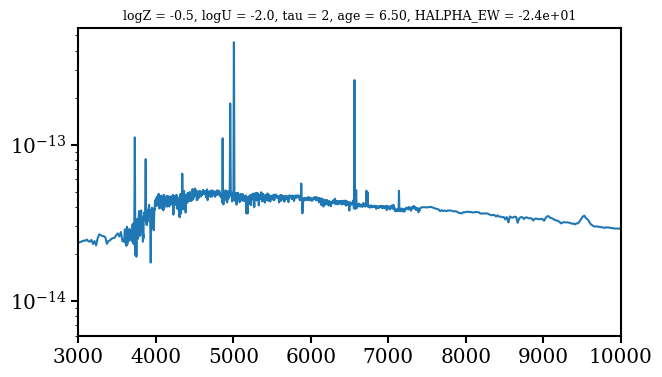

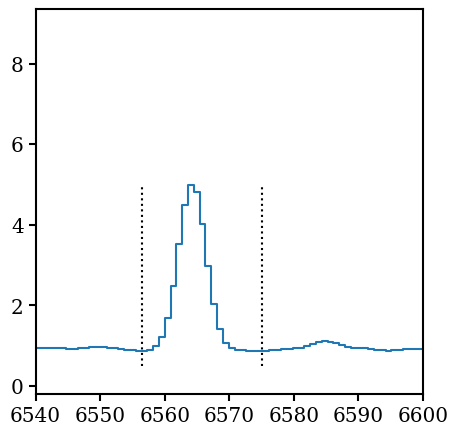

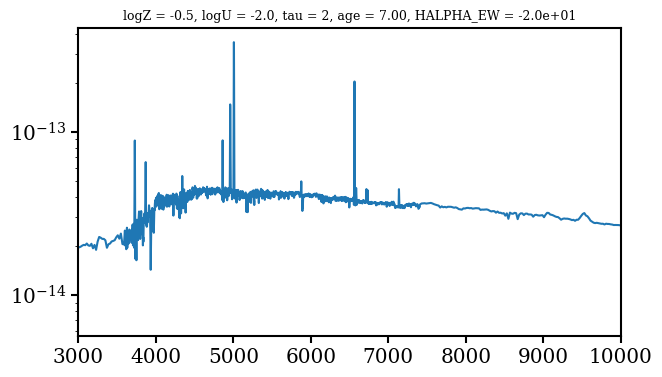

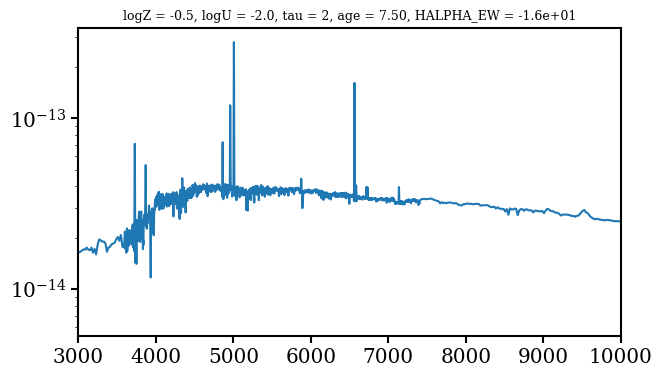

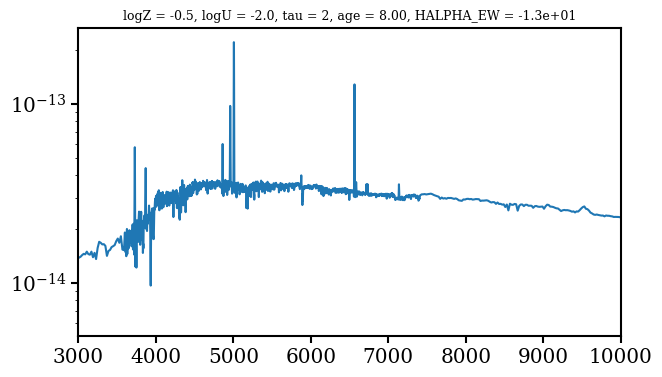

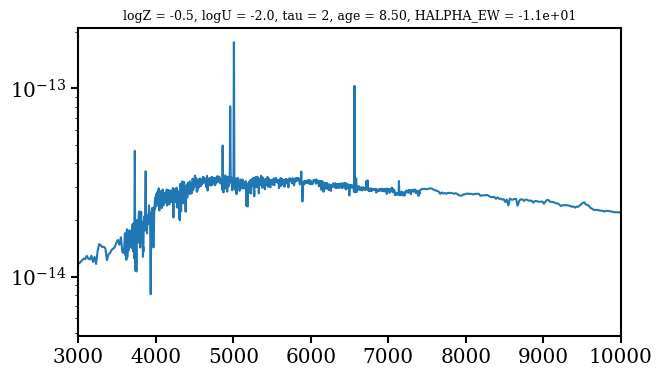

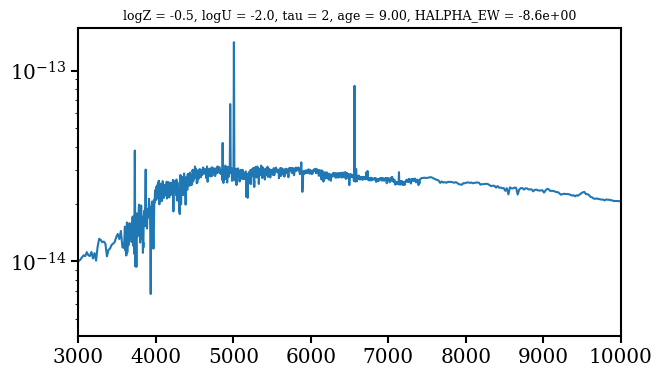

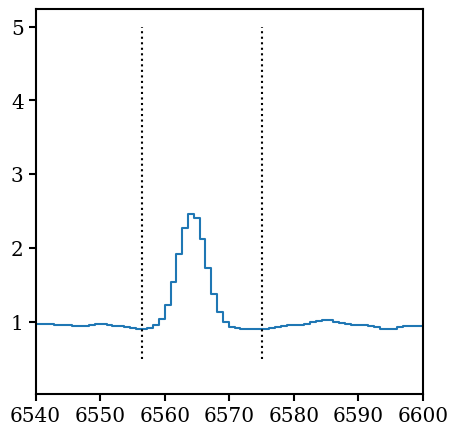

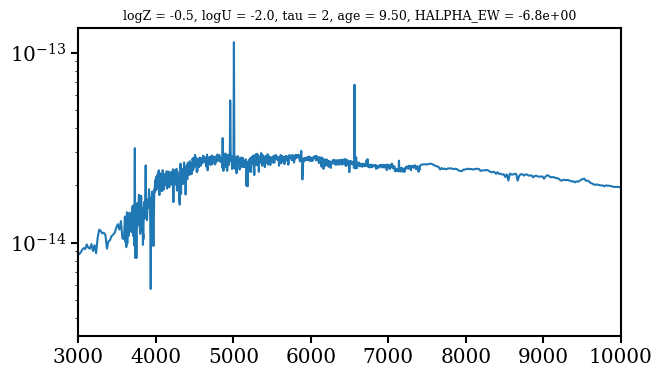

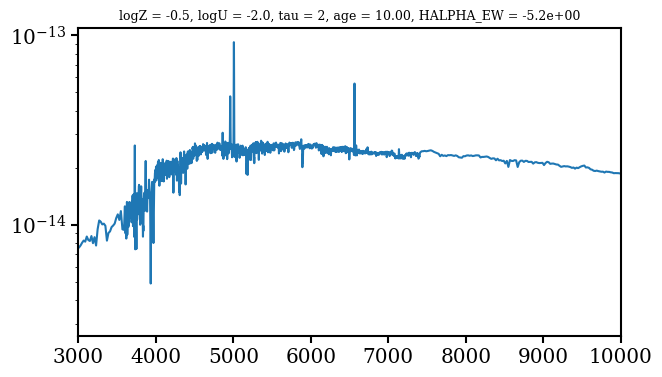

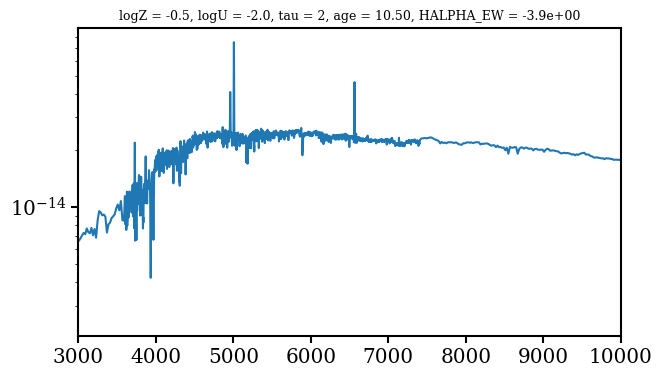

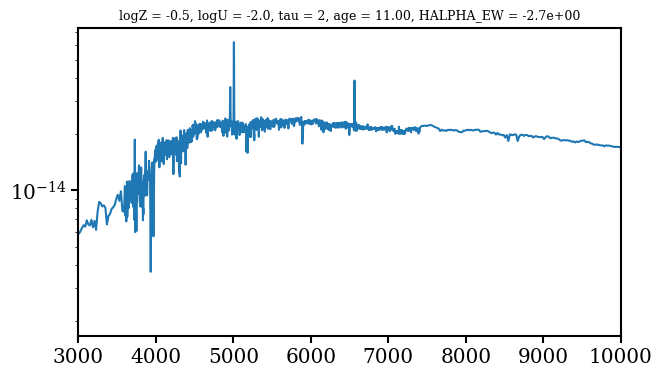

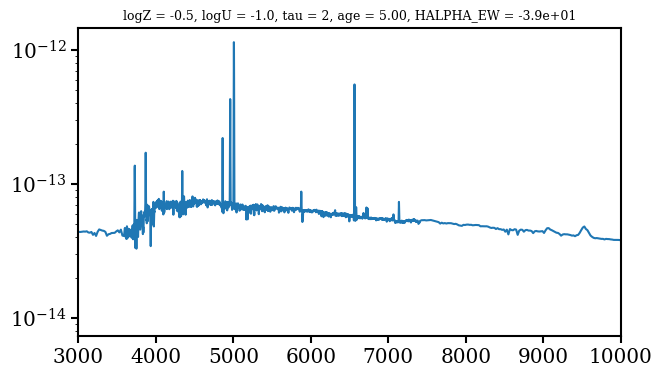

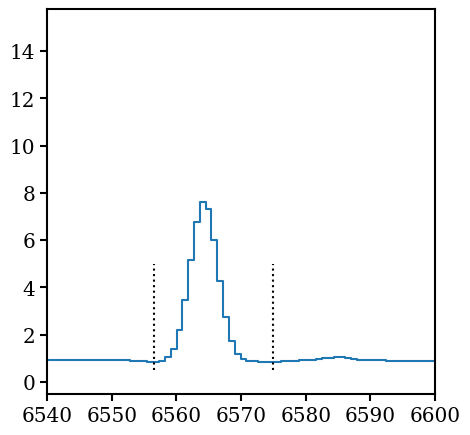

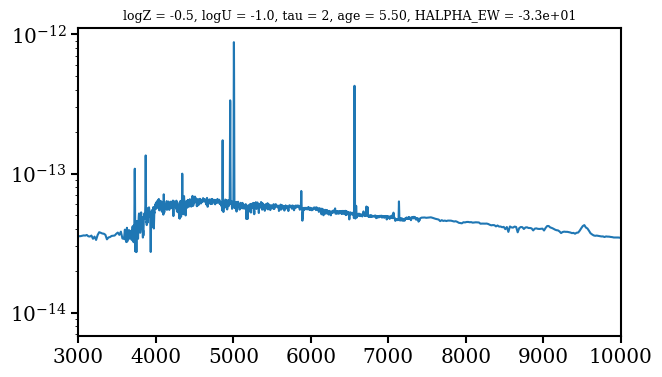

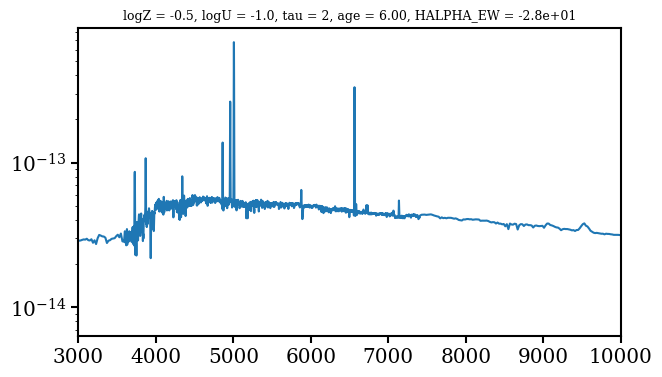

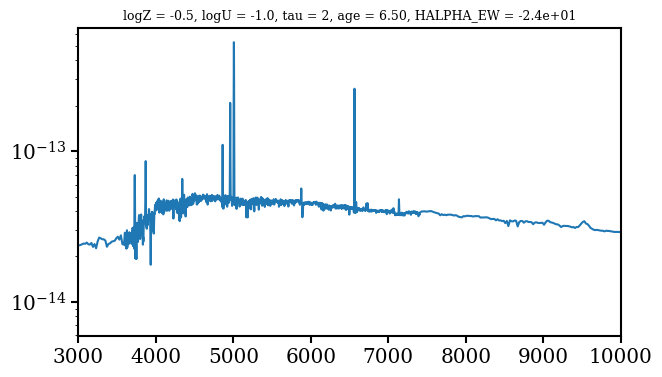

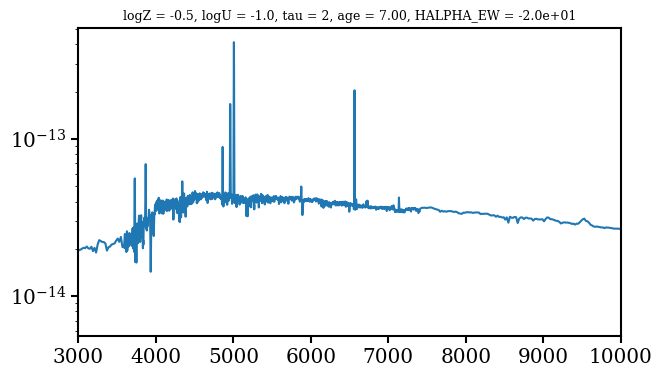

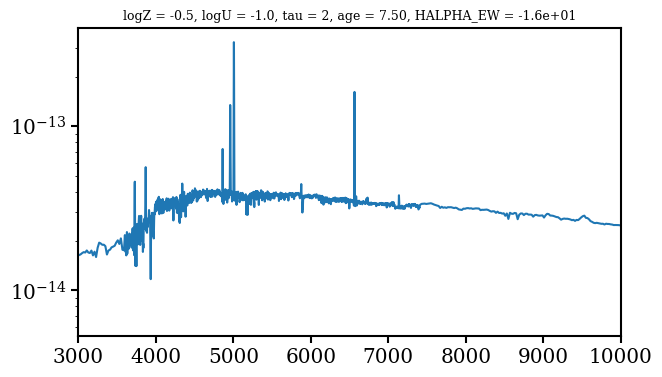

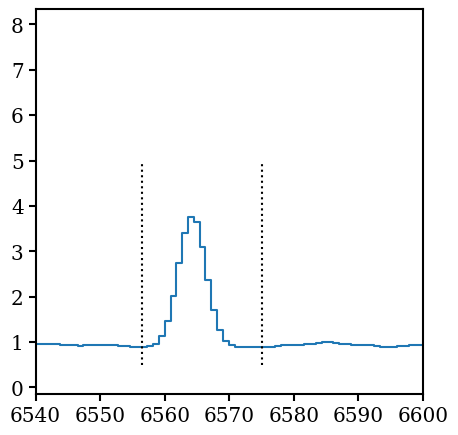

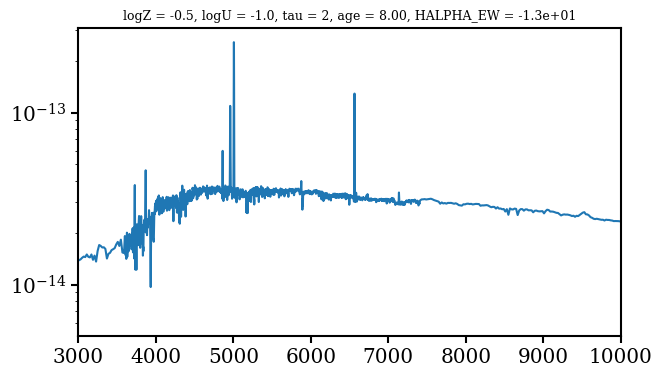

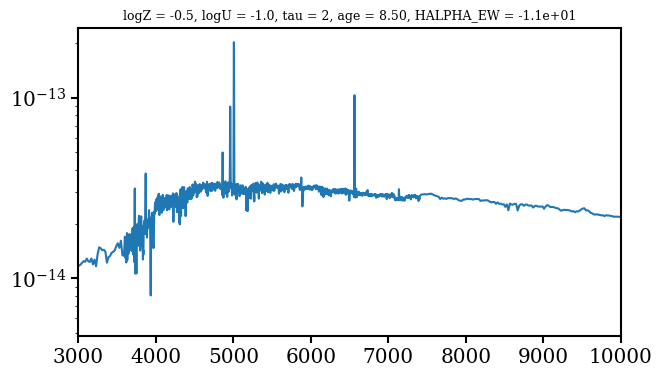

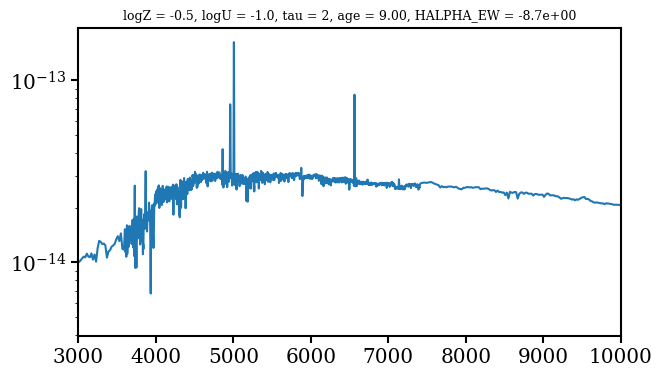

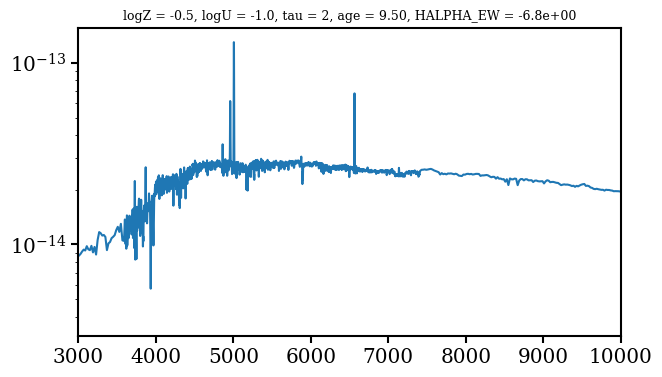

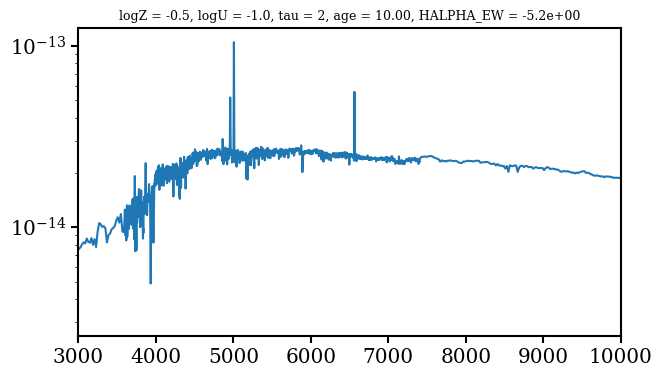

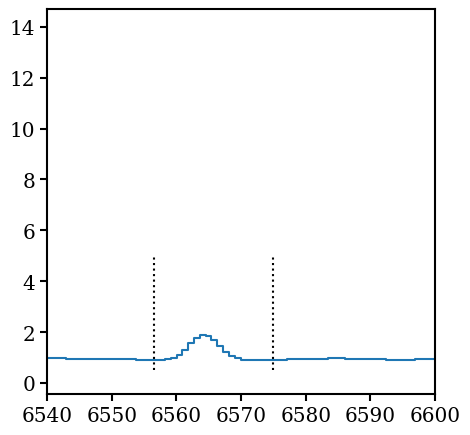

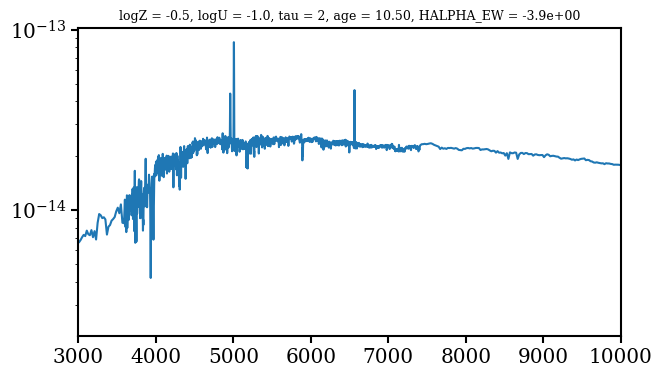

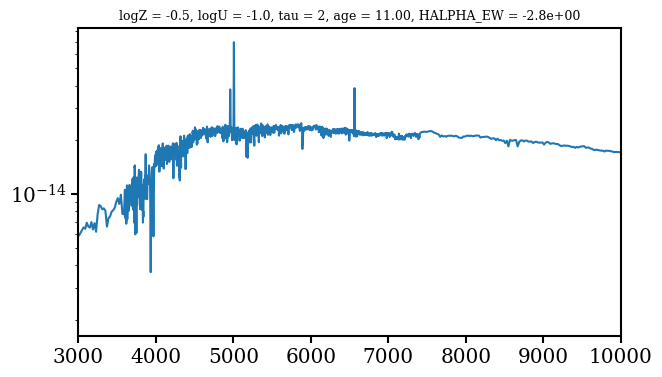

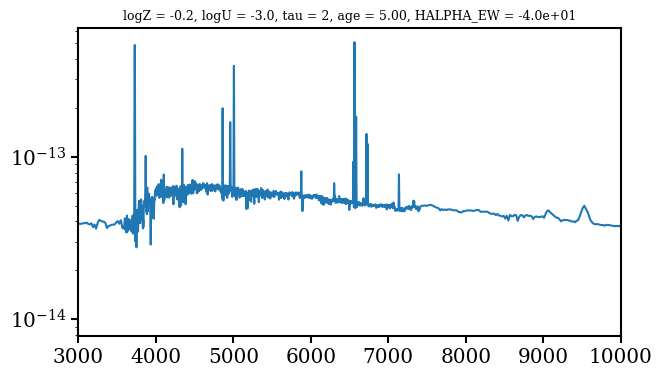

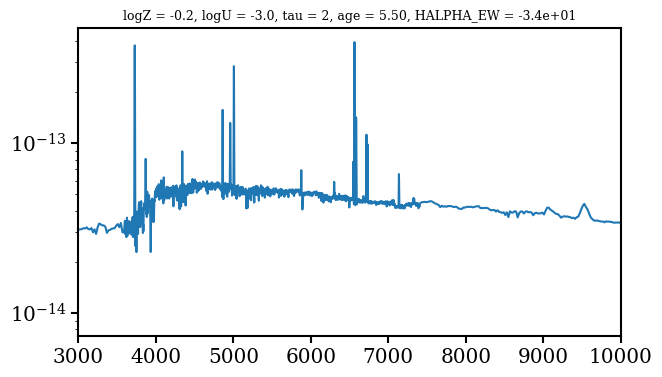

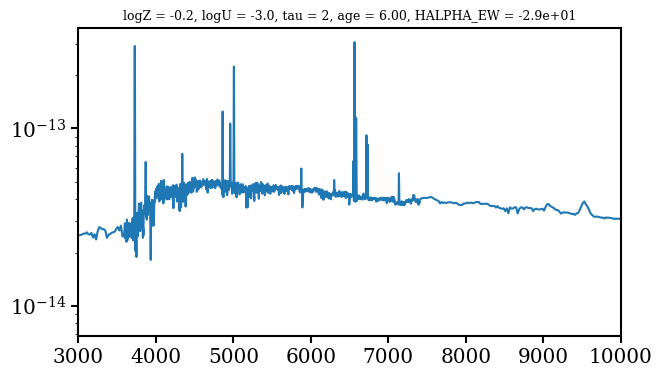

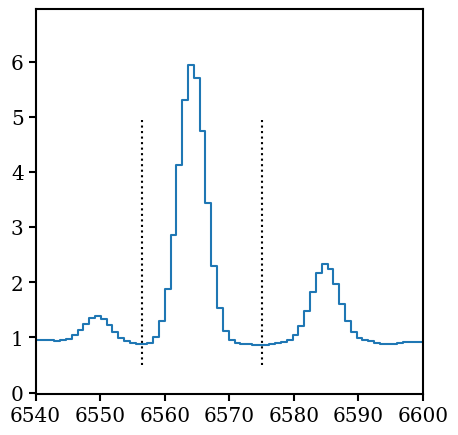

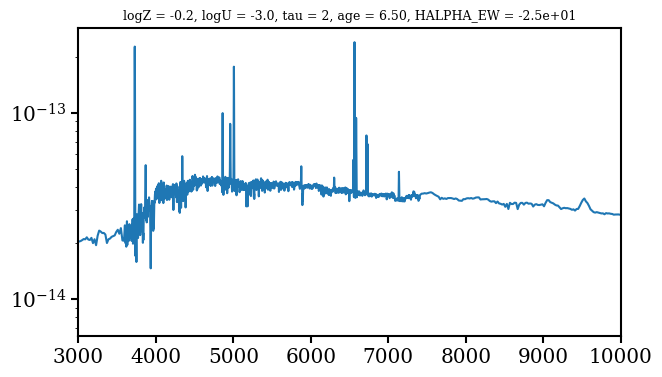

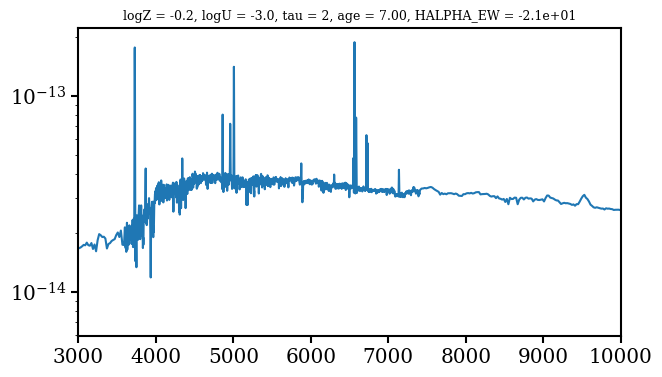

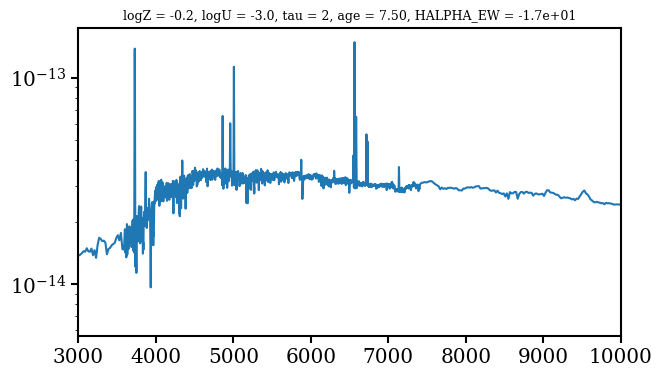

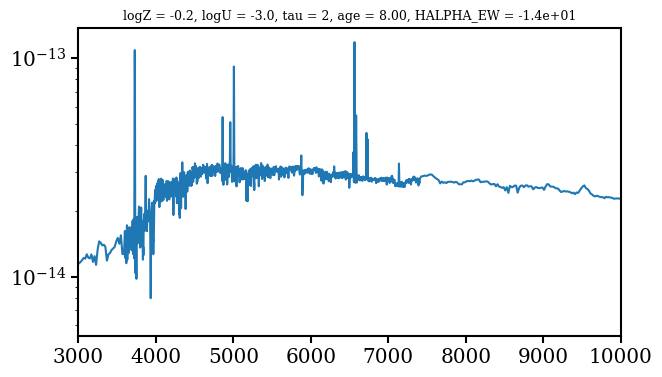

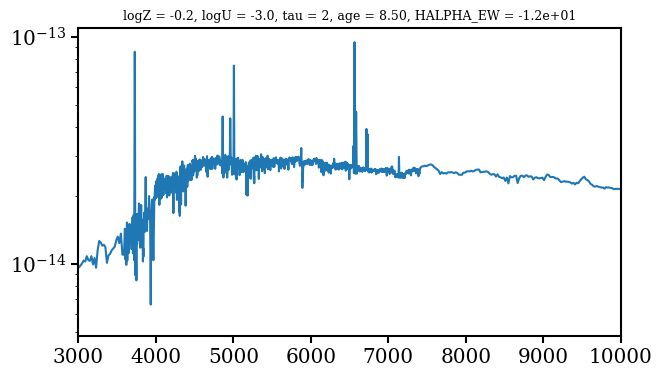

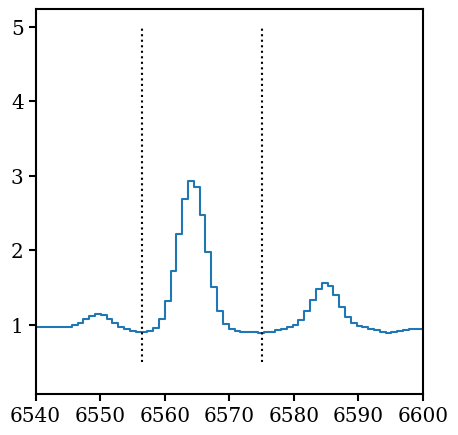

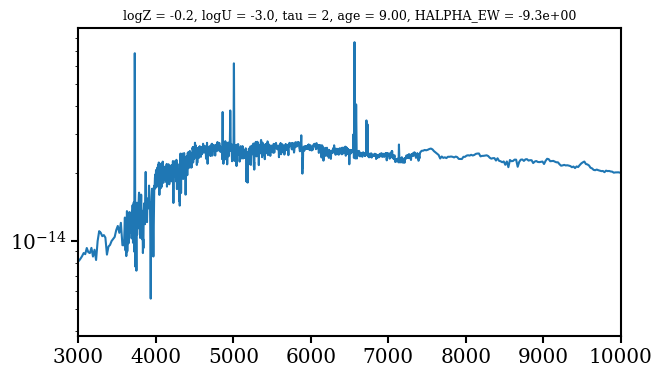

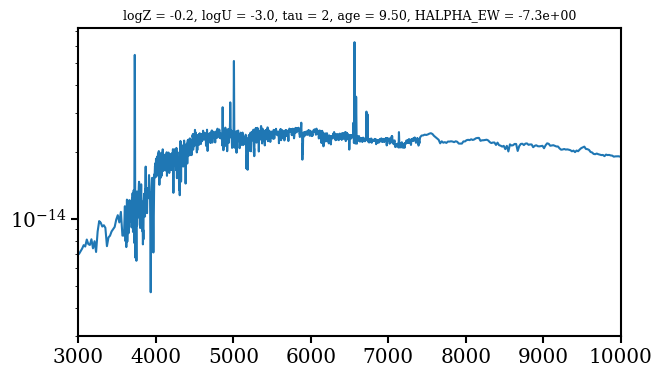

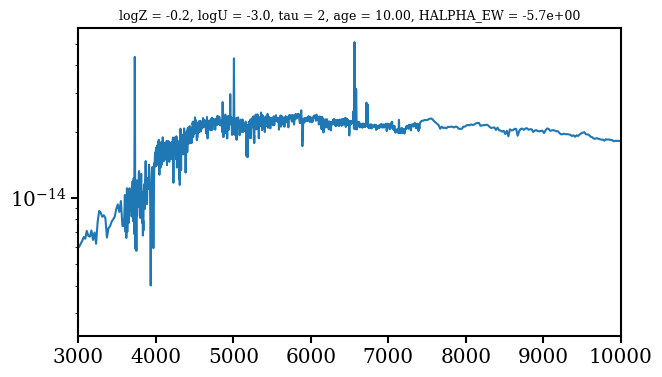

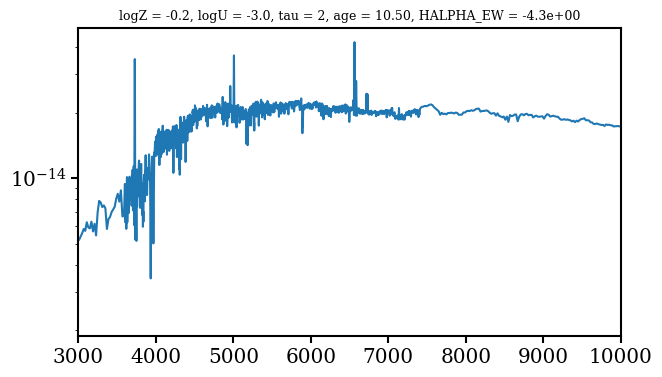

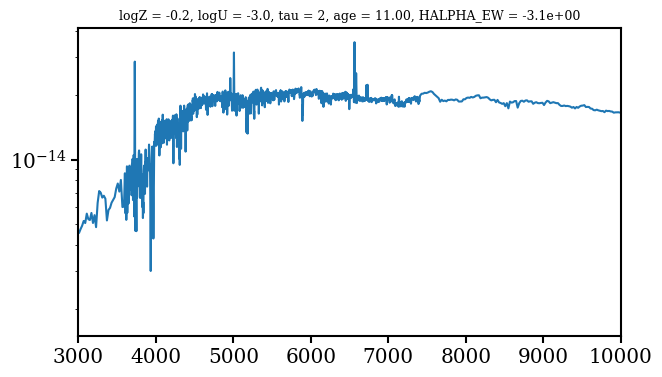

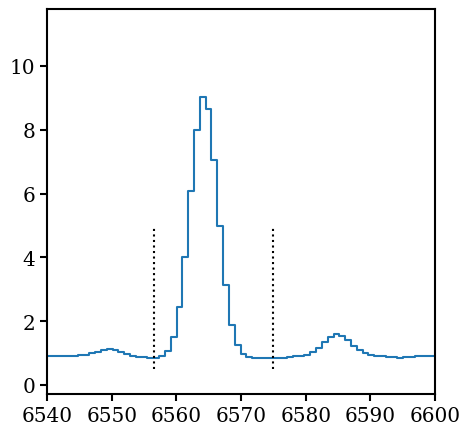

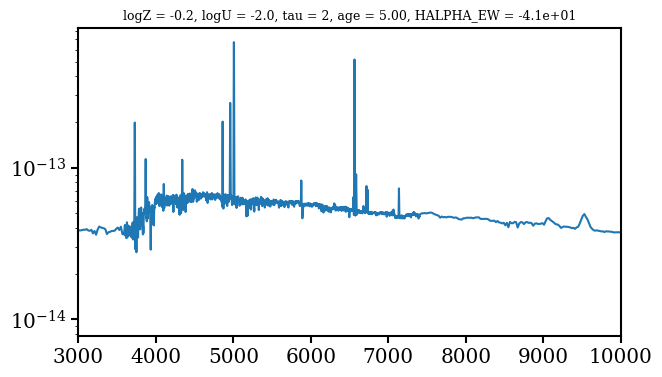

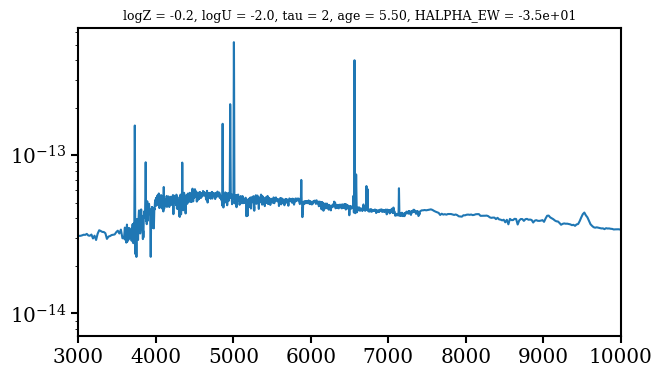

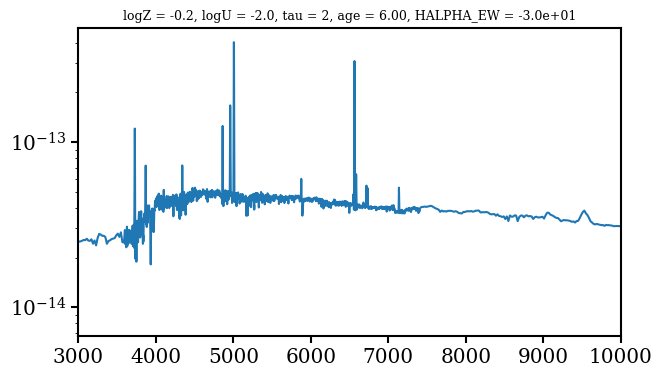

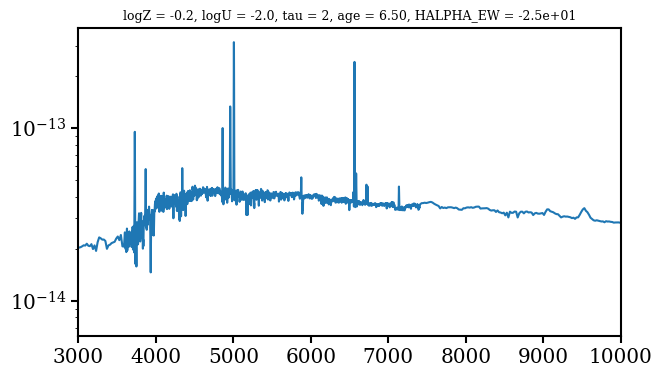

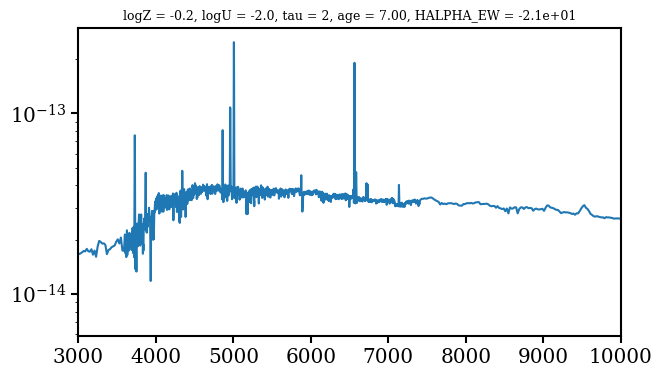

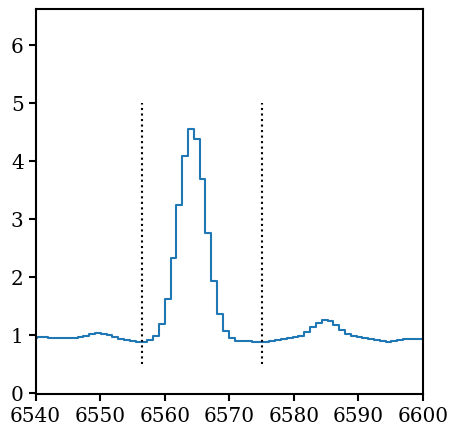

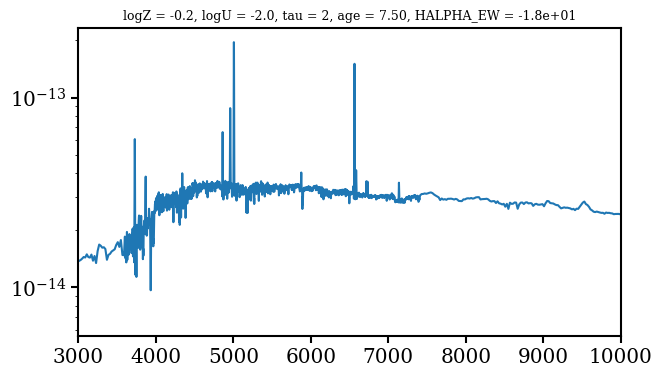

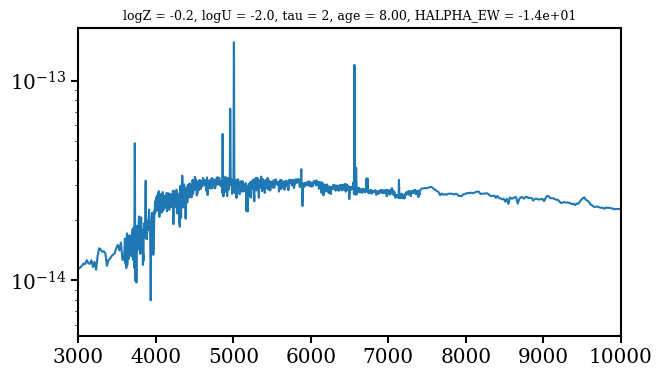

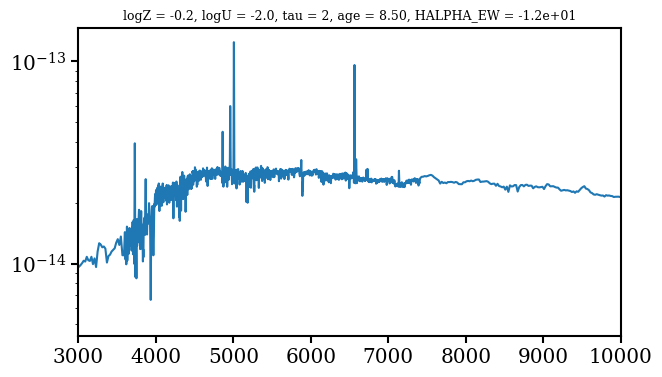

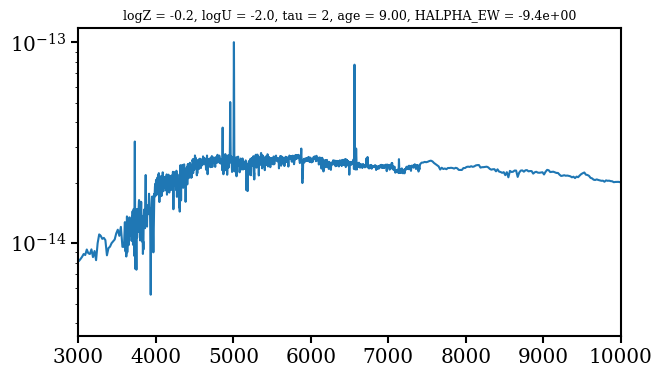

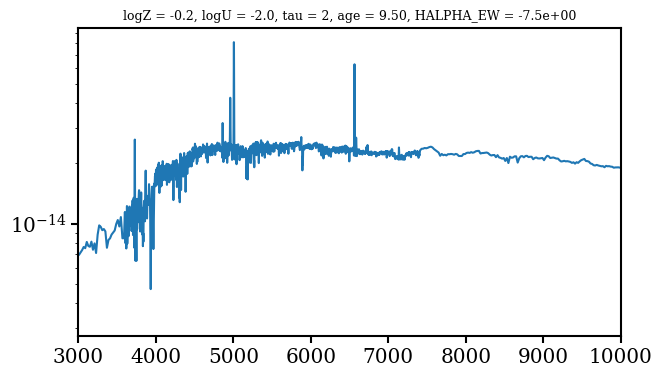

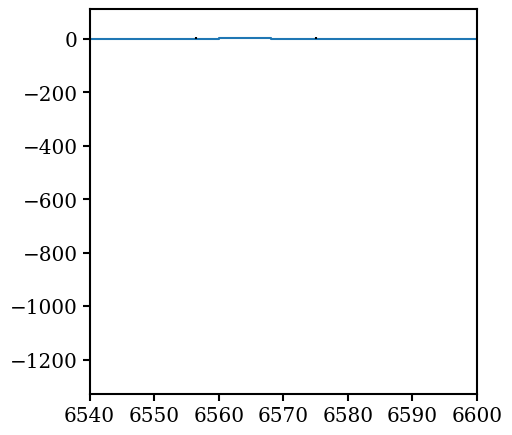

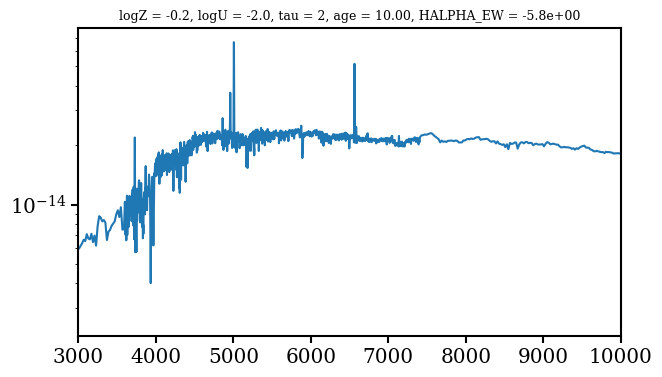

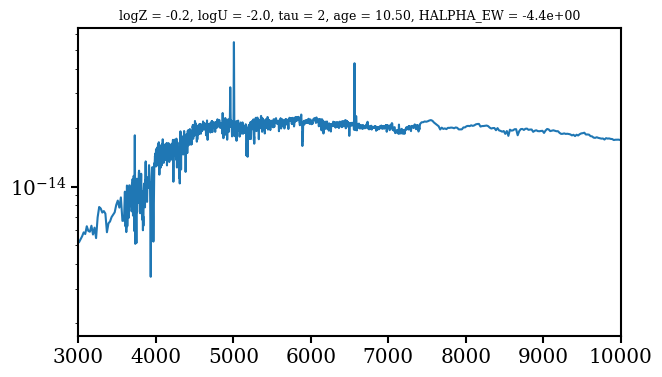

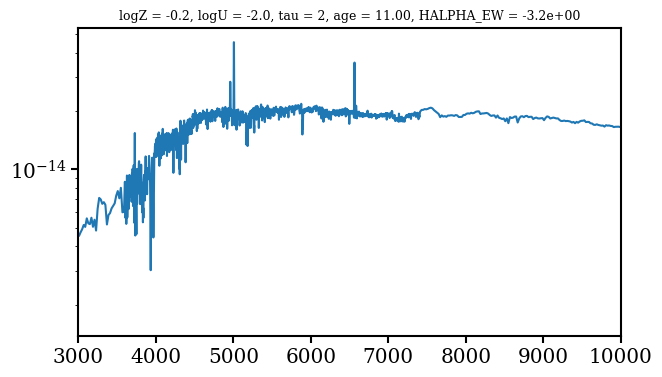

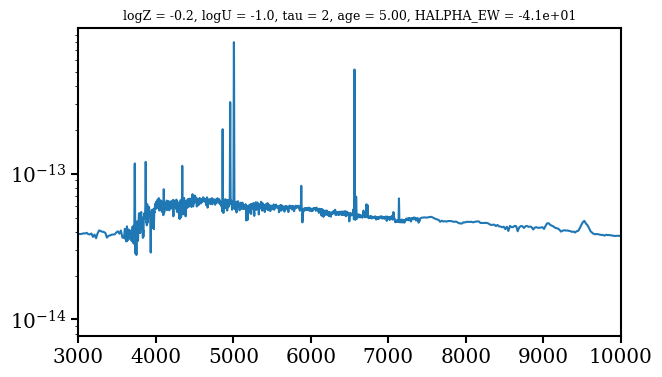

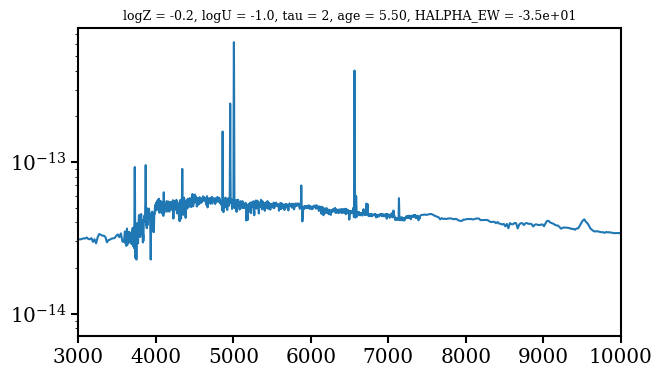

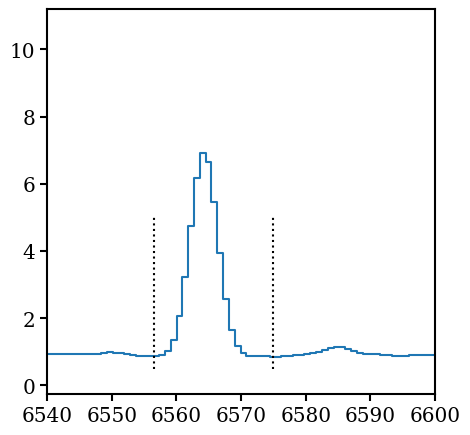

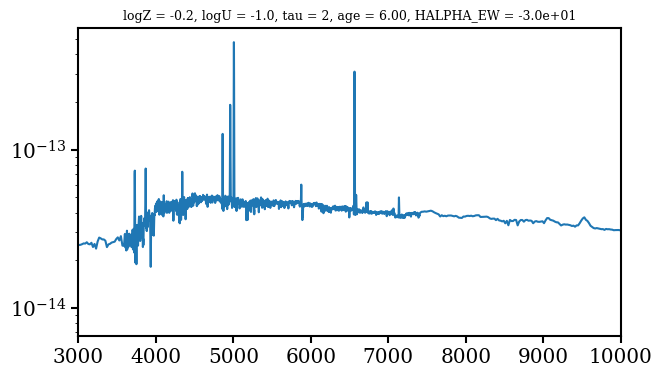

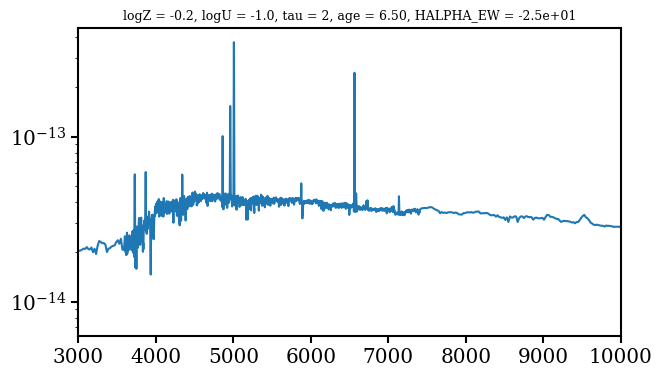

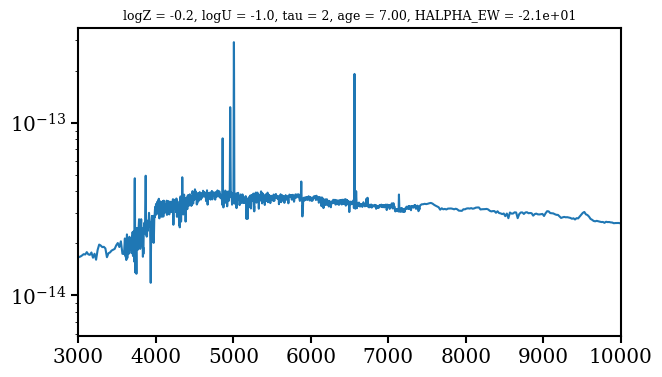

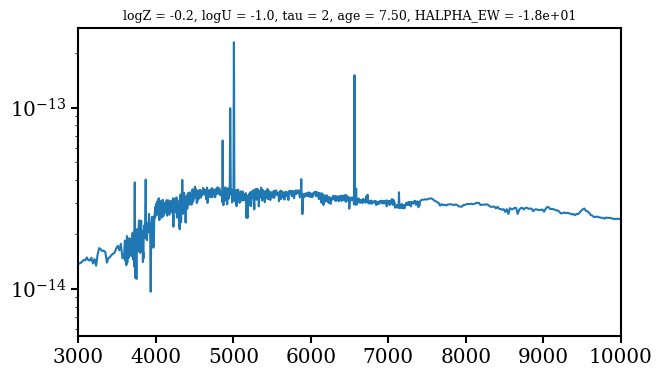

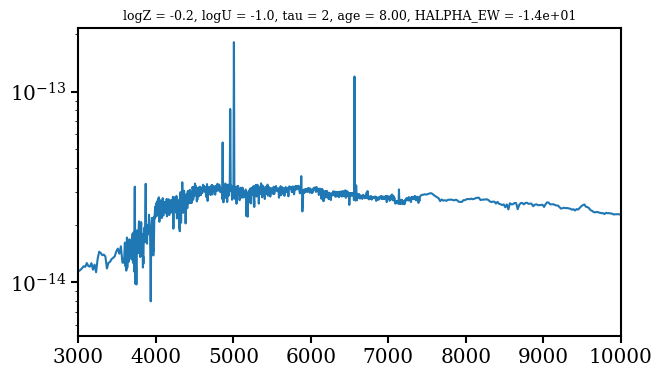

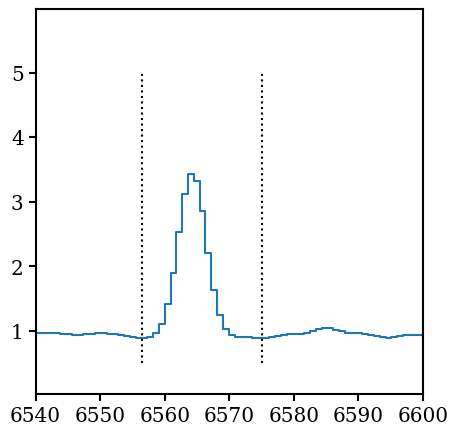

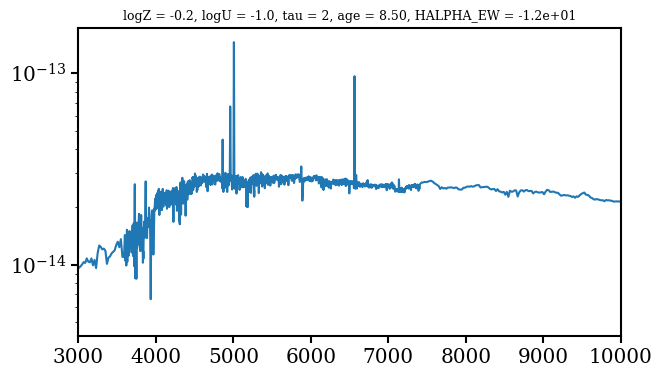

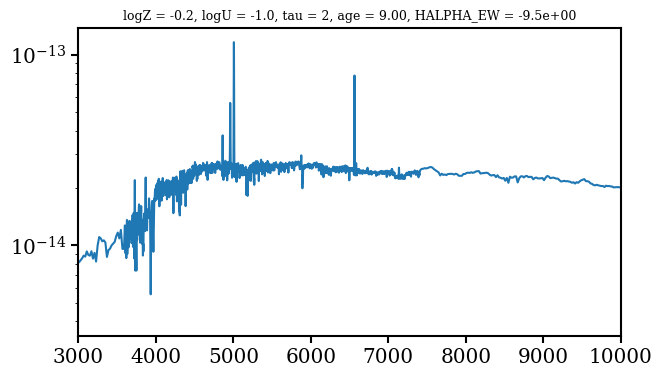

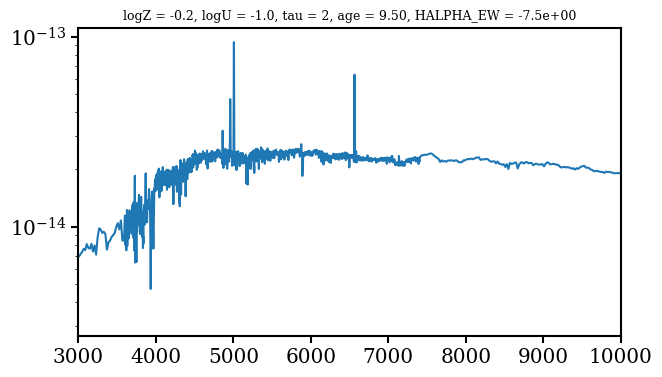

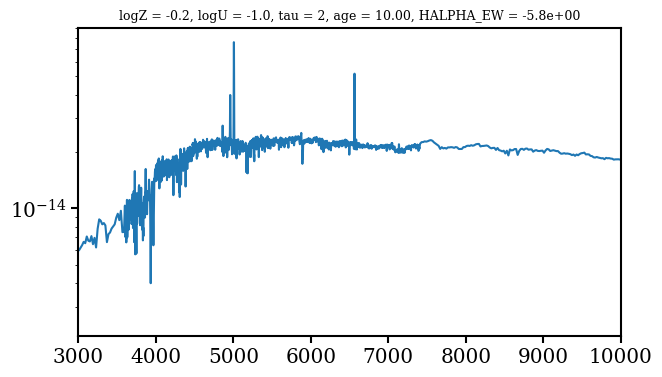

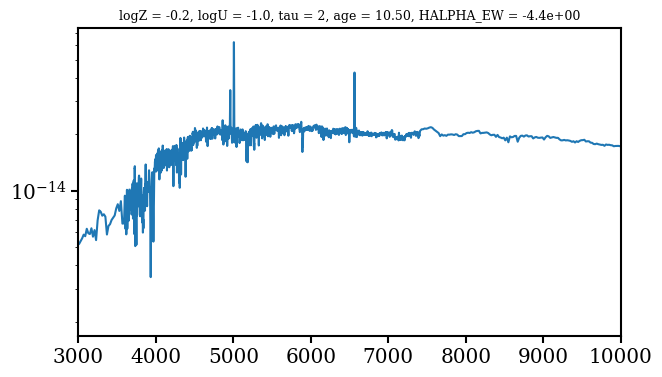

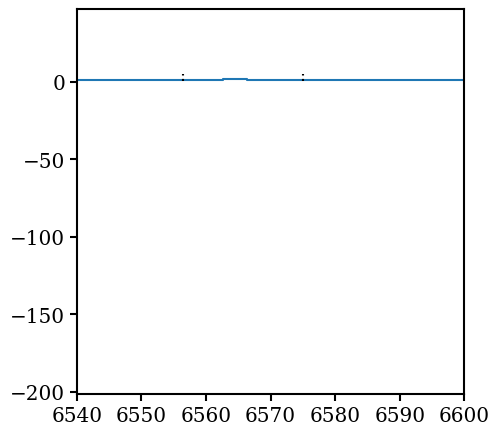

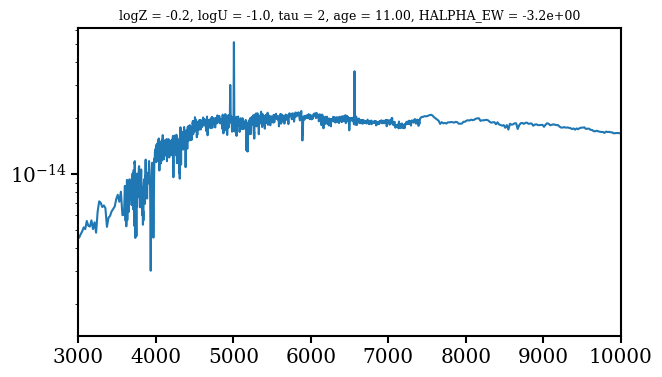

In [18]:

zmetals = np.array([-1,-0.75,-0.5,-0.25]) #4
gas_logus = np.array([-3, -2.0, -1.0]) #3
tau = np.array([2])
ages = np.arange(5,11.5,0.5) # 14


ssp_neb.params["tau"] = tau[0]

from tqdm.notebook import trange

all_logz = []
all_logu = []
all_tau = []
all_age = []
# all_halpha_flux = []
all_halpha_ew = []
all_Lgals = []

save_path = "/pscratch/sd/v/virajvm/fsps_model_spectra_V2/"

index = 0

for zi in trange(len(zmetals)):
    for ui in range(len(gas_logus)):
        for ti in range(len(tau)):
            #setting up the spectra object
            zmet_i = zmetals[zi]
            logu_i = gas_logus[ui]
            tau_i = tau[ti]

            ## setting the parameters now 
            ssp_neb.params['logzsol'] = zmet_i
            # # set parameters for nebular model
            ssp_neb.params['gas_logz'] = zmet_i # gas metallicity
            ssp_neb.params['gas_logu'] = logu_i # ionization parameter
            
            # print(ssp_neb.params["logzsol"],ssp_neb.params['gas_logz'],ssp_neb.params['gas_logu'],ssp_neb.params["tau"]  )
            #then go over all the ages
            for ai in range(len(ages)):
                ages_i = ages[ai]
                
                #save all the useful info
                all_logz.append(zmet_i)
                all_logu.append(logu_i)
                all_tau.append(tau_i)
                all_age.append(ages_i)
                all_Lgals.append(2e7)
                
                wave_i, flux_i = get_spectrum(ssp_neb,ages_i,zred=0.001,Lgal = 2e7,use_redshift=False)
                #this means that the units are in luminosity and not flux and we can multiply the redshift factor later in mock observing
                #the units are in ergs/s/A
                #wave is in A
                
                #just renomrlaizing it so better for the specutils 
                flux_i = flux_i * 1e-50
                
                #get halpha flux for this spectrum 
                # ha_flux_i = get_line_flux(ssp_neb,Lgal = 2e7,use_redshift=False)
                # all_halpha_flux.append(ha_flux_i)
                    
                if index % 5 == 0:
                    ew_val = get_line_ew(wave_i, flux_i,plot=True)
                else:
                    ew_val = get_line_ew(wave_i, flux_i,plot=False)
                    
                all_halpha_ew.append(ew_val)
                    
                
                #name of file to save the wave and flux array
                name_i = "mlogz_%.1f_mlogu_%.1f_tau_%d_age_%.2f"%(-1*zmet_i, -1*logu_i, tau_i, ages_i)
                
                np.savetxt(save_path + "spectra_emi_" + name_i  + ".txt", np.array([wave_i, flux_i]).T  )
                
                plt.figure(figsize = (7,4))
                plt.title("logZ = %.1f, logU = %.1f, tau = %d, age = %.2f, HALPHA_EW = %.1e"%(zmet_i, logu_i, tau_i, ages_i, ew_val),fontsize= 9)
                plt.plot(wave_i,flux_i)
                plt.xlim([3000,1e4])
                plt.yscale("log")
                plt.savefig(save_path + "plot_emi_%s.png"%name_i)
                index += 1
                
                if index % 5 == 0:
                    plt.show()
                else:
                    plt.close


In [21]:
all_spec_data = {"logZ" : all_logz, "logU" : all_logu, "tau" : all_tau , "age" : all_age, "HALPHA_EW": all_halpha_ew} 

spec_df = pd.DataFrame(all_spec_data)
## save this
spec_df.to_csv(save_path + "fsps_emi_model_summary_v2.csv")

In [22]:
len(all_logz)

156

In [ ]:
1+1

### I want to specifically understand what is redrock doing wrong with these high emission line FSPS galaxies ...
### I am not seeing such behavior in the real data so curious 

In [96]:
ssp_neb = fsps.StellarPopulation(zcontinuous = 1, add_neb_emission = 1, 
                                 smooth_velocity = True,sigma_smooth = 50, dust_type = 2, dust2= 0.2, sfh=1)



In [168]:
## so the metal rich end of -0.25 seems to be doing fin with ionizatrion parameters of -1 and -3
## the low metallicity end of -1.5 seems to be giving some problems at z=0.15
#so let us keep the lowest metallicity to be -1 and age to be 5

## setting the parameters now 
ssp_neb.params['logzsol'] = -1
# # set parameters for nebular model
ssp_neb.params['gas_logz'] = -1 # gas metallicity
ssp_neb.params['gas_logu'] = -3 # ionization parameter
ssp_neb.params["tau"] = 2

redshift = 0.01

wave_i, flux_i = get_spectrum(ssp_neb,11.5,zred=redshift,Lgal = 2e7,use_redshift=False)
#this means that the units are in luminosity and not flux and we can multiply the redshift factor later in mock observing
#the units are in ergs/s/A
#wave is in A



decam2014-r
-----------
       19.0
decam2014-r
-----------
       19.0
decam2014-r
-----------
       19.0
decam2014-r
-----------
       19.0
decam2014-r
-----------
       19.0


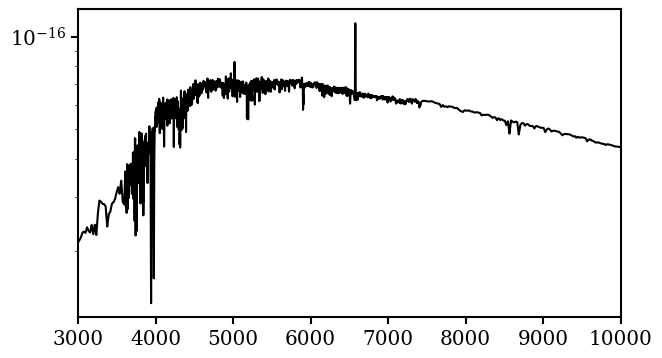

In [169]:
### do the full redshift range from z = 0 to z0.15
import speclite.filters
decam = speclite.filters.load_filters('decam2014-r','decam2014-z' )

# zgrid = np.random.uniform(low = 0.001, high = 0.15, size = 500)
# zgrid = np.ones(10)*0

zgrid = np.ones(10)*0.15
zgrid[:5] = zgrid[:5]*0 + 0.002


wave_if = np.arange(3000, 1.2e4, 0.2)
wlen = wave_if * u.Angstrom

all_fluxs = []

for i,zi in enumerate(zgrid):
    # interpolate spectra to same wavelength grid as DESI 
    interp_flux = interp1d(wave_i * (1+zi), flux_i) 
    flux_if = interp_flux(wave_if)
    
    #compute the magnitude now 
    flux_unis = flux_if * 10**(-55) * u.erg / (u.cm**2 * u.s * u.Angstrom)

    mags_decam = decam.get_ab_magnitudes(flux_unis, wlen)
    
    rmags_decam = mags_decam["decam2014-r"]

    flux_factor = 10**(0.4*(rmags_decam - 19))
    flux_iff = flux_if * flux_factor * 10**(-55)

    if i < 5:
        temp = decam.get_ab_magnitudes(flux_unis * flux_factor,  wlen)
        print(temp["decam2014-r"])
    
    all_fluxs.append(flux_iff)
    

plt.figure(figsize = (7,4))
plt.plot(wave_if ,all_fluxs[0],color = "k")
# plt.plot(wave_if * (1+ 1.2) / (1+0.25) ,all_fluxs[0],color = "r")

plt.xlim([3000,1e4])
plt.yscale("log")
plt.show()

#### Develop code to compute spectra EW

In [164]:
from specutils import Spectrum1D
from specutils.fitting import fit_generic_continuum

lamb = wave_if * u.Angstrom
flux = all_fluxs[0] * u.Unit('erg cm-2 s-1 AA-1')
spec = Spectrum1D(spectral_axis=lamb, flux=flux) 
cont_norm_spec = spec / fit_generic_continuum(spec)(spec.spectral_axis)

from specutils import SpectralRegion
from specutils.analysis import equivalent_width
equivalent_width(cont_norm_spec, regions=SpectralRegion(6556.5 * u.AA, 6575 * u.AA))

In [177]:
## compute the line flux as well

from specutils.analysis import line_flux
line_flux(spec, SpectralRegion(6556.5 * u.AA, 6575 * u.AA)).value

1.3682996610085832e-15

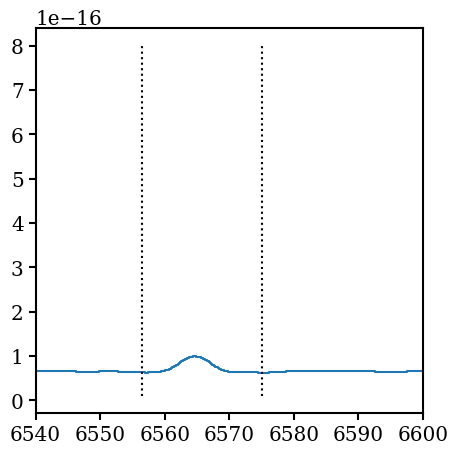

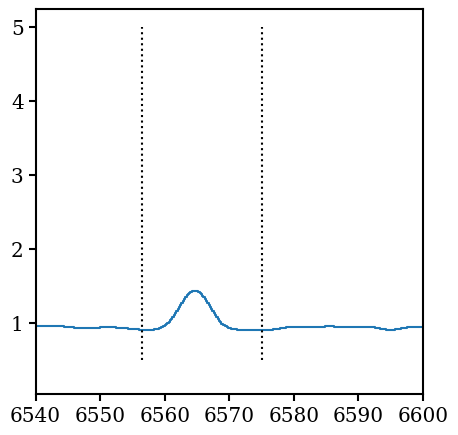

In [161]:
f, ax = plt.subplots(figsize = (5,5))  
ax.step(spec.spectral_axis, spec.flux) 
ax.set_xlim([6540,6600])
ax.vlines(x = 6556.5, ymin=1e-17,ymax=8e-16,color = "k",ls = "dotted")
ax.vlines(x = 6575, ymin=1e-17,ymax=8e-16,color = "k",ls = "dotted")
plt.show()


f, ax = plt.subplots(figsize = (5,5))  
ax.step(cont_norm_spec.wavelength, cont_norm_spec.flux)  
ax.set_xlim([6540,6600])
ax.vlines(x = 6556.5, ymin=0.5,ymax=5,color = "k",ls = "dotted")
ax.vlines(x = 6575, ymin=0.5,ymax=5,color = "k",ls = "dotted")
plt.show()

In [174]:
from specutils import SpectralRegion
from specutils.analysis import equivalent_width
equivalent_width(cont_norm_spec, regions=SpectralRegion(6556.5 * u.AA, 6575 * u.AA))

<Quantity -1.24006101 Angstrom>

In [131]:
# summ_df = Table.read("fsps_model_spectra/fsps_emi_model_summary.csv")
# ## for the emi model I am only using model with age >=4
# summ_df = summ_df[ (summ_df["age"] >= 4) & (summ_df["tau"] == 2) ]
# print(len(summ_df))

In [170]:
## let us mock observe this ...

from scipy.interpolate import UnivariateSpline
import sys
sys.path.append('/global/u1/v/virajvm/DESI2_LOWZ/feasiBGS')
from feasibgs import forwardmodel as FM 

fdesi = FM.fakeDESIspec()
    
specdata = fdesi.simExposure(wave = wave_if, flux = np.array(all_fluxs)*1e17, airmass = 1.0, 
                                 exptime=180,seeing = 1.1,filename = "temp.fits")

## let us add scores 
add_scores("temp.fits", cts = len(all_fluxs) )


INFO:spectra.py:177:write_spectra: iotime 0.059 sec to write temp.fits at 2024-12-08T15:46:51.605347


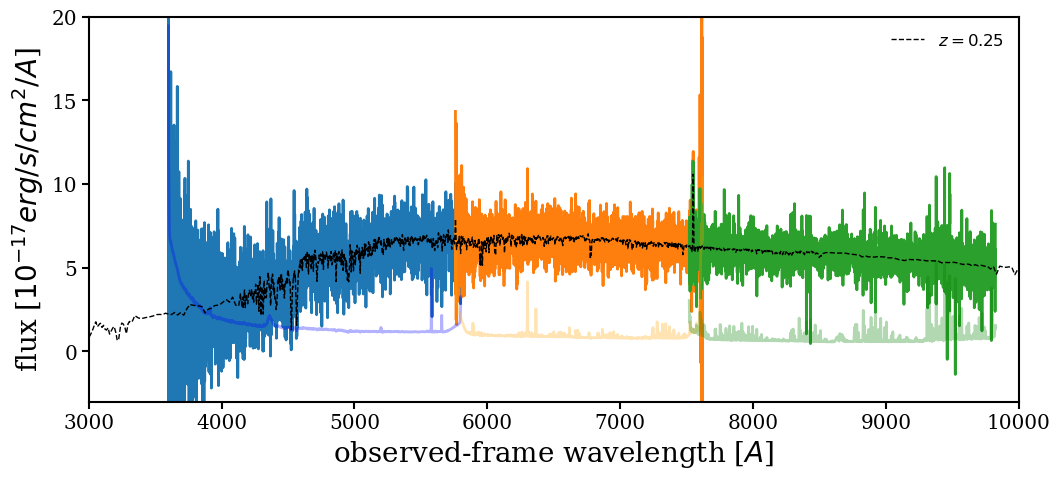

In [171]:
fig = plt.figure(figsize=(12,5))
index = 5
sub = fig.add_subplot(111)
sub.plot(specdata.wave["b"], specdata.flux["b"][index],lw = 2)
sub.plot(specdata.wave["r"], specdata.flux["r"][index],lw = 2)
sub.plot(specdata.wave["z"], specdata.flux["z"][index],lw = 2)

sub.plot(specdata.wave["b"], 1/np.sqrt(specdata.ivar["b"][index]),lw = 2,color = "blue",alpha = 0.3)
sub.plot(specdata.wave["r"], 1/np.sqrt(specdata.ivar["r"][index]),lw = 2,color = "orange",alpha = 0.3)
sub.plot(specdata.wave["z"], 1/np.sqrt(specdata.ivar["z"][index]),lw = 2,color = "green",alpha = 0.3)

sub.plot(wave_if, all_fluxs[index]*1e17, c='k', ls='--',lw = 1,label = "$z = 0.25$")

sub.legend(frameon=False,fontsize = 12)


sub.set_xlabel('observed-frame wavelength [$A$]', fontsize=20)
sub.set_xlim(3e3, 1e4)
sub.set_ylabel('flux [$10^{-17} erg/s/cm^2/A$]', fontsize=20)
sub.set_ylim(-3, 20)

plt.show()



In [172]:

#  source /global/common/software/desi/desi_environment.sh 23.1
 
# And then the following command is ran 

# rrdesi -i "/global/u1/v/virajvm/DESI2_LOWZ/data/bgs_mock_spectra/temp_0.fits" -d "temp_zbest.fits" -o "temp_out.fits"


tab_tot = Table.read("temp_out.fits")
tab_tot
## try using the COEFF to restronct the fitted spectra!!

TARGETID,Z,ZERR,ZWARN,CHI2,COEFF,FITMETHOD,NPIXELS,SPECTYPE,SUBTYPE,NCOEFF,DELTACHI2
int64,float64,float64,int64,float64,float64[10],bytes4,int64,bytes6,bytes20,int64,float64
0,0.0020316942642953735,4.526258810384154e-05,0,8122.866434923129,1702.3728283421754 .. -7.893821309475566,PCA,7930,GALAXY,--,10,90.03323205818742
1,0.0019308071065182897,3.258353799981707e-05,0,8051.7354889246235,1727.7455727583483 .. 11.949480456510083,PCA,7930,GALAXY,--,10,265.3095569679572
2,0.0020240948573052304,0.00010806200278840901,0,8087.807089625746,1375.9283869642802 .. -16.52641739054341,PCA,7930,GALAXY,--,10,112.84142998126572
3,0.002050147316186666,3.7065363794944824e-05,0,8305.573897080916,1486.0316830870936 .. -13.999870378811721,PCA,7930,GALAXY,--,10,45.58455700006016
4,0.0020537764295134836,4.412464667045711e-05,0,8187.0993660634185,1559.5208765949146 .. -2.575175325121112,PCA,7930,GALAXY,--,10,63.93412339098268
5,0.15001046900704978,3.535830436344885e-05,0,7986.163733933121,1249.0272714096006 .. -5.808836654113709,PCA,7930,GALAXY,--,10,482.2530515100807
6,0.14998866915135345,3.897225478725782e-05,0,8127.86972239241,1130.2028475096915 .. -17.45669856860141,PCA,7930,GALAXY,--,10,482.9605391174555
7,0.15002812045916836,3.902056897293413e-05,0,8138.302954137325,1296.6153771064573 .. -13.848032184115306,PCA,7930,GALAXY,--,10,509.2895651049912
8,0.15001834840485465,4.209717290266078e-05,0,8014.203527441248,1181.2900336736222 .. -20.930306542529873,PCA,7930,GALAXY,--,10,525.4970295233652


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


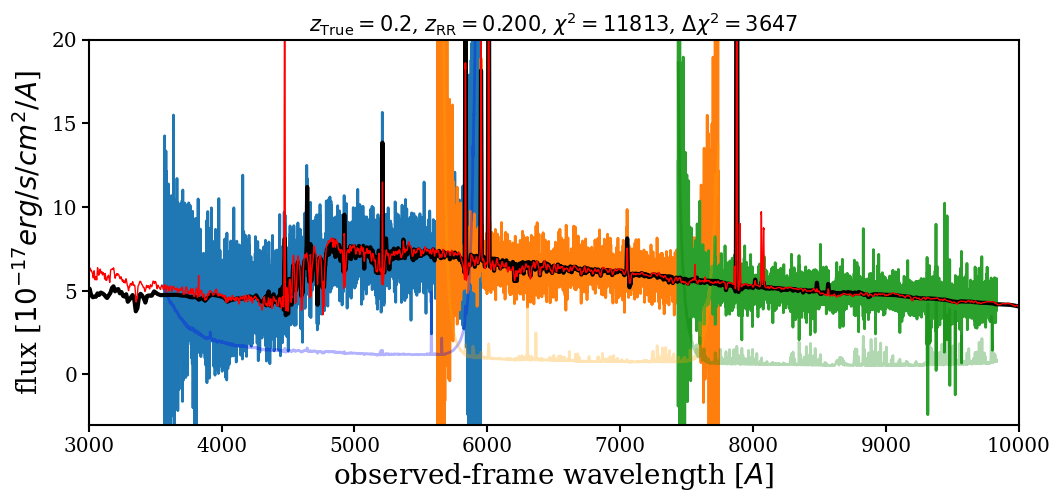

In [317]:
fig = plt.figure(figsize=(12,5))
index = 5
sub = fig.add_subplot(111)

plt.title(r"$z_{\rm True} = 0.2$, $z_{\rm RR} = %.3f$, $\chi^2 = %d$, $\Delta\chi^2 = %d$"%(tab_tot["Z"][index], tab_tot["CHI2"][index] , tab_tot["DELTACHI2"][index] ) ,fontsize=15 )
sub.plot(specdata.wave["b"], specdata.flux["b"][index],lw = 2)
sub.plot(specdata.wave["r"], specdata.flux["r"][index],lw = 2)
sub.plot(specdata.wave["z"], specdata.flux["z"][index],lw = 2)

sub.plot(specdata.wave["b"], 1/np.sqrt(specdata.ivar["b"][index]),lw = 2,color = "blue",alpha = 0.3)
sub.plot(specdata.wave["r"], 1/np.sqrt(specdata.ivar["r"][index]),lw = 2,color = "orange",alpha = 0.3)
sub.plot(specdata.wave["z"], 1/np.sqrt(specdata.ivar["z"][index]),lw = 2,color = "green",alpha = 0.3)

sub.plot(wave_if, all_fluxs[index]*1e17, c='k', ls='-',lw = 3)

sub.legend(frameon=False,fontsize = 12)

spectype = tab_tot['SPECTYPE'][index].strip()
subtype = ''
fulltype = (spectype, subtype)

ncoeff = templates[fulltype].flux.shape[0]
coeff = tab_tot['COEFF'][0][0:ncoeff]

tflux = templates[fulltype].flux.T.dot(coeff)
twave = templates[fulltype].wave * (1+tab_tot["Z"][index])

sub.plot( twave, tflux, color = "r", lw = 1)

sub.set_xlabel('observed-frame wavelength [$A$]', fontsize=20)
sub.set_xlim(3e3, 1e4)
sub.set_ylabel('flux [$10^{-17} erg/s/cm^2/A$]', fontsize=20)
sub.set_ylim(-3, 20)

plt.show()



In [ ]:
### so this problem seems to be due to certain prominent emission lines overlapping with the noisy arms of spec??
### this seems like it should not be an issue, 

In [649]:
### let us run redrock on this new object 

#  source /global/common/software/desi/desi_environment.sh 23.1
 
# And then the following command is ran 

# rrdesi -i "/global/u1/v/virajvm/DESI2_LOWZ/data/bgs_mock_spectra/temp_0.fits" -d "temp_zbest.fits" -o "temp_out.fits"

 

In [5]:
from astropy.table import vstack
tab_tot = Table.read("/pscratch/sd/v/virajvm/temp19_out_0.fits")
for di in trange(1,30):
    temp_i = Table.read("/pscratch/sd/v/virajvm/temp19_out_%d.fits"%di)

    #add this to above
    tab_tot = vstack([tab_tot, temp_i])

tab_tot.write("/pscratch/sd/v/virajvm/temp19_out_total.fits",overwrite=True)

100%|██████████| 29/29 [00:00<00:00, 62.58it/s]


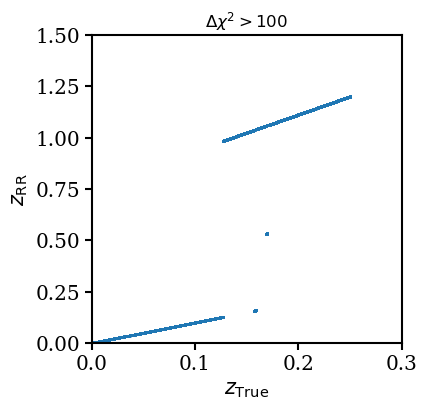

In [6]:
plt.figure(figsize = (4,4))
gmask = (tab_tot["DELTACHI2"] > 100)

plt.title(r"$\Delta\chi^2>100$")
plt.scatter( tab_tot[gmask]["Z_TRUE"], tab_tot[gmask]["Z"],s=1)
plt.xlim([0,0.3])
plt.ylim([0,1.5])
plt.xlabel(r"$z_{\rm True}$",fontsize = 15)
plt.ylabel(r"$z_{\rm RR}$",fontsize = 15)
plt.show()

In [7]:
## in each bin of zgrid, compute the average success rate??
zbins = np.linspace(0.001,0.3,30)
zcens = 0.5*( zbins[1:] + zbins[:-1])
bad_fracs = []

for i in range(len(zbins)-1):
    temp = tab_tot[ (tab_tot["Z_TRUE"] > zbins[i]) & (tab_tot["Z_TRUE"] < zbins[i+1]) ]

    cat_mask = ((np.abs(temp["Z"] - temp["Z_TRUE"])/(1 + temp["Z_TRUE"])) < 0.003)
    
    bad_frac = np.sum(cat_mask)/len(cat_mask)
    bad_fracs.append(bad_frac)
    


/tmp/ipykernel_1243789/813161195.py:11: RuntimeWarning: invalid value encountered in long_scalars
  bad_frac = np.sum(cat_mask)/len(cat_mask)


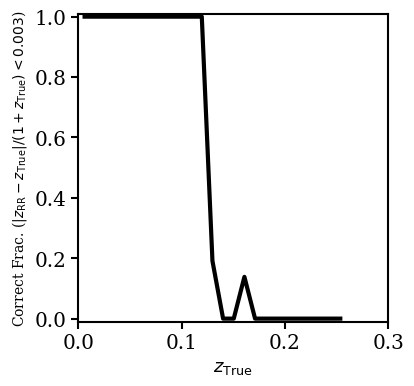

In [8]:
plt.figure(figsize = (4,4))
plt.plot(zcens, bad_fracs,lw = 3,color = "k")
plt.xlim([0,0.3])
# plt.vlines(x = 0.1,ymin=0,ymax=1,color = "r",ls ="dotted")
# plt.vlines(x = 0.04,ymin=0,ymax=1,color = "r",ls ="dotted")

plt.ylim([-0.01,1.01])
plt.xlabel(r"$z_{\rm True}$",fontsize = 13)
plt.ylabel(r"Correct Frac. ($|z_{\rm RR} - z_{\rm True}| / (1+z_{\rm True}) <0.003$)",fontsize = 10)
plt.show()

In [307]:
#### plot some examples to show ... 
import redrock.templates

templates = dict()
for filename in redrock.templates.find_templates():
    t = redrock.templates.Template(filename)
    templates[(t.template_type, t.sub_type)] = t

DEBUG: Read templates from /global/common/software/desi/perlmutter/desiconda/20230111-2.1.0/code/redrock-templates/0.8
DEBUG: Using default redshift range -0.0050-1.6997 for rrtemplate-galaxy.fits
DEBUG: Using redshift range 1.4000-6.9930 for rrtemplate-qso-HIZ.fits
DEBUG: Using redshift range 0.0500-1.5983 for rrtemplate-qso-LOZ.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-A.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-B.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-CV.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-F.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-G.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-K.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-M.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-WD.fits


In [59]:
tab_tot[:10]

TARGETID,Z,ZERR,ZWARN,CHI2,COEFF,FITMETHOD,NPIXELS,SPECTYPE,SUBTYPE,NCOEFF,DELTACHI2,Z_TRUE
int64,float64,float64,int64,float64,float64[10],bytes4,int64,bytes6,bytes20,int64,float64,float64
0,0.027874937743358166,5.328995944092985e-06,0,27345.305506050587,6231.885358627364 .. 214.66829017868338,PCA,8589,GALAXY,,10,4308.6016382575035,0.02787432500217108
1,1.0184165335279605,6.3346411175122545e-06,0,23549.056827545166,-4936.096914166791 .. -68.95881398902013,PCA,8589,GALAXY,,10,4203.93080997467,0.14641740691952887
2,0.036396784363970626,5.191369322287508e-06,0,27029.946348041296,6958.03537320091 .. 255.12931372409847,PCA,8589,GALAXY,,10,4759.568043857813,0.03637278190983353
3,0.03177946129287868,5.078556728700909e-06,0,26781.871590547264,6916.808547872759 .. 264.0260462716852,PCA,8589,GALAXY,,10,4747.817398376763,0.03175716901984236
4,1.170148520238972,5.512476467172697e-06,0,29704.438957214355,-5102.578304111671 .. -55.25527178586689,PCA,8589,GALAXY,,10,4338.697359323502,0.23258853890495565
5,1.0740010075760877,5.971623089848577e-06,0,27565.890544891357,-4910.237971819166 .. -49.89847544032449,PCA,8589,GALAXY,,10,4303.764176368713,0.17799861931447114
6,0.9909989434390017,6.0503922949181845e-06,0,27493.64287185669,-4816.63648726894 .. -51.16016269397989,PCA,8589,GALAXY,,10,1586.365330338478,0.13084203364050154
7,1.1424736942024925,7.0401925035036834e-06,0,27971.13121032715,-5075.027212731602 .. -29.8169006441157,PCA,8589,GALAXY,,10,5802.143314599991,0.21686988332760546
8,0.06990193091868477,5.401069103489964e-06,0,27599.630163490772,6080.881780260511 .. 195.27500586011595,PCA,8589,GALAXY,,10,4444.571278274059,0.06988925243963028


In [ ]:
# fits.open("/pscratch/sd/v/virajvm/temp19_0.fits")[4].header

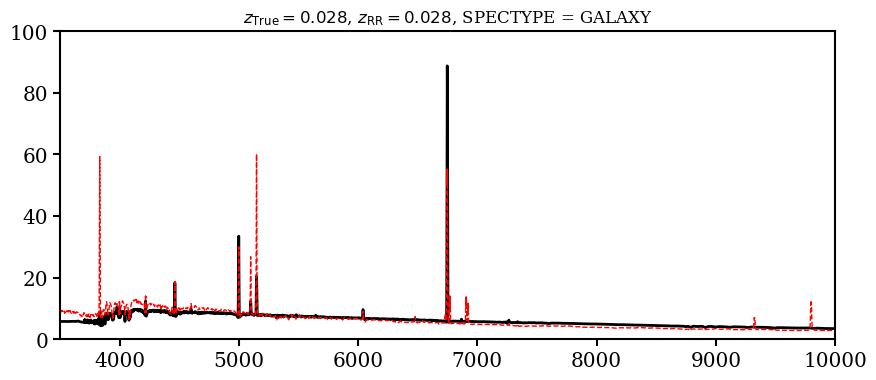

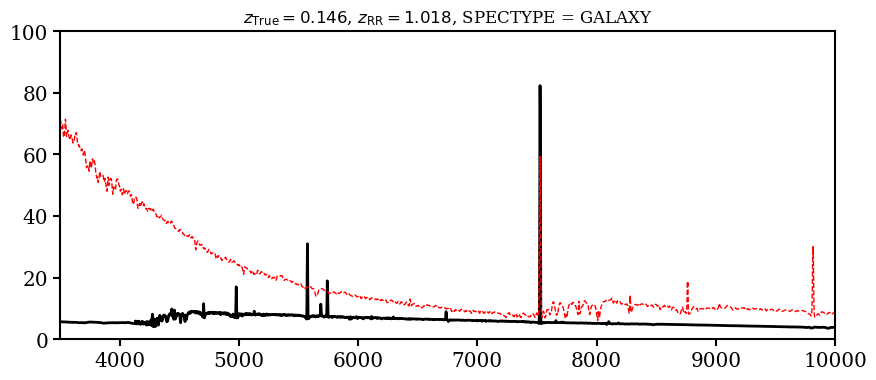

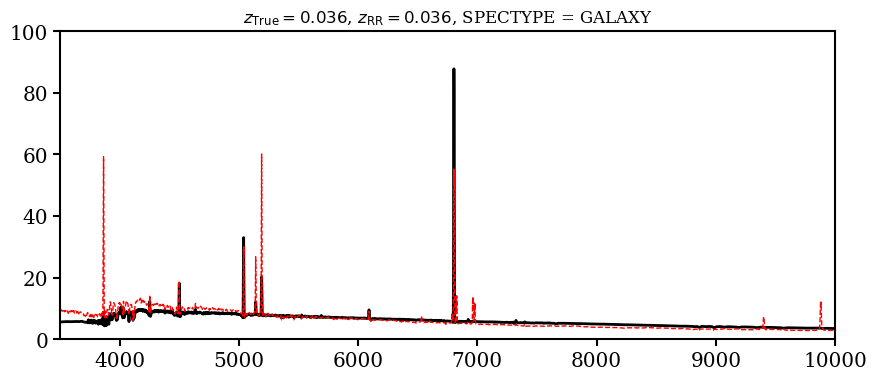

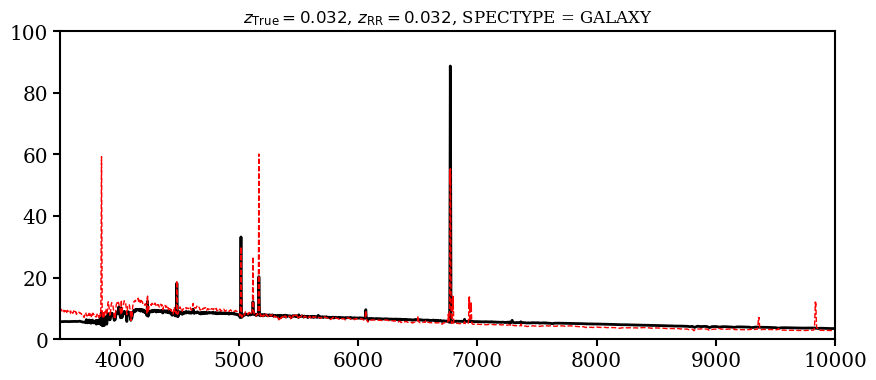

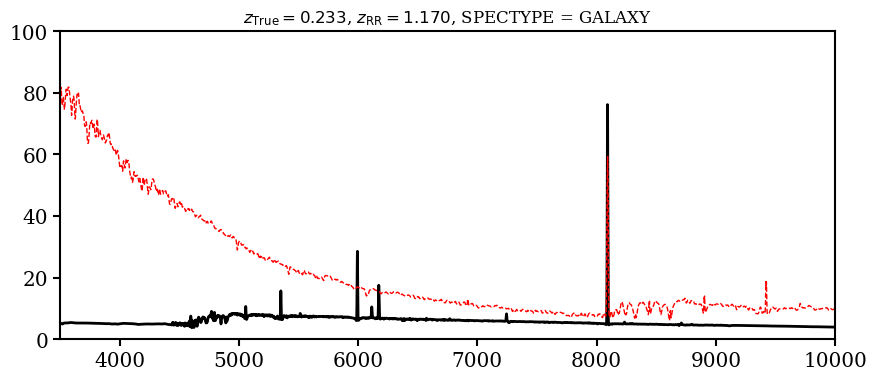

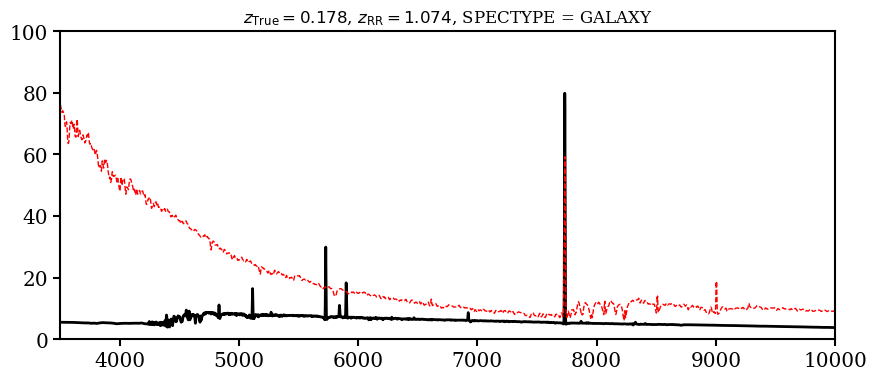

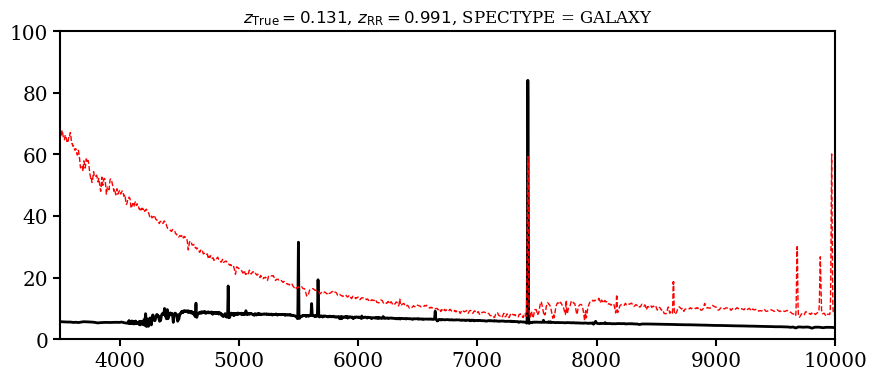

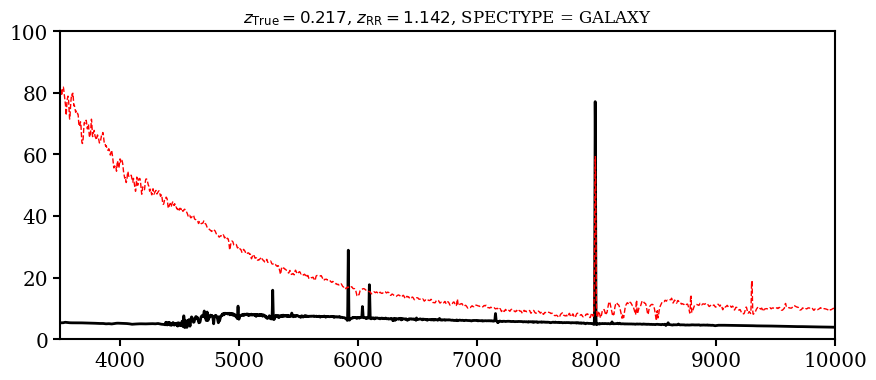

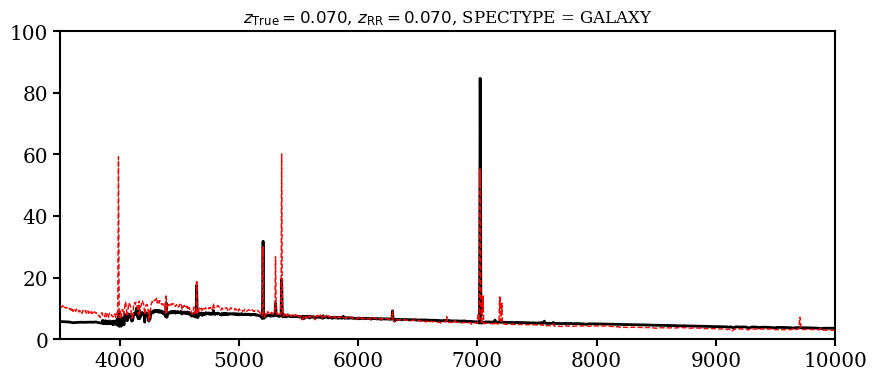

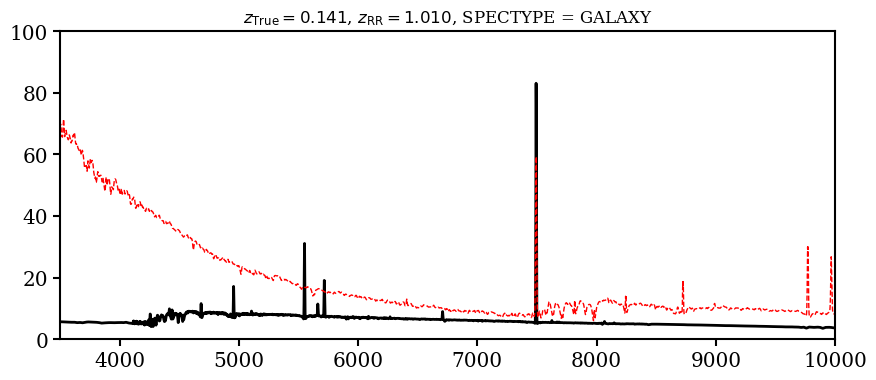

In [58]:
for i in range(10):
    z = tab_tot['Z'][i]
    ztrue = tab_tot['Z_TRUE'][i]

    ## load the mock spectum

    wave_if = np.arange(3000, 1.2e4, 0.2)
    wlen = wave_if * u.Angstrom
    # interpolate spectra to same wavelength grid as DESI 
    interp_flux = interp1d(wave_i * (1+ztrue), flux_i) 
    flux_if = interp_flux(wave_if)
    #compute the magnitude now 
    flux_unis = flux_if * 10**(-55) * u.erg / (u.cm**2 * u.s * u.Angstrom)
    mags_decam = decam.get_ab_magnitudes(flux_unis, wlen)
    rmags_decam = mags_decam["decam2014-r"]
    flux_factor = 10**(0.4*(rmags_decam -  19))
    flux_iff = flux_if * flux_factor * 10**(-55)


    spectype = tab_tot['SPECTYPE'][i].strip()
    subtype = tab_tot['SUBTYPE'][i].strip()
    fulltype = (spectype, subtype)

    ncoeff = templates[fulltype].flux.shape[0]
    coeff = tab_tot['COEFF'][0][0:ncoeff]

    tflux = templates[fulltype].flux.T.dot(coeff)
    twave = templates[fulltype].wave * (1+z)
    
    
    
    ## plot the real spectra 
    plt.figure(figsize = (10,4))
    plt.title(r"$z_{\rm True} = %.3f$, $z_{\rm RR} = %.3f$, SPECTYPE = %s"%(ztrue, z, spectype ))
    plt.plot(wave_if, flux_iff * 1e17, 'k',lw=2,label = r"$z_{\rm True} = %.3f$"%ztrue)
    
    #plot the ivar ..

    plt.plot(twave, tflux, 'r--',lw = 1,label = r"$z_{\rm RR} = %.3f$"%(z))
    plt.ylim([0,100])
    plt.xlim(3500, 10000)
    plt.savefig(r"temp_plots/fit_%d.png"%i,bbox_inches="tight")
    plt.show()

## With the mock spectra, get a range of true spectra so they span a wide range in redshift, Halpha flux, and fiber mag!

In [12]:

import speclite.filters
decam = speclite.filters.load_filters('decam2014-*')

def apply_flux(wave, flux, ha_flux, redshift, lumi_fac,decam=None,verbose=True):
    '''
    Convert spectral luminosity to spectral flux
    wave, flux : input spectrum quants in luminosity
    redshift : to redshift wavelenght and dim luminosity 
    lumi_fac : factor to scale entire luminsoity
    
    Once scaling is done, r-mag is also computed
    '''
    
    wave_new = wave * (1 + redshift)
    
    lumi_dist_cm = Planck18.luminosity_distance(redshift).to(u.cm).value
    flux_factor = 1/(4*np.pi*lumi_dist_cm**2)
    
    flux_new = flux * flux_factor * lumi_fac
    ha_flux_new = ha_flux * flux_factor * lumi_fac
    
    #compute the magnitude now 
    wlen = wave_new * u.Angstrom
    flux = flux_new * u.erg / (u.cm**2 * u.s * u.Angstrom)

    mags_decam = decam.get_ab_magnitudes(flux, wlen)
    
    rmags_decam = mags_decam["decam2014-r"]
    gmags_decam = mags_decam["decam2014-g"]
    if verbose:
        print(gmags_decam - rmags_decam)
            
    ##also restrict range to 3k to 10k in wavelenght
    # wave_mask = (wave_new > 2900) & (wave_new < 1.2e4)
    
    # interpolate spectra to same wavelength grid as DESI 
    wave_i = np.arange(3000, 1.2e4, 0.2)
    interp_flux = interp1d(wave_new, flux_new) 
    flux_i = interp_flux(wave_i)
    
    #this interpolation has been confirmed to be working by visual inspection

    # return wave_new[wave_mask], flux_new[wave_mask], ha_flux_new, float(rmags_decam)
    return wave_i, flux_i, ha_flux_new, float(rmags_decam), float(gmags_decam)


    

## Doing mock DESI observations 

Check the run_rrdesi.sh and mock_rrdesi.py scripts

The Redrock script is run by first initializing the environment as 

 source /global/common/software/desi/desi_environment.sh 23.1
 
And then the following command is ran 

rrdesi -i "/global/u1/v/virajvm/DESI2_LOWZ/data/bgs_mock_spectra/temp_0.fits" -d "temp_zbest.fits" -o "temp_out.fits"



### Analyzing the mock spectra experiment, combine summary and redrock output datasets

In [491]:
for i in trange(25):
    for string in ["emi"]:
        sum_i = Table.read("fsps_model_spec_summs/summary_%s_%d.csv"%(string,i))
        
        #loop over the two exposure times
        for ti in ["180s","900s","7200s"]:
            #load the redrock output files
            tab_i = Table.read("/pscratch/sd/v/virajvm/mock_rrs/out_%s_%s_%d.fits"%(ti, string, i))
            print(len(sum_i), len(tab_i) )
            #load the summary file
            
            sum_i["file_num"] = np.ones(len(sum_i)).astype(int) * i
            
            # now we combine these tables 
            sum_i["DELTACHI2_%s"%ti] = tab_i["DELTACHI2"]
            sum_i["ZWARN_%s"%ti] = tab_i["ZWARN"]
            sum_i["ZERR_%s"%ti] = tab_i["ZERR"]
            sum_i["ZRR_%s"%ti] = tab_i["Z"]
            
            #I should also include my preliminary definition of success and failure 
            sum_i["ZSUCC_40_%s"%ti] = ((tab_i["DELTACHI2"] > 40) & (tab_i["ZWARN"] == 0) & (tab_i["SPECTYPE"] == "GALAXY")).astype(int)
            sum_i["ZSUCC_25_%s"%ti] = ((tab_i["DELTACHI2"] > 25) & (tab_i["ZWARN"] == 0) & (tab_i["SPECTYPE"] == "GALAXY")).astype(int)
            sum_i["ZSUCC_10_%s"%ti] = ((tab_i["DELTACHI2"] > 10) & (tab_i["ZWARN"] == 0) & (tab_i["SPECTYPE"] == "GALAXY")).astype(int)
                
        ## save this updated file
        sum_i.write("fsps_model_spec_summs/summary_%s_%d.csv"%(string,i), overwrite=True)


  8%|▊         | 2/25 [00:00<00:01, 11.63it/s]

700 700
700 700
700 700
725 725
725 725
725 725
745 745
745 745
745 745


 24%|██▍       | 6/25 [00:00<00:01, 15.40it/s]

729 729
729 729
729 729
724 724
724 724
724 724
719 719
719 719
719 719
741 741
741 741
741 741


 40%|████      | 10/25 [00:00<00:00, 16.63it/s]

...

729 729
729 729
729 729
730 730
730 730
730 730
739 739
739 739
739 739
736 736
736 736
736 736


 88%|████████▊ | 22/25 [00:01<00:00, 17.55it/s]

744 744
744 744
744 744
740 740
740 740
740 740
723 723
723 723
723 723
724 724
724 724
724 724


100%|██████████| 25/25 [00:01<00:00, 16.78it/s]

737 737
737 737
737 737
714 714
714 714
714 714


In [6]:
for i in trange(30):
    for string in ["cont"]:
        sum_i = Table.read("fsps_model_spec_summs/summary_%s_%d.csv"%(string,i))
        
        #loop over the two exposure times
        for ti in ["180s","900s","7200s"]:
            #load the redrock output files
            tab_i = Table.read("/pscratch/sd/v/virajvm/mock_rrs/out_%s_%s_%d.fits"%(ti, string, i))
            
            #load the summary file
            
            # now we combine these tables 
            sum_i["DELTACHI2_%s"%ti] = tab_i["DELTACHI2"]
            sum_i["ZWARN_%s"%ti] = tab_i["ZWARN"]
            sum_i["ZERR_%s"%ti] = tab_i["ZERR"]
            sum_i["ZRR_%s"%ti] = tab_i["Z"]
            
            #I should also include my preliminary definition of success and failure 
            sum_i["ZSUCC_40_%s"%ti] = ((tab_i["DELTACHI2"] > 40) & (tab_i["ZWARN"] == 0) & (tab_i["SPECTYPE"] == "GALAXY")).astype(int)
            sum_i["ZSUCC_25_%s"%ti] = ((tab_i["DELTACHI2"] > 25) & (tab_i["ZWARN"] == 0) & (tab_i["SPECTYPE"] == "GALAXY")).astype(int)
            sum_i["ZSUCC_10_%s"%ti] = ((tab_i["DELTACHI2"] > 10) & (tab_i["ZWARN"] == 0) & (tab_i["SPECTYPE"] == "GALAXY")).astype(int)
                
        ## save this updated file
        sum_i.write("fsps_model_spec_summs/summary_%s_%d.csv"%(string,i), overwrite=True)


100%|██████████| 30/30 [00:01<00:00, 18.24it/s]


In [492]:
from astropy.table import vstack

# ## combining all the summary files together 
# sum_lowemi_tot = Table.read("fsps_model_spec_summs/summary_lowemi_0.csv")
# for i in trange(1,15):
#     sum_lowemi_i = Table.read("fsps_model_spec_summs/summary_lowemi_%d.csv"%i)
#     #add this to above
#     sum_lowemi_tot = vstack([sum_lowemi_tot, sum_lowemi_i])
    
    
sum_emi_tot = Table.read("fsps_model_spec_summs/summary_emi_0.csv")
for i in trange(1,25):
    sum_emi_i = Table.read("fsps_model_spec_summs/summary_emi_%d.csv"%i)
    
    #add this to above
    sum_emi_tot = vstack([sum_emi_tot, sum_emi_i])
    
    
# sum_cont_tot = Table.read("fsps_model_spec_summs/summary_cont_0.csv")
# for i in trange(1,30):
#     sum_cont_i = Table.read("fsps_model_spec_summs/summary_cont_%d.csv"%i)
#     #add this to above
#     sum_cont_tot = vstack([sum_cont_tot, sum_cont_i])
    
## write these
# sum_lowemi_tot.write("fsps_model_spec_summs/summary_lowemi_total.csv", overwrite=True)
sum_emi_tot.write("fsps_model_spec_summs/summary_emi_total.csv", overwrite=True)
# sum_cont_tot.write("fsps_model_spec_summs/summary_cont_total.csv", overwrite=True)

100%|██████████| 24/24 [00:00<00:00, 111.99it/s]


In [101]:
#from astropy.table import vstack

sum_emi_tot = Table.read("fsps_model_spec_summs/summary_emi_total.csv")

sum_cont_tot = Table.read("fsps_model_spec_summs/summary_cont_total.csv")

cont_models = Table.read("fsps_model_spectra/fsps_cont_model_summary.csv")
emi_models = Table.read("fsps_model_spectra/fsps_emi_model_summary.csv")

## adding the model info
sum_emi_tot["logZ"] = emi_models[ np.array(sum_emi_tot["model_index"]) ]["logZ"]
sum_emi_tot["logU"] = emi_models[ np.array(sum_emi_tot["model_index"]) ]["logU"]
sum_emi_tot["tau"] = emi_models[ np.array(sum_emi_tot["model_index"]) ]["tau"]
sum_emi_tot["age"] = emi_models[ np.array(sum_emi_tot["model_index"]) ]["age"]

## adding the model info
sum_cont_tot["logZ"] = cont_models[ np.array(sum_cont_tot["model_index"]) ]["logZ"]
sum_cont_tot["logU"] = cont_models[ np.array(sum_cont_tot["model_index"]) ]["logU"]
sum_cont_tot["tau"] = cont_models[ np.array(sum_cont_tot["model_index"]) ]["tau"]
sum_cont_tot["age"] = cont_models[ np.array(sum_cont_tot["model_index"]) ]["age"]

print(len(sum_emi_tot), len(sum_cont_tot) )
# sum_emi_tot = vstack([ sum_lowemi[sum_lowemi["model_index"] > min_lowemi], sum_emi[sum_emi["model_index"] > min_emi]  ])

18292 18174


In [60]:
def get_zsucc_trends(lowz_all, rfib_bins, fibmag="FIBERMAG_R",min_count = 10,zsucc_flag = "ZSUCC_COUNT"):
    '''
    Function computes the binned redshift failure rate 
    '''
    #looping over fiber mags 
    zfail_rate_i = []
    zfail_rate_err_i = []

    for r in range(len(rfib_bins) - 1):
        lowz_ij = lowz_all[(lowz_all[fibmag] >= rfib_bins[r]) & (lowz_all[fibmag] <= rfib_bins[r+1]) ]

        lowz_ij_zsucc = np.array(lowz_ij[zsucc_flag]).astype(bool)

        #now compute the redshift failure rate 
        tot_num = len(lowz_ij)
        fail_num = len(lowz_ij[~lowz_ij_zsucc])
        succ_num = len(lowz_ij[lowz_ij_zsucc])

        if tot_num > min_count:
            # fail_rate = fail_num/(fail_num + succ_num)
            succ_rate = succ_num/(fail_num + succ_num)
            
            rate_err = np.sqrt(  succ_rate * (1 - succ_rate) / tot_num )

            #this is the error estimator from the binomial estimator
            zfail_rate_i.append(succ_rate)
            zfail_rate_err_i.append(rate_err)
        else:
            zfail_rate_i.append(np.nan)
            zfail_rate_err_i.append(np.nan)

    fb_vals = 0.5*(rfib_bins[1:] + rfib_bins[:-1])
    
    return fb_vals, np.array(zfail_rate_i), np.array(zfail_rate_err_i)



In [61]:
from scipy.stats import binned_statistic_2d

def get_zsucc_2d_vals(lowz_all, rfib_bins, gr_bins,color = "HALPHA_FLUX",fibmag="FIBERMAG_R",zsucc = "ZSUCC_40_180s",min_count=10):
    '''
    Function computes the redshift failure rate in each 2D bins of rfiber and gr_bins 
    '''
    
    ##computing the statistics with just the original value
    zsucc_org, _, _,_= binned_statistic_2d(lowz_all[fibmag], lowz_all[color]*1e17, np.array(lowz_all[zsucc]) , statistic=np.mean, bins=[rfib_bins, gr_bins])
    tot_org, _, _,_= binned_statistic_2d(lowz_all[fibmag], lowz_all[color]*1e17, np.array(lowz_all["model_index"]) , statistic=len, bins=[rfib_bins, gr_bins])
    
    ## we only use bins where tot_count > 10
    zsucc_org[tot_org < min_count] = np.nan
    
    # zfail_org =zsucc_org
    ## now we compute the rest

    #we can compute the error on this using binomial normal approx.
    return zsucc_org



In [62]:
rfib_bins = np.arange(18.5,23.5,0.25)

rfib_cens = 0.5*(rfib_bins[1:]+rfib_bins[:-1])

dchi2_cut = 10
max_z = 0.15
mc = 5

_,zfail_180_model_10, zfail_err_180_model_10 =  get_zsucc_trends(sum_cont_tot[sum_cont_tot["Z"] < max_z], rfib_bins, fibmag="MAG_R",min_count = mc,zsucc_flag = "ZSUCC_%d_180s"%dchi2_cut)
_,zfail_900_model_10, zfail_err_900_model_10 =  get_zsucc_trends(sum_cont_tot[sum_cont_tot["Z"] < max_z], rfib_bins, fibmag="MAG_R",min_count = mc,zsucc_flag = "ZSUCC_%d_900s"%dchi2_cut)

_,zfail_180_model_25, zfail_err_180_model_25 =  get_zsucc_trends(sum_cont_tot[sum_cont_tot["Z"] < max_z], rfib_bins, fibmag="MAG_R",min_count = mc,zsucc_flag = "ZSUCC_25_180s")
_,zfail_900_model_25, zfail_err_900_model_25 =  get_zsucc_trends(sum_cont_tot[sum_cont_tot["Z"] < max_z], rfib_bins, fibmag="MAG_R",min_count = mc,zsucc_flag = "ZSUCC_25_900s")

#####

_,zfail_emi_180_model_10, zfail_err_emi_180_model_10 =  get_zsucc_trends(sum_emi_tot[sum_emi_tot["Z"] < max_z], rfib_bins, fibmag="MAG_R",min_count = mc,zsucc_flag = "ZSUCC_%d_180s"%dchi2_cut)
_,zfail_emi_900_model_10, zfail_err_emi_900_model_10 =  get_zsucc_trends(sum_emi_tot[sum_emi_tot["Z"] < max_z], rfib_bins, fibmag="MAG_R",min_count = mc,zsucc_flag = "ZSUCC_%d_900s"%dchi2_cut)

_,zfail_emi_180_model_25, zfail_err_emi_180_model_25 =  get_zsucc_trends(sum_emi_tot[sum_emi_tot["Z"] < max_z], rfib_bins, fibmag="MAG_R",min_count = mc,zsucc_flag = "ZSUCC_25_180s")
_,zfail_emi_900_model_25, zfail_err_emi_900_model_25 =  get_zsucc_trends(sum_emi_tot[sum_emi_tot["Z"] < max_z], rfib_bins, fibmag="MAG_R",min_count = mc,zsucc_flag = "ZSUCC_25_900s")

_,zfail_emi_180_model_40, zfail_err_emi_180_model_40 =  get_zsucc_trends(sum_emi_tot[sum_emi_tot["Z"] < max_z], rfib_bins, fibmag="MAG_R",min_count = mc,zsucc_flag = "ZSUCC_40_180s")
_,zfail_emi_900_model_40, zfail_err_emi_900_model_40 =  get_zsucc_trends(sum_emi_tot[sum_emi_tot["Z"] < max_z], rfib_bins, fibmag="MAG_R",min_count = mc,zsucc_flag = "ZSUCC_40_900s")

################################################

_,zfail_obs_180_model_10, zfail_obs_err_180_model_10 =  get_zsucc_trends(sum_cont_tot[sum_cont_tot["ZRR_180s"] < max_z], rfib_bins, fibmag="MAG_R",min_count = mc,zsucc_flag = "ZSUCC_%d_180s"%dchi2_cut)
_,zfail_obs_900_model_10, zfail_obs_err_900_model_10 =  get_zsucc_trends(sum_cont_tot[sum_cont_tot["ZRR_900s"] < max_z], rfib_bins, fibmag="MAG_R",min_count = mc,zsucc_flag = "ZSUCC_%d_900s"%dchi2_cut)

_,zfail_obs_180_model_25, zfail_obs_err_180_model_25 =  get_zsucc_trends(sum_cont_tot[sum_cont_tot["ZRR_180s"] < max_z], rfib_bins, fibmag="MAG_R",min_count = mc,zsucc_flag = "ZSUCC_25_180s")
_,zfail_obs_900_model_25, zfail_obs_err_900_model_25 =  get_zsucc_trends(sum_cont_tot[sum_cont_tot["ZRR_900s"] < max_z], rfib_bins, fibmag="MAG_R",min_count = mc,zsucc_flag = "ZSUCC_25_900s")

###

_,zfail_obs_emi_180_model_10, zfail_obs_err_emi_180_model_10 =  get_zsucc_trends(sum_emi_tot[sum_emi_tot["ZRR_180s"] < max_z], rfib_bins, fibmag="MAG_R",min_count = mc,zsucc_flag = "ZSUCC_%d_180s"%dchi2_cut)
_,zfail_obs_emi_900_model_10, zfail_obs_err_emi_900_model_10 =  get_zsucc_trends(sum_emi_tot[sum_emi_tot["ZRR_900s"] < max_z], rfib_bins, fibmag="MAG_R",min_count = mc,zsucc_flag = "ZSUCC_%d_900s"%dchi2_cut)

_,zfail_obs_emi_180_model_25, zfail_obs_err_emi_180_model_25 =  get_zsucc_trends(sum_emi_tot[sum_emi_tot["ZRR_180s"] < max_z], rfib_bins, fibmag="MAG_R",min_count = mc,zsucc_flag = "ZSUCC_25_180s")
_,zfail_obs_emi_900_model_25, zfail_obs_err_emi_900_model_25 =  get_zsucc_trends(sum_emi_tot[sum_emi_tot["ZRR_900s"] < max_z], rfib_bins, fibmag="MAG_R",min_count = mc,zsucc_flag = "ZSUCC_25_900s")

# _,zfail_obs2_emi_180_model_25, zfail_obs2_err_emi_180_model_25 =  get_zsucc_trends(sum_emi_tot[sum_emi_tot["ZRR_180s"] > max_z], rfib_bins, fibmag="MAG_R",min_count = mc,zsucc_flag = "ZSUCC_25_180s")
# _,zfail_obs2_emi_900_model_25, zfail_obs2_err_emi_900_model_25 =  get_zsucc_trends(sum_emi_tot[sum_emi_tot["ZRR_900s"] > max_z], rfib_bins, fibmag="MAG_R",min_count = mc,zsucc_flag = "ZSUCC_25_900s")


_,zfail_obs_emi_180_model_40, zfail_obs_err_emi_180_model_40 =  get_zsucc_trends(sum_emi_tot[sum_emi_tot["ZRR_180s"] < max_z], rfib_bins, fibmag="MAG_R",min_count = mc,zsucc_flag = "ZSUCC_40_180s")
_,zfail_obs_emi_900_model_40, zfail_obs_err_emi_900_model_40 =  get_zsucc_trends(sum_emi_tot[sum_emi_tot["ZRR_900s"] < max_z], rfib_bins, fibmag="MAG_R",min_count = mc,zsucc_flag = "ZSUCC_40_900s")


# _,zfail_obs_180_model_2, zfail_obs_err_180_model_2 =  get_zsucc_trends(sum_cont_tot[(sum_cont_tot["ZRR_180s"] < 0.1) & (sum_cont_tot["ZRR_180s"] > 0.05)], rfib_bins, fibmag="MAG_R",min_count = mc,zsucc_flag = "ZSUCC_%d_180s"%dchi2_cut)
# _,zfail_obs_900_model_2, zfail_obs_err_900_model_2 =  get_zsucc_trends(sum_cont_tot[(sum_cont_tot["ZRR_900s"] < 0.1) & (sum_cont_tot["ZRR_900s"] > 0.05)], rfib_bins, fibmag="MAG_R",min_count = mc,zsucc_flag = "ZSUCC_%d_900s"%dchi2_cut)
# _,zfail_obs_7200_model_2, zfail_obs_err_7200_model_2 =  get_zsucc_trends(sum_cont_tot[(sum_cont_tot["ZRR_7200s"] < 0.1) & (sum_cont_tot["ZRR_7200s"] > 0.05)], rfib_bins, fibmag="MAG_R",min_count = mc,zsucc_flag = "ZSUCC_%d_7200s"%dchi2_cut)

# _,zfail_obs_180_model_3, zfail_obs_err_180_model_3 =  get_zsucc_trends(sum_cont_tot[(sum_cont_tot["ZRR_180s"] < 0.15) & (sum_cont_tot["ZRR_180s"] > 0.1)], rfib_bins, fibmag="MAG_R",min_count = mc,zsucc_flag = "ZSUCC_%d_180s"%dchi2_cut)
# _,zfail_obs_900_model_3, zfail_obs_err_900_model_3 =  get_zsucc_trends(sum_cont_tot[(sum_cont_tot["ZRR_900s"] < 0.15) & (sum_cont_tot["ZRR_900s"] > 0.1)], rfib_bins, fibmag="MAG_R",min_count = mc,zsucc_flag = "ZSUCC_%d_900s"%dchi2_cut)
# _,zfail_obs_7200_model_3, _ =  get_zsucc_trends(sum_cont_tot[(sum_cont_tot["ZRR_7200s"] < 0.15) & (sum_cont_tot["ZRR_7200s"] > 0.1)], rfib_bins, fibmag="MAG_R",min_count = mc,zsucc_flag = "ZSUCC_%d_7200s"%dchi2_cut)

# zfail_180_model = get_zsucc_2d_vals(sum_cont[sum_cont["Z"] < 0.05], rfib_bins, ha_bins,color = "HALPHA_FLUX",fibmag="MAG_R",zsucc = "ZSUCC_40_180s",min_count=10)
# zfail_900_model = get_zsucc_2d_vals(sum_cont[sum_cont["Z"] < 0.05], rfib_bins, ha_bins,color = "HALPHA_FLUX",fibmag="MAG_R",zsucc = "ZSUCC_40_900s",min_count=10)

# zfail_180_model_flat = zfail_180_model.flatten()
# zfail_900_model_flat = zfail_900_model.flatten()




In [63]:
# dchi2_bins = 10**np.arange(0.1,4.5,0.1) 
dchi2_bins = 10**np.arange(0,4.5,np.log10(9)/4) 
dchi2_cens = 0.5*(dchi2_bins[1:] + dchi2_bins[:-1])


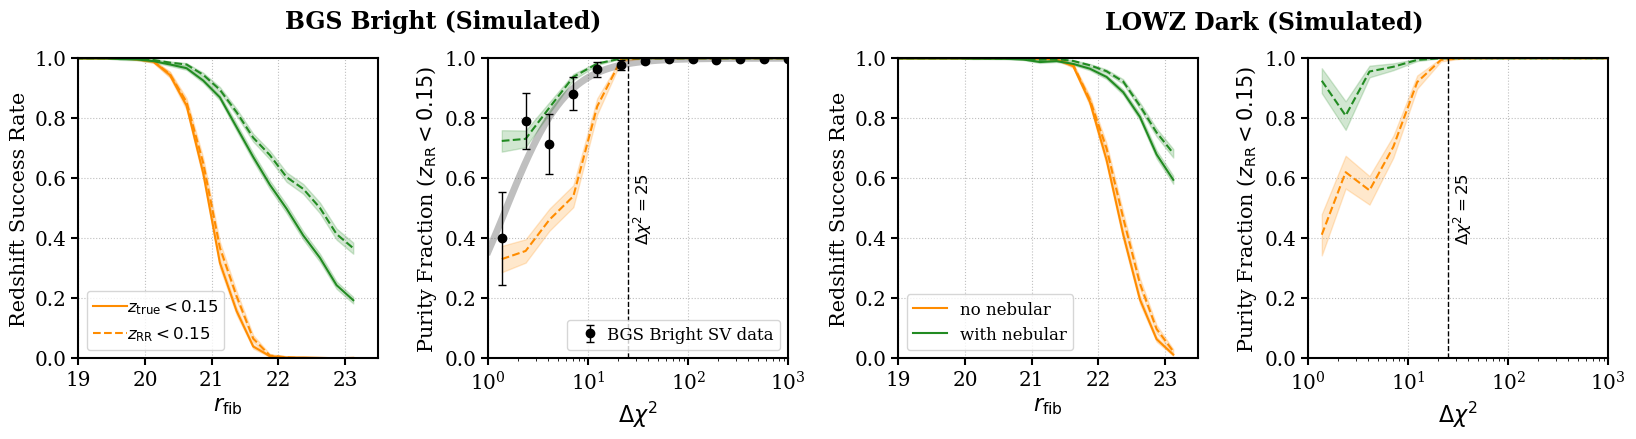

In [71]:
ax = make_subplots(ncol = 4, nrow = 1)

bgs_col = "#648FFF" #DC267F
lowz_col = "#DC267F"

ax[0].text(22.1,1.1,r"BGS Bright (Simulated)",fontsize = 17,weight="bold")

# ax[0].set_title(r"$\Delta\chi^2 > 25$",fontsize = 15)

plt_between(ax[0], rfib_cens, zfail_180_model_25, zfail_err_180_model_25,color="darkorange",alpha=0.2,plot_med=True,label = r"$z_{\rm true} < 0.15$")
plt_between(ax[0], rfib_cens, zfail_obs_180_model_25, zfail_obs_err_180_model_25,color="darkorange",alpha=0.2,plot_med=True,ls=  "--",label = r"$z_{\rm RR} < 0.15$")

plt_between(ax[0], rfib_cens, zfail_emi_180_model_25, zfail_err_emi_180_model_25,color="forestgreen",alpha=0.2,plot_med=True)
plt_between(ax[0], rfib_cens, zfail_obs_emi_180_model_25, zfail_obs_err_emi_180_model_25,color="forestgreen",alpha=0.2,plot_med=True,ls = "--")


# yold = np.array(zfail_obs_180_model_25)
# ynew = yold/(yold + 2*(1-yold))
# ax[0].plot( rfib_cens, ynew,color="aqua",alpha=1,ls = "dotted",lw =2)


plt_between(ax[1], dchi2_cens, np.array(purity_frac_180), np.array(purity_frac_180_err),color="darkorange",alpha=0.2,plot_med=True,ls = "--")
plt_between(ax[1], dchi2_cens, np.array(purity_frac_emi_180), np.array(purity_frac_emi_180_err),color="forestgreen",alpha=0.2,plot_med=True,ls = "--")

# plt_between(ax[1], dchi2_cens, np.array(purity_frac_180_all), np.array(purity_frac_180_err_all),color=bgs_col,alpha=0.2,plot_med=True,ls = "-")
# plt_between(ax[1], dchi2_cens, np.array(purity_frac_900_all), np.array(purity_frac_900_err_all),color=lowz_col,alpha=0.2,plot_med=True,ls = "-")

dchi2_grid = np.linspace(0,4,100)

ax[1].plot(10**dchi2_grid,sigmoid_tanh(dchi2_grid,bgs_pure_params[0] , bgs_pure_params[1]), lw = 5, alpha = 0.25, color = "k" )

ax[1].errorbar(dchi2_bgsb_cens, purity_bgsb_data, yerr = np.array([purity_err_data, purity_err_data]),color = "k",
             ls="none",marker="o",ms=6,elinewidth = 1,capsize = 3,label = r"BGS Bright SV data")


# ax[1].errorbar(dchi2_bgsb_cens, purity_bgsb_all_data, yerr = np.array([purity_err_all_data, purity_err_all_data]),color = "k",
#              ls="none",marker="o",ms=6,elinewidth = 1,capsize = 3,label = r"BGS Bright SV data, $z_{\rm true} < 0.15$")
# ax[1].errorbar(dchi2_bgsb_cens, purity_bgsb_data, yerr = np.array([purity_err_data, purity_err_data]),markeredgecolor = "k",markerfacecolor = "white",
#              ls="none",marker="o",ms=6,elinewidth = 1,ecolor = "k",capsize = 3,label = r"BGS Bright SV data, $z_{\rm RR} < 0.15$")




ax[1].vlines(x = 25, ymin=0,ymax = 1.01,color = "k",ls ="--",lw = 1)
ax[1].text(27,0.4,r"$\Delta\chi^2 = 25$",rotation =90,fontsize = 12,color ="k")

ax[0].legend(frameon=True,fontsize = 12,loc ="lower left",handletextpad=0)
ax[1].legend(frameon=True,fontsize = 12,loc ="lower right",handletextpad=0)


ax[1].grid(ls = ":",color = "grey",alpha = 0.5)
ax[1].set_xscale("log")
ax[1].set_xlim([1,1e3])
ax[1].set_ylim([0,1.])

ax[1].set_xlabel(r"$\Delta\chi^2$",fontsize = 16)

ax[1].set_ylabel(r"Purity Fraction ($z_{\rm RR} < 0.15$)",fontsize = 15)
ax[0].set_ylabel("Redshift Success Rate",fontsize = 15)

###########
###########
###########
###########
    
ax[2].text(22.1,1.1,r"LOWZ Dark (Simulated)",fontsize = 17,weight="bold")

plt_between(ax[2], rfib_cens, zfail_900_model_25, zfail_err_900_model_25,color="darkorange",alpha=0.2,plot_med=True,label = "no nebular")
plt_between(ax[2], rfib_cens, zfail_obs_900_model_25, zfail_obs_err_900_model_25,color="darkorange",alpha=0.2,plot_med=True,ls = "--")


plt_between(ax[2], rfib_cens, zfail_emi_900_model_25, zfail_err_emi_900_model_25,color="forestgreen",alpha=0.2,plot_med=True,label = "with nebular")
plt_between(ax[2], rfib_cens, zfail_obs_emi_900_model_25, zfail_obs_err_emi_900_model_25,color="forestgreen",alpha=0.2,plot_med=True,ls = "--")


# yold = np.array(zfail_obs_emi_180_model_25)
# ynew = yold/(yold + 2*(1-yold))
# ax[2].plot( rfib_cens, ynew,color="aqua",alpha=1,ls = "dotted",lw =2)

# yold = np.array(zfail_obs_emi_900_model_25)
# ynew = yold/(yold + 1.5*(1-yold))
# ax[2].plot( rfib_cens, ynew,color="hotpink",alpha=1,ls = "dotted",lw =2)

ax[2].legend(frameon=False,fontsize = 12,loc ="lower left")

# ax[2].text(19.15,0.33,"BGS Bright-like",color = "blue",weight="bold",fontsize = 12)
# ax[2].text(19.15,0.26,"LOWZ Dark-like",color = "crimson",weight="bold",fontsize = 12)

## in the 3rd plot, we will be plotting the purity rate of only continuum measurements ...

# ax[2].plot(dchi2_cens, purity_frac_180)
# plt_between(ax[2], dchi2_cens, np.array(purity_frac_180), np.array(purity_frac_180_err),color="darkblue",alpha=0.2,plot_med=True,ls = "--")

# # ax[2].plot(dchi2_cens, purity_frac_900)
# plt_between(ax[2], dchi2_cens, np.array(purity_frac_900), np.array(purity_frac_900_err),color="firebrick",alpha=0.2,plot_med=True,ls = "--")



plt_between(ax[3], dchi2_cens, np.array(purity_frac_900), np.array(purity_frac_900_err),color="darkorange",alpha=0.2,plot_med=True,ls = "--")

plt_between(ax[3], dchi2_cens, np.array(purity_frac_emi_900), np.array(purity_frac_emi_900_err),color="forestgreen",alpha=0.2,plot_med=True,ls = "--")


# plt_between(ax[3], dchi2_cens, np.array(purity_frac_emi_180_all), np.array(purity_frac_emi_180_err_all),color=bgs_col,alpha=0.2,plot_med=True,ls = "-")
# plt_between(ax[3], dchi2_cens, np.array(purity_frac_emi_900_all), np.array(purity_frac_emi_900_err_all),color=lowz_col,alpha=0.2,plot_med=True,ls = "-")

# ax[3].errorbar(dchi2_bgsb_cens, purity_bgsb_data, yerr = np.array([purity_err_data, purity_err_data]),color = "k",
#              ls="none",marker="o",ms=6,elinewidth = 1,capsize = 3,label = None)

# ax[3].errorbar(dchi2_bgsb_cens, purity_bgsb_all_data, yerr = np.array([purity_err_all_data, purity_err_all_data]),color = "k",
#              ls="none",marker="o",ms=6,elinewidth = 1,capsize = 3,label = r"BGS Bright SV data, $z_{\rm true} < 0.15$")

# ax[3].errorbar(dchi2_bgsb_cens, purity_bgsb_data, yerr = np.array([purity_err_data, purity_err_data]),markeredgecolor = "k",markerfacecolor = "white",
#              ls="none",marker="o",ms=6,elinewidth = 1,ecolor = "k",capsize = 3,label = r"BGS Bright SV data, $z_{\rm RR} < 0.15$")

# ax[3].plot(10**dchi2_grid,sigmoid_tanh(dchi2_grid,bgs_pure_params[0] , bgs_pure_params[1]), lw = 5, alpha = 0.25, color = "k" )

ax[3].vlines(x = 25, ymin=0,ymax = 1.01,color = "k",ls ="--",lw = 1)
ax[3].text(27,0.4,r"$\Delta\chi^2 = 25$",rotation =90,fontsize = 12,color ="k")

ax[2].legend(frameon=True,fontsize = 12,loc ="lower left")


ax[3].grid(ls = ":",color = "grey",alpha = 0.5)
ax[3].set_xscale("log")
ax[3].set_xlim([1,1e3])
ax[3].set_ylim([0.,1.])

ax[3].set_xlabel(r"$\Delta\chi^2$",fontsize = 16)

ax[3].set_ylabel(r"Purity Fraction ($z_{\rm RR} < 0.15$)",fontsize = 15)
ax[2].set_ylabel("Redshift Success Rate",fontsize = 15)


for axi in [ax[0],ax[2]]:
    axi.set_xlim([19,23.5])
    axi.set_ylim([0,1])
     
    # axi.set_ylim([1e-2,1])
    # axi.set_yscale("log")
    
    axi.set_xticks([19,20,21,22,23])
    axi.set_xlabel(r"$r_{\rm fib}$",fontsize = 16)
    axi.grid(ls = ":",color = "grey",alpha = 0.5)

# plt.savefig("paper_plots/zsucc_simlate_dchi2_spit.pdf",bbox_inches="tight")
plt.show()

### How exactly does the purity and catastrophic fractions depend on the physical properties of spectra ...

In [88]:
pf180_cont, pf180_cont_err = get_purity_fracs(sum_cont_tot[sum_cont_tot["ZRR_180s"] < 0.15], dchi2_bins, dchi2_lab="DELTACHI2_180s", 
                                                        magr_lab="MAG_R", zwarn_lab = "ZWARN_180s", zrr_lab = "ZRR_180s")

pf180_emi, pf180_emi_err = get_purity_fracs(sum_emi_tot[sum_emi_tot["ZRR_180s"] < 0.15], dchi2_bins, dchi2_lab="DELTACHI2_180s", 
                                                        magr_lab="MAG_R", zwarn_lab = "ZWARN_180s", zrr_lab = "ZRR_180s")

pf180_cont_all, pf180_cont_err_all = get_purity_fracs(sum_cont_tot, dchi2_bins, dchi2_lab="DELTACHI2_180s", 
                                                        magr_lab="MAG_R", zwarn_lab = "ZWARN_180s", zrr_lab = "ZRR_180s")

pf180_emi_all, pf180_emi_err_all = get_purity_fracs(sum_emi_tot, dchi2_bins, dchi2_lab="DELTACHI2_180s", 
                                                        magr_lab="MAG_R", zwarn_lab = "ZWARN_180s", zrr_lab = "ZRR_180s")


/tmp/ipykernel_1860542/4175612541.py:21: RuntimeWarning: invalid value encountered in long_scalars
  pure_frac = np.sum(isgood_zred)/len(isgood_zred)


In [73]:
pf180_cont_z1, pf180_cont_err_z1 = get_purity_fracs(sum_cont_tot[(sum_cont_tot["ZRR_180s"] < 0.15) & (sum_cont_tot["logZ"] >= -1)& (sum_cont_tot["tau"] == 3)], dchi2_bins, dchi2_lab="DELTACHI2_180s", 
                                                        magr_lab="MAG_R", zwarn_lab = "ZWARN_180s", zrr_lab = "ZRR_180s")

pf180_cont_z2, pf180_cont_err_z2 = get_purity_fracs(sum_cont_tot[(sum_cont_tot["ZRR_180s"] < 0.15) & (sum_cont_tot["logZ"] < -1)& (sum_cont_tot["tau"] == 3)], dchi2_bins, dchi2_lab="DELTACHI2_180s", 
                                                        magr_lab="MAG_R", zwarn_lab = "ZWARN_180s", zrr_lab = "ZRR_180s")

pf180_cont_a1, pf180_cont_err_a1 = get_purity_fracs(sum_cont_tot[(sum_cont_tot["ZRR_180s"] < 0.15) & (sum_cont_tot["age"] >= 5)& (sum_cont_tot["tau"] == 3)], dchi2_bins, dchi2_lab="DELTACHI2_180s", 
                                                        magr_lab="MAG_R", zwarn_lab = "ZWARN_180s", zrr_lab = "ZRR_180s")

pf180_cont_a2, pf180_cont_err_a2 = get_purity_fracs(sum_cont_tot[(sum_cont_tot["ZRR_180s"] < 0.15) & (sum_cont_tot["age"] < 5)& (sum_cont_tot["tau"] == 3)], dchi2_bins, dchi2_lab="DELTACHI2_180s", 
                                                        magr_lab="MAG_R", zwarn_lab = "ZWARN_180s", zrr_lab = "ZRR_180s")


/tmp/ipykernel_1860542/4175612541.py:21: RuntimeWarning: invalid value encountered in long_scalars
  pure_frac = np.sum(isgood_zred)/len(isgood_zred)


In [84]:
pf180_emi_z1, pf180_emi_err_z1 = get_purity_fracs(sum_emi_tot[(sum_emi_tot["ZRR_180s"] < 0.15) & (sum_emi_tot["logZ"] >= -1) & (sum_emi_tot["tau"] == 2)], dchi2_bins, dchi2_lab="DELTACHI2_180s", 
                                                        magr_lab="MAG_R", zwarn_lab = "ZWARN_180s", zrr_lab = "ZRR_180s")

pf180_emi_z2, pf180_emi_err_z2 = get_purity_fracs(sum_emi_tot[(sum_emi_tot["ZRR_180s"] < 0.15) & (sum_emi_tot["logZ"] < -1)& (sum_emi_tot["tau"] == 2)], dchi2_bins, dchi2_lab="DELTACHI2_180s", 
                                                        magr_lab="MAG_R", zwarn_lab = "ZWARN_180s", zrr_lab = "ZRR_180s")

pf180_emi_a1, pf180_emi_err_a1 = get_purity_fracs(sum_emi_tot[(sum_emi_tot["ZRR_180s"] < 0.15) & (sum_emi_tot["age"] >= 7)& (sum_emi_tot["tau"] == 2)], dchi2_bins, dchi2_lab="DELTACHI2_180s", 
                                                        magr_lab="MAG_R", zwarn_lab = "ZWARN_180s", zrr_lab = "ZRR_180s")

pf180_emi_a3, pf180_emi_err_a3 = get_purity_fracs(sum_emi_tot[(sum_emi_tot["ZRR_180s"] < 0.15) & (sum_emi_tot["age"] < 4)& (sum_emi_tot["tau"] == 2)], dchi2_bins, dchi2_lab="DELTACHI2_180s", 
                                                        magr_lab="MAG_R", zwarn_lab = "ZWARN_180s", zrr_lab = "ZRR_180s")

pf180_emi_a2, pf180_emi_err_a2 = get_purity_fracs(sum_emi_tot[(sum_emi_tot["ZRR_180s"] < 0.15) & (sum_emi_tot["age"] >= 4)& (sum_emi_tot["age"] < 7)& (sum_emi_tot["tau"] == 2)], dchi2_bins, dchi2_lab="DELTACHI2_180s", 
                                                        magr_lab="MAG_R", zwarn_lab = "ZWARN_180s", zrr_lab = "ZRR_180s")

pf180_emi_a4, pf180_emi_err_a4 = get_purity_fracs(sum_emi_tot[(sum_emi_tot["ZRR_180s"] < 0.15) & (sum_emi_tot["age"] == 9)& (sum_emi_tot["tau"] == 2) & (sum_emi_tot["tau"] == 2)], dchi2_bins, dchi2_lab="DELTACHI2_180s", 
                                                        magr_lab="MAG_R", zwarn_lab = "ZWARN_180s", zrr_lab = "ZRR_180s")


/tmp/ipykernel_1860542/4175612541.py:21: RuntimeWarning: invalid value encountered in long_scalars
  pure_frac = np.sum(isgood_zred)/len(isgood_zred)


In [85]:
# plt.figure(figsize =(3,3))
# plt.hist(sum_cont_tot[sum_cont_tot["tau"]==3]["logZ"],bins=20)
# plt.show()

# plt.figure(figsize =(3,3))
# plt.hist(sum_cont_tot[sum_cont_tot["tau"]==3]["age"],bins=20)
# plt.show()


# plt.figure(figsize =(3,3))
# plt.hist(sum_emi_tot[sum_emi_tot["tau"]==2]["logZ"],bins=20)
# plt.show()

# plt.figure(figsize =(3,3))
# plt.hist(sum_emi_tot[sum_emi_tot["tau"]==2]["age"],bins=20)
# plt.show()


## Generating catalog of high SNR desi spectra to mock observe

The reason for doing this as it gives a more realistic spread in the kinds of spectra and also avoids issues with unphysical spectra being made by FSPS as I was observing that

In [68]:
## can I somehow pick out those galaxies???
bgs_vac = Table.read("/pscratch/sd/v/virajvm/catalog/iron_bgs_bright_vac_halpha.fits")

# bgs_vac = read_vac_line_info(bgs_vac, columns = ["HALPHA_EW","HALPHA_EW_IVAR","SNR_B","SNR_R","SNR_Z"],coord_name="TARGET_")

# bgs_vac.write("/pscratch/sd/v/virajvm/catalog/iron_bgs_bright_vac_halpha.fits",overwrite=True)


In [69]:
highemi_bgs = bgs_vac[(bgs_vac["DELTACHI2"] > 5000) & (bgs_vac["SCND_TARGET"] == 0) & (bgs_vac["FIBERMAG_R"] < 18) & (bgs_vac["Z"] < 0.15) & (bgs_vac["Z"] > 0.001) & (bgs_vac["SPECTYPE"]== "GALAXY") & (bgs_vac["ZWARN"] == 0)]

print(len(highemi_bgs))
#chooisng randomly 1500 objects
highemi_bgs = highemi_bgs[:3000]

## get EW measurements
from desi_lowz_funcs import read_vac_line_info

highemi_bgs = read_vac_line_info(highemi_bgs, columns = ["HALPHA_EW","HALPHA_EW_IVAR","SNR_B","SNR_R","SNR_Z"],coord_name="TARGET_")

highemi_bgs = highemi_bgs[ (highemi_bgs["SNR_B"] > 10) & (highemi_bgs["SNR_R"] > 10) & (highemi_bgs["SNR_Z"] > 10) ]
print(len(highemi_bgs))

highemi_bgs = highemi_bgs[:1500]

## save this file
highemi_bgs.write("/pscratch/sd/v/virajvm/catalog/bgs_bright_highemi_catalog_v4.fits",overwrite=True)


6917
The maximum distance in arcsec is =  0.0
2345


/tmp/ipykernel_1125203/52736378.py:3: RuntimeWarning: divide by zero encountered in log10
  plt.hist(np.log10(highemi_bgs["HALPHA_FLUX"]),range=(0,5),bins=20)


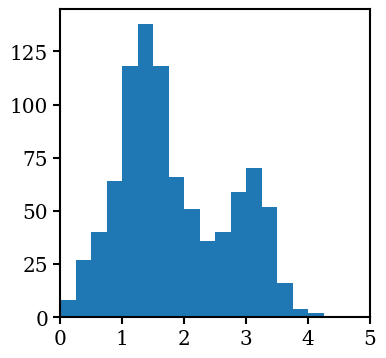

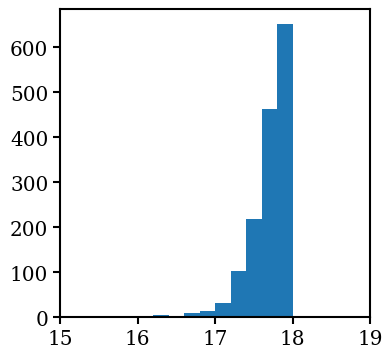

In [70]:
## plotting the histogram for comparison 
plt.figure(figsize = (4,4))
plt.hist(np.log10(highemi_bgs["HALPHA_FLUX"]),range=(0,5),bins=20)
plt.xlim([0,5])

plt.show()
plt.figure(figsize = (4,4))
plt.hist(highemi_bgs["FIBERMAG_R"],range=(15,19),bins=20)
plt.xlim([15,19])
plt.show()

How does Halpha flux relate to Halpha EW and Dchi2?

Is it true that Halpha EW will not change with rfiber mag but Halpha flux will?

/tmp/ipykernel_1125203/4070461765.py:2: RuntimeWarning: divide by zero encountered in log10
  plt.scatter( np.log10(highemi_bgs["HALPHA_EW"]), np.log10(highemi_bgs["HALPHA_FLUX"]))


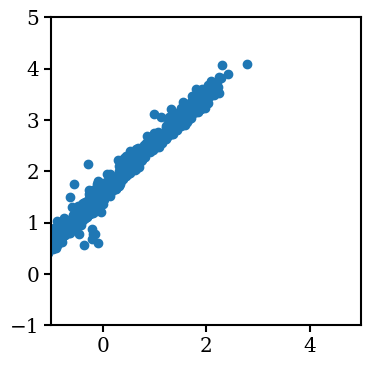

In [71]:
plt.figure(figsize = (4,4))
plt.scatter( np.log10(highemi_bgs["HALPHA_EW"]), np.log10(highemi_bgs["HALPHA_FLUX"]))
plt.xlim([-1,5])
plt.ylim([-1,5])
plt.show()


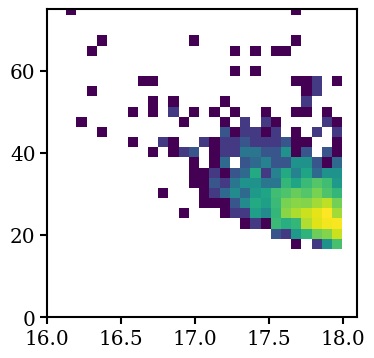

In [82]:
plt.figure(figsize = (4,4))
plt.hist2d( highemi_bgs["FIBERMAG_R"], highemi_bgs["SNR_R"],bins=30,norm=LogNorm())
plt.xlim([16,18.1])
plt.ylim([0,75])
plt.show()

## maybe it correlates more strongly with our "effective fiber mag"


/tmp/ipykernel_1125203/3826345281.py:4: RuntimeWarning: divide by zero encountered in log10
  ax.hist2d( np.log10(highemi_bgs["DELTACHI2"]), np.log10(highemi_bgs["HALPHA_FLUX"]),norm=LogNorm(),range=( (0,6),(-1,6) ),bins=30)


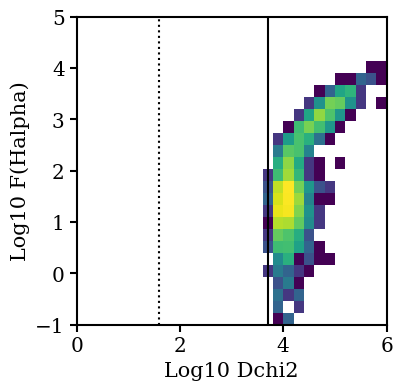

/tmp/ipykernel_1125203/3826345281.py:14: RuntimeWarning: divide by zero encountered in log10
  ax.hist2d( np.log10(highemi_bgs["DELTACHI2"]), np.log10(highemi_bgs["HALPHA_EW"]),norm=LogNorm(),range=( (0,6),(-2,4)),bins=30)


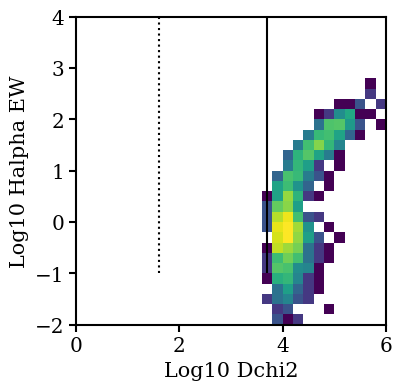

In [67]:
from matplotlib.colors import LogNorm

fig,ax = plt.subplots(1,1,figsize = (4,4))
ax.hist2d( np.log10(highemi_bgs["DELTACHI2"]), np.log10(highemi_bgs["HALPHA_FLUX"]),norm=LogNorm(),range=( (0,6),(-1,6) ),bins=30)
ax.set_xlim([0,6])
ax.set_ylim([-1,5])
ax.vlines(x = np.log10(5e3),ymin=-1,ymax=5,color = "k")
ax.vlines(x = np.log10(40),ymin=-1,ymax=5,color = "k",ls = "dotted")
ax.set_xlabel(r"Log10 Dchi2",fontsize = 15)
ax.set_ylabel(r"Log10 F(Halpha)",fontsize = 15)
plt.show()

fig,ax = plt.subplots(1,1,figsize = (4,4))
ax.hist2d( np.log10(highemi_bgs["DELTACHI2"]), np.log10(highemi_bgs["HALPHA_EW"]),norm=LogNorm(),range=( (0,6),(-2,4)),bins=30)
ax.set_xlim([0,6])
ax.set_ylim([-2,4])
ax.vlines(x = np.log10(5e3),ymin=-1,ymax=5,color = "k")
ax.vlines(x = np.log10(40),ymin=-1,ymax=5,color = "k",ls = "dotted")
ax.set_xlabel(r"Log10 Dchi2",fontsize = 15)
ax.set_ylabel(r"Log10 Halpha EW",fontsize = 15)
plt.show()


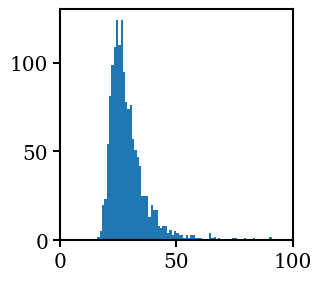

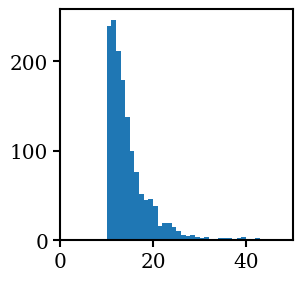

In [72]:
plt.figure(figsize = (3,3))
plt.hist(highemi_bgs["SNR_R"],range=(0,100),bins=100)
plt.xlim([0,100])
plt.show()

plt.figure(figsize = (3,3))
plt.hist(highemi_bgs["SNR_B"],range=(0,100),bins=100)
plt.xlim([0,50])
plt.show()

In [18]:
## read in their spectra ... 

specprod = 'iron'    # Internal name for the EDR
specprod_dir = '/global/cfs/cdirs/desi/spectro/redux/iron'

zpix_cat = Table.read(f'{specprod_dir}/zcatalog/v1/zpix-main-bright.fits', hdu="ZCATALOG")

## match to get tge relevant columns



In [74]:
# zpix_cat["FIBERFLUX_R"]

# when are siii lines intense??

In [75]:
from desi_lowz_funcs import match_c_to_catalog

idx,d2d,_ = match_c_to_catalog(c_cat = highemi_bgs, catalog_cat=zpix_cat)
print(np.max(d2d.arcsec), len(d2d[d2d.arcsec != 0]), len(d2d))

zpix_match = zpix_cat[idx]

zpix_match = zpix_match[d2d.arcsec == 0]
highemi_bgs = highemi_bgs[d2d.arcsec == 0]


0.0 0 1500


In [76]:
## adding the healpix column
highemi_bgs["HEALPIX"]= zpix_match["HEALPIX"]
highemi_bgs["MEAN_PSF_TO_FIBER_SPECFLUX"]= zpix_match["MEAN_PSF_TO_FIBER_SPECFLUX"]
highemi_bgs.write("/pscratch/sd/v/virajvm/catalog/bgs_bright_highemi_catalog_v4.fits",overwrite=True)

#### test other properties of the catalog.
ratio of Halpha flux / Hbeta flux. What about EW?

/tmp/ipykernel_1218221/1966076160.py:2: RuntimeWarning: divide by zero encountered in true_divide
  plt.hist(highemi_bgs["HALPHA_FLUX"]/highemi_bgs["HBETA_FLUX"],range=(0.1,20),bins=20,density=True)
/tmp/ipykernel_1218221/1966076160.py:2: RuntimeWarning: invalid value encountered in true_divide
  plt.hist(highemi_bgs["HALPHA_FLUX"]/highemi_bgs["HBETA_FLUX"],range=(0.1,20),bins=20,density=True)


<function matplotlib.pyplot.show(close=None, block=None)>

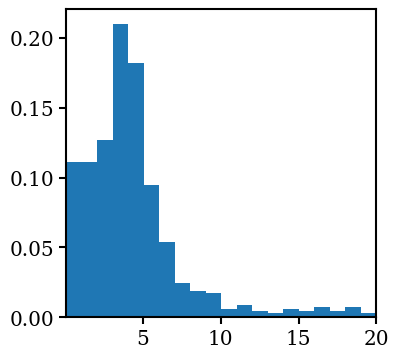

In [362]:
plt.figure(figsize = (4,4))
plt.hist(highemi_bgs["HALPHA_FLUX"]/highemi_bgs["HBETA_FLUX"],range=(0.1,20),bins=20,density=True)
plt.xlim([0.1,20])
plt.show


In [245]:
# hahb_frac = highemi_bgs["HALPHA_FLUX"]/highemi_bgs["HBETA_FLUX"]

# highemi_bgs[ hahb_frac < 4]

In [236]:
# tgid_interest = 39628419155101714
# temp_data = Table.read("/pscratch/sd/v/virajvm/bgs_bright_highemi_spectra/spectra_%d.fits"%tgid_interest)
# wave_i, flux_i = np.array(temp_data["wave"]), np.array(temp_data["flux"])
# wave_i

In [67]:
# import DESI related modules - 
from desimodel.footprint import radec2pix      # For getting healpix values
import desispec.io                             # Input/Output functions related to DESI spectra
from desispec import coaddition                # Functions related to coadding the spectra
from astropy.convolution import convolve, Gaussian1DKernel
from astropy.table import QTable

def get_spectra(tgid_interest,hpx,plot=True,save=False,save_path=None):
    '''
    Function that gets the spectra for the single object.
    
    The following need to be run before this function
    
    # import DESI related modules - 
    from desimodel.footprint import radec2pix      # For getting healpix values
    import desispec.io                             # Input/Output functions related to DESI spectra
    from desispec import coaddition                # Functions related to coadding the spectra
    from astropy.convolution import convolve, Gaussian1DKernel

    specprod = 'iron'    # Internal name for the EDR
    specprod_dir = '/global/cfs/cdirs/desi/spectro/redux/iron/'

    zpix_cat = Table.read(f'{specprod_dir}/zcatalog/zall-pix-{specprod}.fits', hdu="ZCATALOG")  
    healpix_dir = f'{specprod_dir}/healpix'
    
    '''
    # Let us explore the target directory
    # Note that the target directory is different for the different spectra.
    # We first explore the primary spectra and look at the other spectra later.
    healpix_dir = "/global/cfs/cdirs/desi/spectro/redux/iron/healpix"
    survey = "main"
    program = "bright"
    
    tgt_dir = f'{healpix_dir}/{survey}/{program}/{hpx//100}/{hpx}'
    
    coadd_filename = f'coadd-{survey}-{program}-{hpx}.fits'    
    
    h_coadd = fits.open(f'{tgt_dir}/{coadd_filename}')
    
    coadd_obj = desispec.io.read_spectra(f'{tgt_dir}/{coadd_filename}')
    coadd_tgts = coadd_obj.target_ids().data
    #coadd the spec now 
    
    # Selecting the particular spectra of the targetid
    row = (coadd_tgts == tgid_interest)
    coadd_spec = coadd_obj[row]
    
    spec_combined = coaddition.coadd_cameras(coadd_spec)    
    
    ## remove teh nan fluxes
    
    fluxs = spec_combined.flux['brz'][0]
    fluxs_err = 1/np.sqrt(spec_combined.ivar['brz'][0])
    gmask = (fluxs > fluxs_err)
    # gmask = np.ones_like(fluxs).astype(bool)
    
    # masking the anomalous low snr spectra??
                                      
    if plot==True:
        plt.figure(figsize = (7, 7))
        # Plot the combined spectrum in maroon
        plt.plot(spec_combined.wave['brz'][gmask], spec_combined.flux['brz'][0][gmask], color = 'grey', alpha = 0.5)
        plt.plot(spec_combined.wave['brz'][gmask], 1/np.sqrt(spec_combined.ivar['brz'][0][gmask]),color = "darkorange",alpha = 1)
        # Over-plotting smoothed spectra 
        plt.plot(spec_combined.wave['brz'][gmask], convolve(spec_combined.flux['brz'][0][gmask], Gaussian1DKernel(1)) , color = 'k', lw = 1.25)

        plt.xlim([6563 - 500, 6563 + 500])
        waves= spec_combined.wave['brz']
        
        wmask = (waves > 6563 - 200) & (waves < 6563 + 300)
#                 
        # plt.ylim([-0.2,20])
        plt.yscale("log")
        
        plt.xlabel('Rest-Frame Wavelength [$\AA$]',fontsize = 22)
        plt.ylabel('$F_{\lambda}$ [$10^{-17} erg\ s^{-1}\ cm^{-2}\ \AA^{-1}$]',fontsize = 22)
        plt.xticks(fontsize = 15)
        plt.yticks(fontsize = 12)
       
        if save:
            plt.savefig(save_path + "plot_%d.png"%tgid_interest)
            plt.close()
        else:
            plt.show()
            
      
    wave_f = spec_combined.wave['brz'][gmask]
    flux_f = spec_combined.flux['brz'][0][gmask]
    ## interpolate spectra to same wavelength grid as DESI 
    wave_i = np.arange(np.min(wave_f), np.max(wave_f), 0.2)
    interp_flux = interp1d(wave_f, flux_f) 
    flux_i = interp_flux(wave_i)
    
    if save:
        spec_tab = QTable([wave_i, flux_i],names=('wave', 'flux') )
        spec_tab.write(save_path + "spectra_%d.fits"%tgid_interest,overwrite=True)

    return wave_i, flux_i 



In [68]:
speclite.filters.load_filters('decamDR1noatm-*')

  0%|          | 0/10 [00:00<?, ?it/s]

INFO:spectra.py:291:read_spectra: iotime 0.173 sec to read coadd-main-bright-16733.fits at 2024-11-29T22:58:28.337752


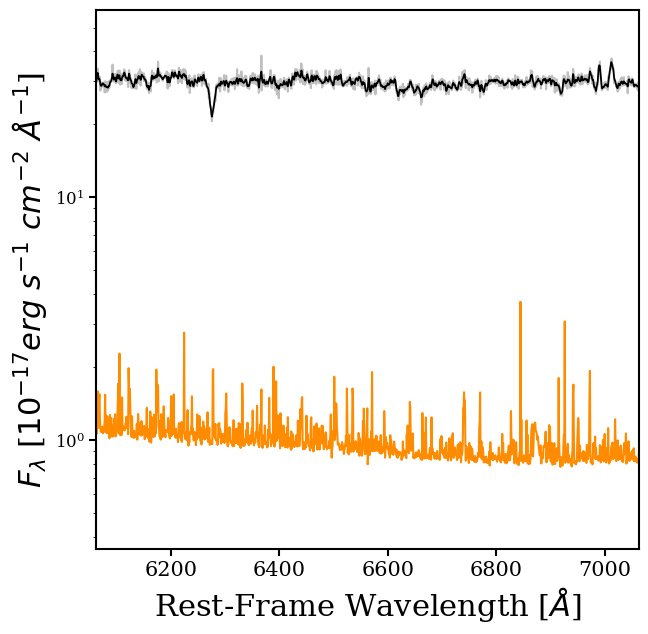

 10%|█         | 1/10 [00:00<00:04,  1.98it/s]

INFO:spectra.py:291:read_spectra: iotime 0.426 sec to read coadd-main-bright-16833.fits at 2024-11-29T22:58:29.097078


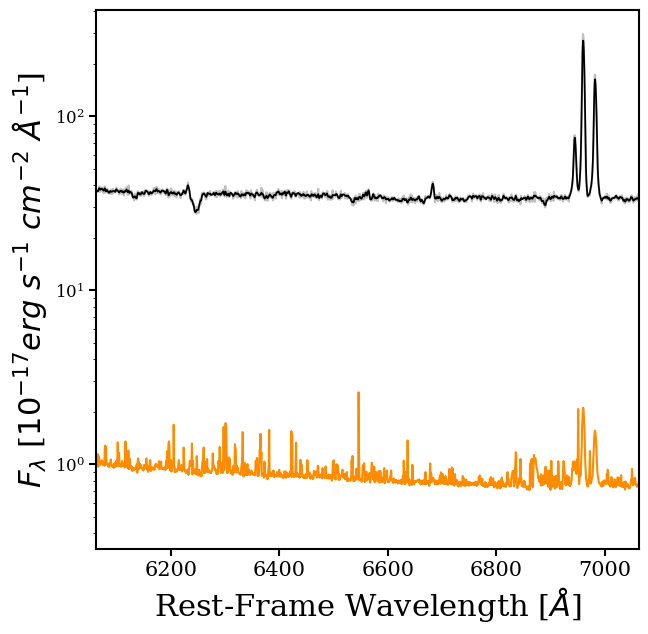

 20%|██        | 2/10 [00:01<00:06,  1.32it/s]

INFO:spectra.py:291:read_spectra: iotime 0.770 sec to read coadd-main-bright-17410.fits at 2024-11-29T22:58:30.417803


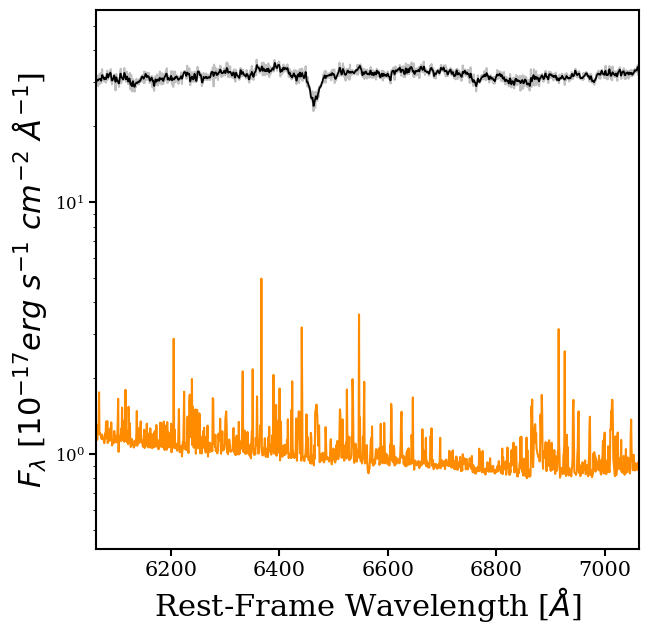

 30%|███       | 3/10 [00:02<00:06,  1.00it/s]

INFO:spectra.py:291:read_spectra: iotime 0.307 sec to read coadd-main-bright-36253.fits at 2024-11-29T22:58:31.198810


/tmp/ipykernel_2298949/4282032103.py:53: RuntimeWarning: divide by zero encountered in true_divide
  fluxs_err = 1/np.sqrt(spec_combined.ivar['brz'][0])


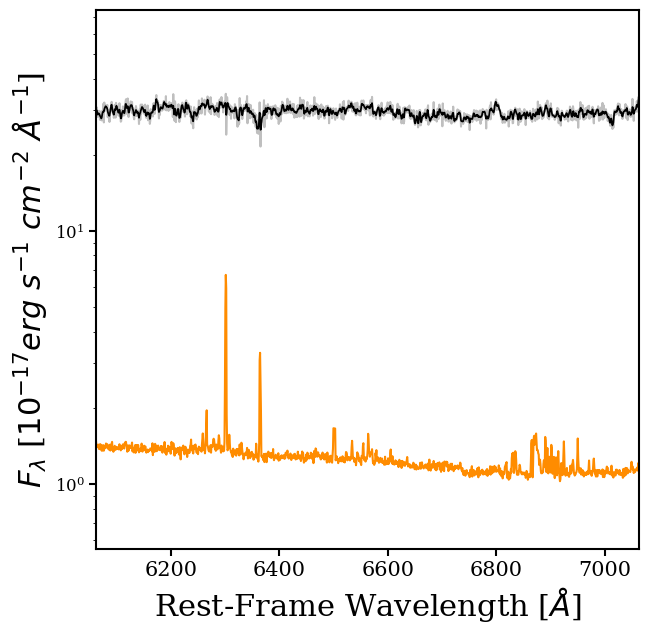

 40%|████      | 4/10 [00:03<00:05,  1.13it/s]

INFO:spectra.py:291:read_spectra: iotime 0.885 sec to read coadd-main-bright-36210.fits at 2024-11-29T22:58:32.545432


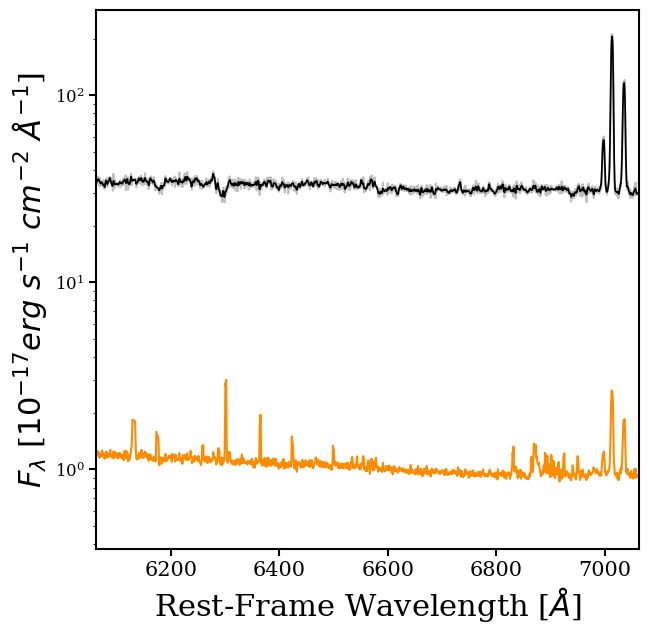

 50%|█████     | 5/10 [00:05<00:05,  1.18s/it]

INFO:spectra.py:291:read_spectra: iotime 0.889 sec to read coadd-main-bright-17416.fits at 2024-11-29T22:58:34.234255


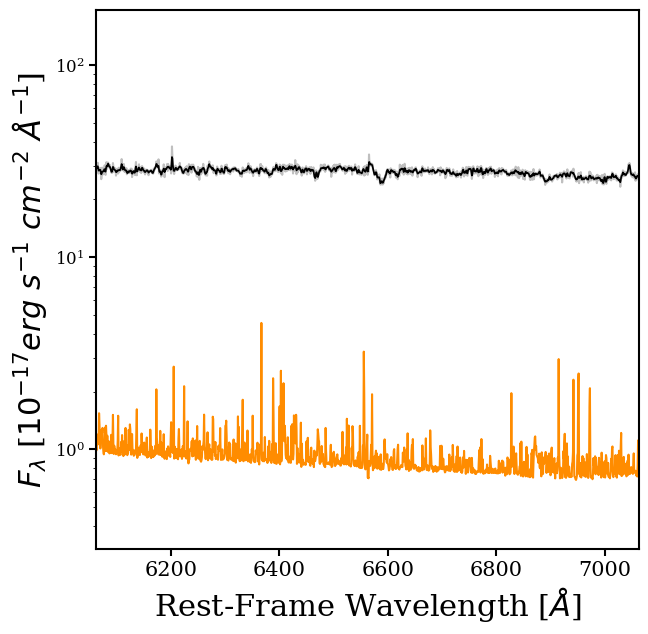

 60%|██████    | 6/10 [00:06<00:05,  1.27s/it]

INFO:spectra.py:291:read_spectra: iotime 0.981 sec to read coadd-main-bright-36548.fits at 2024-11-29T22:58:35.782729


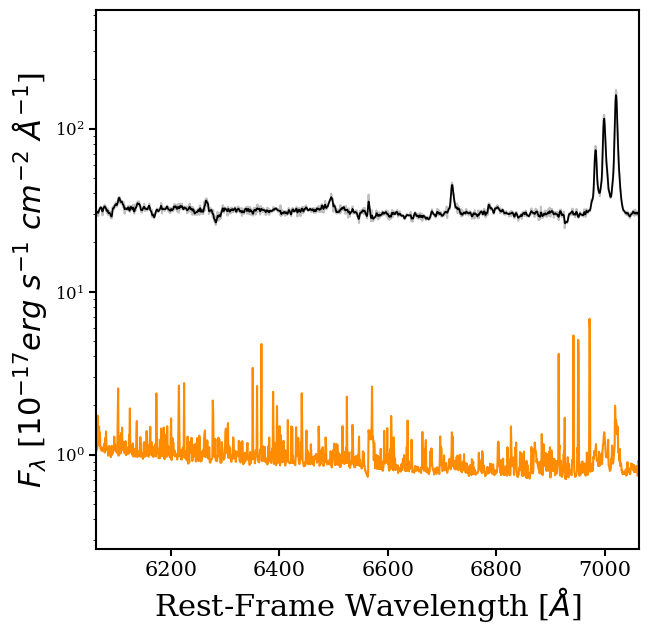

 70%|███████   | 7/10 [00:08<00:04,  1.36s/it]

INFO:spectra.py:291:read_spectra: iotime 0.576 sec to read coadd-main-bright-36280.fits at 2024-11-29T22:58:36.949488


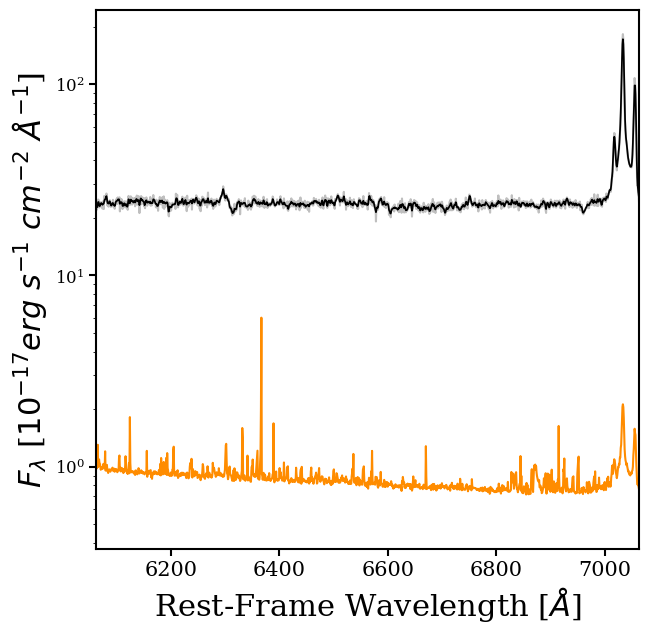

 80%|████████  | 8/10 [00:09<00:02,  1.29s/it]

INFO:spectra.py:291:read_spectra: iotime 1.373 sec to read coadd-main-bright-36212.fits at 2024-11-29T22:58:38.849269


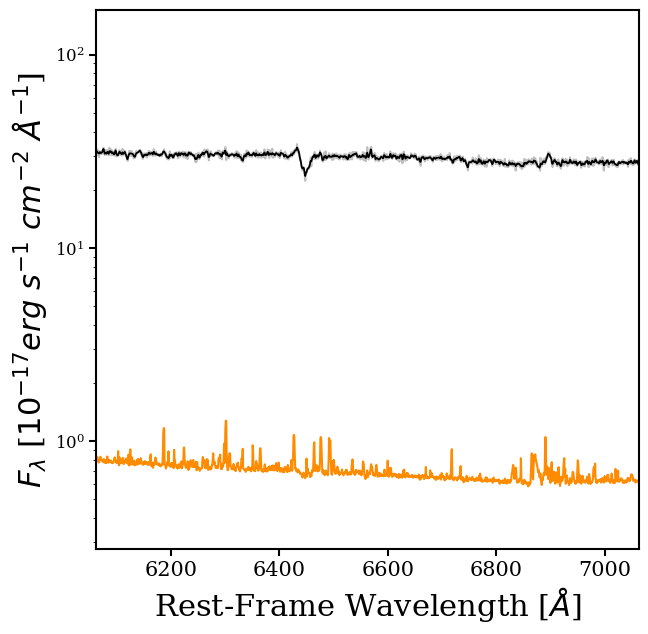

 90%|█████████ | 9/10 [00:11<00:01,  1.68s/it]

INFO:spectra.py:291:read_spectra: iotime 0.726 sec to read coadd-main-bright-36282.fits at 2024-11-29T22:58:40.779952


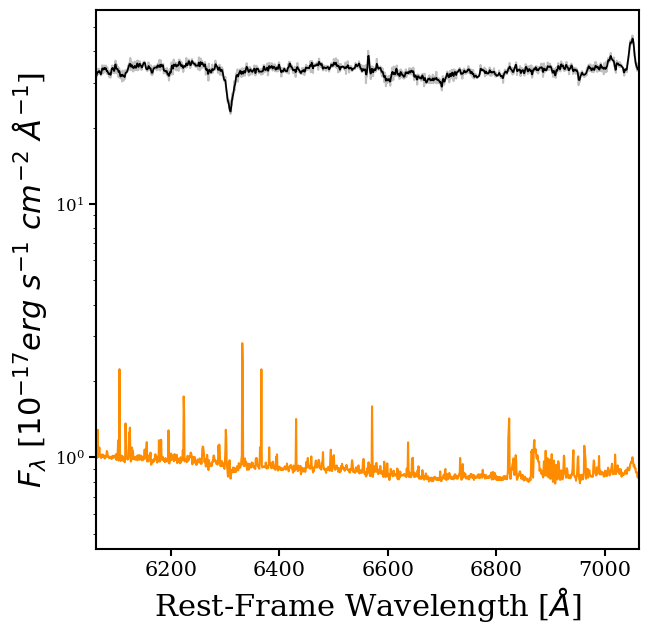

100%|██████████| 10/10 [00:13<00:00,  1.31s/it]


In [69]:
all_highemi_rfibs = []
all_highemi_rfibs_noatm = []
    
decam1_noatm = speclite.filters.load_filters('decamDR1noatm-*')

for i in trange(10):
# for i in trange(len(highemi_bgs)):

    wave_i, flux_i = get_spectra(highemi_bgs["TARGETID"][i],highemi_bgs["HEALPIX"][i],plot=True,save=False,save_path="/pscratch/sd/v/virajvm/bgs_bright_highemi_spectra/")
    
    ## compute the magnitude of this and see if it checks out ...
    wlen = np.concatenate([ [3200], wave_i, [11000] ])  * u.Angstrom
    flux = np.concatenate([ [0], flux_i, [0] ]) * highemi_bgs["MEAN_PSF_TO_FIBER_SPECFLUX"][i] * 1e-17 * u.erg / (u.cm**2 * u.s * u.Angstrom)

    mags_decam = decam.get_ab_magnitudes(flux, wlen)
    mags_decam1_noatm = decam1_noatm.get_ab_magnitudes(flux, wlen)
    
    mags_decam_r = mags_decam["decam2014-r"]
    mags_decam_r_noatm = mags_decam1_noatm["decamDR1noatm-r"]
    
    all_highemi_rfibs.append(mags_decam_r)
    all_highemi_rfibs_noatm.append(mags_decam_r_noatm)
    


In [34]:
highemi_bgs[:5]

TARGETID,TARGET_RA,TARGET_DEC,SCND_TARGET,Z,ZWARN,DELTACHI2,SPECTYPE,MAG_R,MAG_G,FIBERFLUX_R,HALPHA_FLUX,HALPHA_FLUX_IVAR,HALPHA_BOXFLUX,HBETA_FLUX,HBETA_BOXFLUX,TSNR2_BGS,TSNR2_LRG,FIBERMAG_R,HEALPIX,MEAN_PSF_TO_FIBER_SPECFLUX
int64,float64,float64,int64,float64,int64,float64,bytes6,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int32,float32
39627345547503408,20.504261677895173,-18.45484593178776,0,0.06486440130268431,0,51808.0102378279,GALAXY,16.166159,16.995121,84.5973,50.490997,0.16757558,39.710407,11.070404,9.979733,2107.9219,24.80407,17.681608,16733,0.72155344
39627345568465709,21.599178602582455,-18.52956212607292,0,0.03276820074949801,0,836486.5739650726,GALAXY,15.964266,16.25547,102.570885,6929.0615,0.007054157,7383.52,2131.9824,2180.6309,2195.2476,25.676039,17.472439,17410,0.75410277
39627351142696473,11.352274662937607,-18.273056080942517,0,0.06031548648967864,0,113936.78278255463,GALAXY,14.42223,14.970756,100.295456,1362.2124,0.049202446,1367.4623,263.51385,267.83206,2371.0679,26.850834,17.496796,16833,0.7269684
39627351302087368,21.51996430319957,-18.315753536142168,79164837199872,0.09680730833625885,0,12585.833075974137,GALAXY,15.419962,16.398972,66.422516,71.74531,0.07313581,89.677864,10.824792,12.482406,1902.3745,22.32653,17.944212,17410,0.75379294
39627351826367378,54.15983987744072,-18.353408324088768,79165105635328,0.0791934733091204,0,13866.411068055779,GALAXY,15.692502,16.36596,69.38769,303.61337,0.04050295,312.01437,75.346,80.50994,1923.6793,23.570988,17.896793,36253,0.7263107


Testing how good and accurate our simulation pipeline actually is!!

In [29]:
## loading the redrock fits

highemi_rr = Table.read("/pscratch/sd/v/virajvm/spec_reobs_literal_180s_output.fits")
highemi_rr_nos = Table.read("/pscratch/sd/v/virajvm/spec_nosmooth_reobs_literal_180s_output.fits")

highemi_bgs = Table.read("/pscratch/sd/v/virajvm/catalog/bgs_bright_highemi_catalog_v3.fits")
print(len(highemi_rr))
print(len(highemi_rr_nos))

print(len(highemi_bgs))

1192
1192
1192


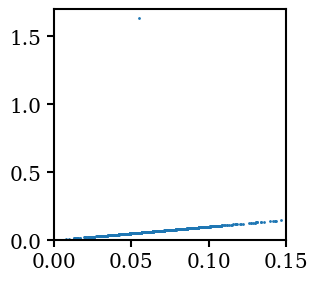

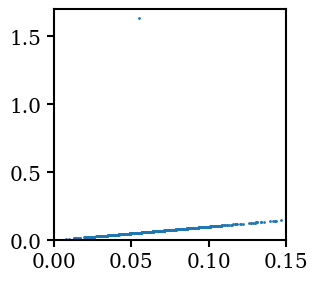

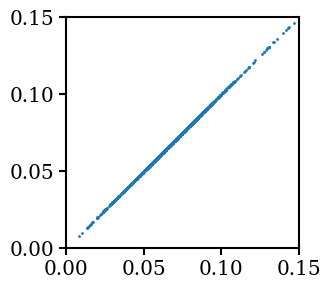

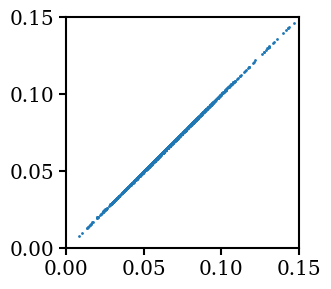

In [31]:
#comparing to actual data
plt.figure(figsize = (3,3))
plt.scatter(highemi_bgs["Z"], highemi_rr["Z"], s=1)
plt.xlim([0,0.15])
plt.ylim([0,1.7])
plt.show()


plt.figure(figsize = (3,3))
plt.scatter(highemi_bgs["Z"], highemi_rr_nos["Z"], s=1)
plt.xlim([0,0.15])
plt.ylim([0,1.7])
plt.show()

plt.figure(figsize = (3,3))
plt.scatter(highemi_bgs["Z"], highemi_rr["Z"], s=1)
plt.xlim([0,0.15])
plt.ylim([0,0.15])
plt.show()

plt.figure(figsize = (3,3))
plt.scatter(highemi_bgs["Z"], highemi_rr_nos["Z"], s=1)
plt.xlim([0,0.15])
plt.ylim([0,0.15])
plt.show()

In [38]:
highemi_bgs[highemi_rr["Z"] > 1]

TARGETID,TARGET_RA,TARGET_DEC,SCND_TARGET,Z,ZWARN,DELTACHI2,SPECTYPE,MAG_R,MAG_G,FIBERFLUX_R,HALPHA_FLUX,HALPHA_FLUX_IVAR,HALPHA_BOXFLUX,HBETA_FLUX,HBETA_BOXFLUX,TSNR2_BGS,TSNR2_LRG,FIBERMAG_R,HALPHA_EW,HALPHA_EW_IVAR,SNR_B,SNR_R,SNR_Z,HEALPIX,MEAN_PSF_TO_FIBER_SPECFLUX
int64,float64,float64,int64,float64,int64,float64,bytes6,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int32,float32
39627672598348225,152.44520753735577,-4.789415932115335,79164837199872,0.0553393536900942,0,16569.390622574836,GALAXY,15.682052,16.497124,100.58993,0.0,0.0,35.29265,0.0,-15.404928,1665.7649,24.350082,17.493614,0.0,0.0,18.912935,39.038525,26.909586,26858,0.74420875


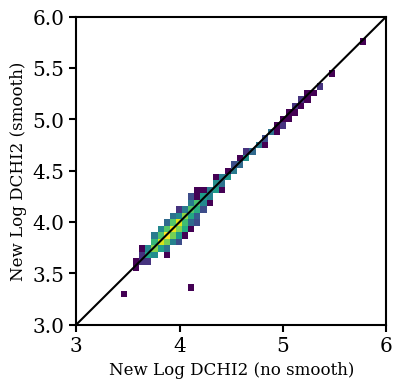

In [34]:
plt.figure(figsize = (4,4))
# plt.hist2d( np.log10(highemi_bgs[highemi_bgs["SNR_R"] > 10]["DELTACHI2"]), np.log10(highemi_rr[highemi_bgs["SNR_R"] > 10]["DELTACHI2"]),s=1)
plt.hist2d( np.log10(highemi_rr_nos["DELTACHI2"]), np.log10(highemi_rr["DELTACHI2"]),bins=40,norm=LogNorm())

plt.plot([3,6],[3,6],color = "k")
plt.xlabel("New Log DCHI2 (no smooth)",fontsize = 12)
plt.ylabel("New Log DCHI2 (smooth)",fontsize = 12)
plt.xlim([3,6])
plt.ylim([3,6])
plt.show()

## either the difference is due to we are adding more noise to the already noisy spectra (not really truth)
## or some difference in the exposure times??

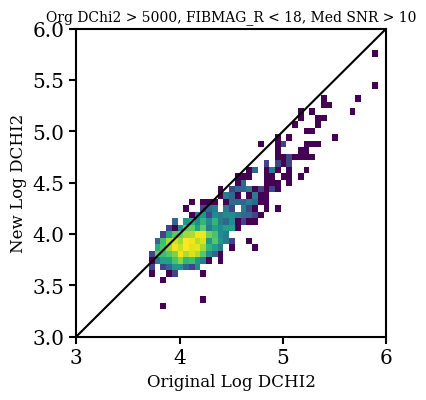

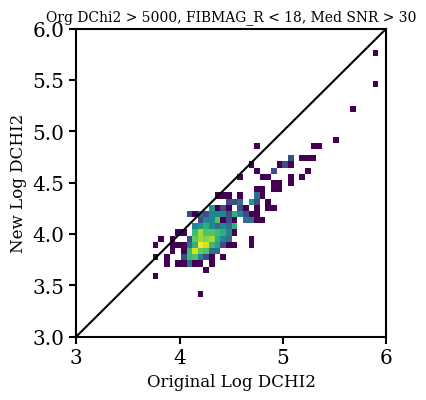

In [52]:

# (bgs_vac["DELTACHI2"] > 5000) & (bgs_vac["FIBERMAG_R"] < 18) & (bgs_vac["Z"] < 0.15) & (bgs_vac["Z"] > 0.001) & (bgs_vac["SPECTYPE"]== "GALAXY") & (bgs_vac["ZWARN"] == 0)


plt.figure(figsize = (4,4))
plt.title("Org DChi2 > 5000, FIBMAG_R < 18, Med SNR > 10",fontsize = 10)
plt.hist2d( np.log10(highemi_bgs["DELTACHI2"]), np.log10(highemi_rr["DELTACHI2"]),bins=40,norm=LogNorm())

plt.plot([3,6],[3,6],color = "k")
plt.xlabel("Original Log DCHI2",fontsize = 12)
plt.ylabel("New Log DCHI2",fontsize = 12)
plt.xlim([3,6])
plt.ylim([3,6])
plt.show()


plt.figure(figsize = (4,4))
plt.title("Org DChi2 > 5000, FIBMAG_R < 18, Med SNR > 30",fontsize = 10)
plt.hist2d( np.log10(highemi_bgs[highemi_bgs["SNR_R"] > 30]["DELTACHI2"]), np.log10(highemi_rr[highemi_bgs["SNR_R"] > 30]["DELTACHI2"]),bins=40,norm=LogNorm())
plt.plot([3,6],[3,6],color = "k")
plt.xlabel("Original Log DCHI2",fontsize = 12)
plt.ylabel("New Log DCHI2",fontsize = 12)
plt.xlim([3,6])
plt.ylim([3,6])
plt.show()

## either the difference is due to we are adding more noise to the already noisy spectra (not really truth)
## or some difference in the exposure times??
## I think I am going to accept this difference as is?? And maybe return to this another day
## I am going to consider this experiment as mildy successful!

/tmp/ipykernel_1125203/4046105824.py:2: RuntimeWarning: divide by zero encountered in log10
  ax.hist2d( np.log10(highemi_bgs["DELTACHI2"]), np.log10(highemi_bgs["HALPHA_FLUX"]),norm=LogNorm(),range=( (0,6),(-1,6) ),bins=30)


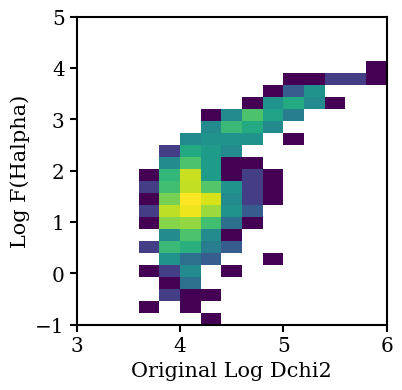

/tmp/ipykernel_1125203/4046105824.py:13: RuntimeWarning: divide by zero encountered in log10
  ax.hist2d( np.log10(highemi_rr["DELTACHI2"]), np.log10(highemi_bgs["HALPHA_FLUX"]),norm=LogNorm(),range=( (0,6),(-1,6) ),bins=30)


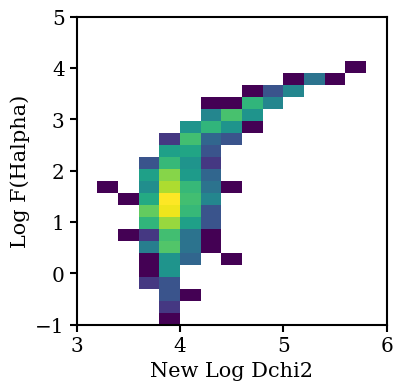

In [54]:


fig,ax = plt.subplots(1,1,figsize = (4,4))
ax.hist2d( np.log10(highemi_bgs["DELTACHI2"]), np.log10(highemi_bgs["HALPHA_FLUX"]),norm=LogNorm(),range=( (0,6),(-1,6) ),bins=30)
ax.set_xlim([3,6])
ax.set_ylim([-1,5])
# ax.vlines(x = np.log10(5e3),ymin=-1,ymax=5,color = "k")
# ax.vlines(x = np.log10(40),ymin=-1,ymax=5,color = "k",ls = "dotted")
ax.set_xlabel(r"Original Log Dchi2",fontsize = 15)
ax.set_ylabel(r"Log F(Halpha)",fontsize = 15)
plt.show()


fig,ax = plt.subplots(1,1,figsize = (4,4))
ax.hist2d( np.log10(highemi_rr["DELTACHI2"]), np.log10(highemi_bgs["HALPHA_FLUX"]),norm=LogNorm(),range=( (0,6),(-1,6) ),bins=30)
ax.set_xlim([3,6])
ax.set_ylim([-1,5])
# ax.vlines(x = np.log10(5e3),ymin=-1,ymax=5,color = "k")
# ax.vlines(x = np.log10(40),ymin=-1,ymax=5,color = "k",ls = "dotted")
ax.set_xlabel(r"New Log Dchi2",fontsize = 15)
ax.set_ylabel(r"Log F(Halpha)",fontsize = 15)
plt.show()

Similar to BGS Bright, test out LOWZ Dark objects 

In [29]:
lowz_vac = Table.read("/pscratch/sd/v/virajvm/catalog/iron_lowz_dark_vac_halpha.fits")

# lowz_vac_f = lowz_vac[(lowz_vac["FIBERMAG_R"] < 20.5)]

lowz_vac = read_vac_line_info(lowz_vac, columns = ["HALPHA_EW","HALPHA_EW_IVAR","SNR_B","SNR_R","SNR_Z"],coord_name="TARGET_")

lowz_vac.write("/pscratch/sd/v/virajvm/catalog/iron_lowz_dark_vac_halpha.fits",overwrite=True)


The maximum distance in arcsec is =  0.0


In [16]:
lowz_vac_f = lowz_vac[(lowz_vac["FIBERMAG_R"] < 20.5)]

lowz_vac_f = read_vac_line_info(lowz_vac_f, columns = ["HALPHA_EW","HALPHA_EW_IVAR","SNR_B","SNR_R","SNR_Z"],coord_name="TARGET_")

lowz_vac_f.write("/pscratch/sd/v/virajvm/catalog/iron_lowz_dark_vac_halpha_Brfib_205.fits",overwrite=True)


The maximum distance in arcsec is =  0.0


In [19]:
from desi_lowz_funcs import match_c_to_catalog

idx,d2d,_ = match_c_to_catalog(c_cat = lowz_vac_f, catalog_cat=zpix_cat)
print(np.max(d2d.arcsec), len(d2d[d2d.arcsec != 0]), len(d2d))

zpix_match = zpix_cat[idx]

zpix_match = zpix_match[d2d.arcsec == 0]
lowz_vac_f = lowz_vac_f[d2d.arcsec == 0]


9240.075000308007 43 113


In [20]:
## adding the healpix column
lowz_vac_f["HEALPIX"]= zpix_match["HEALPIX"]
lowz_vac_f["MEAN_PSF_TO_FIBER_SPECFLUX"]= zpix_match["MEAN_PSF_TO_FIBER_SPECFLUX"]
lowz_vac_f.write("/pscratch/sd/v/virajvm/catalog/iron_lowz_dark_vac_halpha_Brfib_205.fits",overwrite=True)

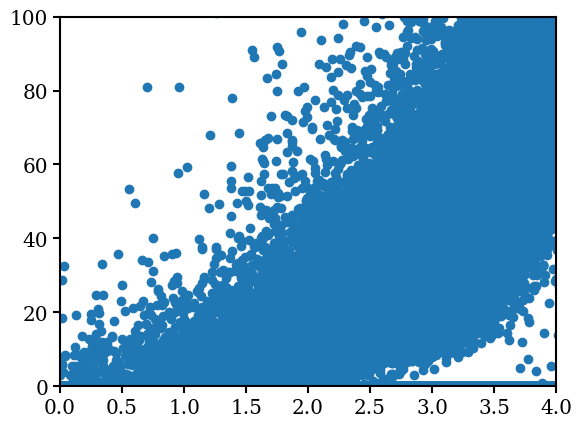

In [32]:
plt.scatter(np.log10(lowz_vac["DELTACHI2"]), lowz_vac["HALPHA_EW"])
plt.ylim([0,100])
plt.xlim([0,4])
plt.show()

Below is code for testing the recovery of fiber mag from the actual observed spectra

In [272]:

# zpix_star = zpix_cat[(zpix_cat["SPECTYPE"]== "STAR") & (zpix_cat["DELTACHI2"] > 1000)]

# mock_rmag = []
# real_rmag = []
# for i in trange(30):
#     print( highemi_bgs_f["TARGETID"][i] )
#     wave_i, flux_i = get_spectra(zpix_star["TARGETID"][i],zpix_star["HEALPIX"][i],plot=False,save=False,save_path=None)
    
#     ## compute the magnitude of this and see if it checks out ...
#     wlen = np.concatenate([ [3200], wave_i, [11000] ])  * u.Angstrom
#     flux = np.concatenate([ [0], flux_i, [0] ]) * zpix_star["MEAN_PSF_TO_FIBER_SPECFLUX"][i] * 1e-17 * u.erg / (u.cm**2 * u.s * u.Angstrom)

#     mags_decam = decam.get_ab_magnitudes(flux, wlen)

#     mags_decam_r = mags_decam["decam2014-r"]

#     mock_rmag.append(mags_decam_r)
#     real_rmag.append( 22.5 - 2.5*np.log10(zpix_star["FIBERFLUX_R"][i]) )
    
    
# plt.figure(figsize = (4,4))
# plt.scatter(mock_rmag, real_rmag)
# plt.xlim([16.8,19])
# plt.ylim([16.8,19])
# plt.plot([16,20],[16,20],color = "k")
# plt.plot([16,20],[16.5,20.5],color = "k",ls ="dotted")
# plt.xlabel("DECAM r mag (convolved with spectra)",fontsize = 13)
# plt.ylabel("r fiber magnitude",fontsize = 13)
# plt.show()

# ## stars agree quite well!!

Updating the targetids in the files so they are unique. This is actually not needed :) the fits file even if they have same names as the original files

In [235]:

# for i in trange(100):
#     # Open the FITS file in update mode
#     filename = "/pscratch/sd/v/virajvm/fsps_dwarf_spectra/spec_reobs_180s_%d.fits"%i
#     with fits.open(filename, mode='update') as hdul:
#         # Access the desired HDU (e.g., HDU 1)
#         hdu = hdul[1]

#         # Access the table data
#         data = hdu.data

#         # Modify a specific column (e.g., 'COLUMN_NAME')
#         # Assuming you want to double the values in 'COLUMN_NAME'
#         data['TARGETID'] = np.arange(len(data)) + 1500*i

#         # Save changes (automatic in 'update' mode)
#         hdul.flush()
        
#     ## DOING FOR 900s files now
#     filename = "/pscratch/sd/v/virajvm/fsps_dwarf_spectra/spec_reobs_900s_%d.fits"%i
#     with fits.open(filename, mode='update') as hdul:
#         # Access the desired HDU (e.g., HDU 1)
#         hdu = hdul[1]

#         # Access the table data
#         data = hdu.data

#         # Modify a specific column (e.g., 'COLUMN_NAME')
#         # Assuming you want to double the values in 'COLUMN_NAME'
#         data['TARGETID'] = np.arange(len(data)) + 1500000*i

#         # Save changes (automatic in 'update' mode)
#         hdul.flush()



Write an ascii file with all the file names 

In [264]:
def write_list_ascii(min_num, max_num, index_name):

    output_file = "/pscratch/sd/v/virajvm/list_coadds_%d.ascii"%index_name

    # List of file names
    file_names = []
    for i in range(min_num,max_num):
        for ti in ["180s","900s"]:
            file_names.append("/pscratch/sd/v/virajvm/fsps_dwarf_spectra/" + "spec_reobs_%s_%d.fits"%(ti, i) )

    # Write to the file
    with open(output_file, "w") as f:
        for name in file_names:
            f.write(name + "\n")  # Add each file name followed by a newline
            
    return

# write_list_ascii(0,225,0)
# write_list_ascii(210,300,1)
# write_list_ascii(295,300,2)
# write_list_ascii(75,100,3)


print(len(rerun_files))
output_file = "/pscratch/sd/v/virajvm/list_coadds_4.ascii"
with open(output_file, "w") as f:
    for name in rerun_files:
        f.write(name + "\n")  # Add each file name followed by a newline

203


In [261]:
# for i in trange(300):
#     for ti in ["180s","900s"]:
#         temp = "/pscratch/sd/v/virajvm/fsps_dwarf_spectra/" + "spec_reobs_%s_%d.fits"%(ti, i)
        
#         if len(fits.open(temp)["SCORES"].data) != 1500:
#             print(temp)


Constructing the final catalogs using the mock reobs data

We do not need the h5 files as they contains more info than I need

In [ ]:
# import h5py
# import pandas as pd

# file_path = "/pscratch/sd/v/virajvm/rrmock_reobs/spec_reobs_180s_0.h5"

# with h5py.File(file_path, "r") as f:
#     zfit = f["zfit"]
#     tgids = f["targetids"][()]
#     temp = zfit["0"]["zfit"][()]
#     def explore_group(group, level=0):
#         for key in group.keys():
#             item = group[key]
#             print("  " * level + f"{key}: {type(item)}")
#             if isinstance(item, h5py.Group):
#                 explore_group(item, level + 1)
                
#     explore_group(f)
    

In [266]:
rerun_files = []


for i in trange(300):
    ## read the model table 
    model_i = Table.read("/pscratch/sd/v/virajvm/fsps_dwarf_spectra/bgs_bright_highemi_cat_%d.fits"%i)
    
    #loop over the two exposure times
    for ti in ["180s","900s"]:
        #load the redrock output files
        # try:
        tab_i = Table.read("/pscratch/sd/v/virajvm/rrmock_reobs_v2/spec_reobs_%s_%d.fits"%(ti, i))
        # print(len(model_i), len(tab_i) )
        #load the summary file

        # now we combine these tables 
        model_i["DELTACHI2_%s"%ti] = tab_i["DELTACHI2"]
        model_i["ZWARN_%s"%ti] = tab_i["ZWARN"]
        model_i["ZERR_%s"%ti] = tab_i["ZERR"]
        model_i["ZRR_%s"%ti] = tab_i["Z"]

        #get the new HALPHA FLUX after scaling the fiber mags

        new_mags = model_i["rfib_mags_decam_noatm_new"]
        old_mags = model_i["rfib_mags_decam_noatm"]
        flux_factor = 10**(0.4*(old_mags - new_mags))

        model_i["HALPHA_FLUX_scaled"] = model_i["HALPHA_FLUX"] * flux_factor

        #I should also include my preliminary definition of success and failure 
        model_i["ZSUCC_40_%s"%ti] = ((tab_i["DELTACHI2"] > 40) & (tab_i["ZWARN"] == 0) & (tab_i["SPECTYPE"] == "GALAXY")).astype(int)
        model_i["ZSUCC_25_%s"%ti] = ((tab_i["DELTACHI2"] > 25) & (tab_i["ZWARN"] == 0) & (tab_i["SPECTYPE"] == "GALAXY")).astype(int)
        model_i["ZSUCC_10_%s"%ti] = ((tab_i["DELTACHI2"] > 10) & (tab_i["ZWARN"] == 0) & (tab_i["SPECTYPE"] == "GALAXY")).astype(int)
        # except:
            # rerun_files.append("/pscratch/sd/v/virajvm/fsps_dwarf_spectra/spec_reobs_%s_%d.fits"%(ti, i))

    ## save this updated file
    model_i.write("/pscratch/sd/v/virajvm/fsps_dwarf_spectra/bgs_bright_highemi_cat_%d.fits"%i, overwrite=True)
    

100%|██████████| 300/300 [00:22<00:00, 13.35it/s]


In [267]:
from astropy.table import vstack 

model_tot = Table.read("/pscratch/sd/v/virajvm/fsps_dwarf_spectra/bgs_bright_highemi_cat_0.fits")
for i in trange(1,300):
    model_i = Table.read("/pscratch/sd/v/virajvm/fsps_dwarf_spectra/bgs_bright_highemi_cat_%d.fits"%i)
    
    #add this to above
    model_tot = vstack([model_tot, model_i])
    
model_tot.write("/pscratch/sd/v/virajvm/fsps_dwarf_spectra/bgs_bright_highemi_cat_total.fits", overwrite=True)

100%|██████████| 299/299 [00:17<00:00, 16.86it/s]


In [207]:
model_tot = Table.read("/pscratch/sd/v/virajvm/fsps_dwarf_spectra/bgs_bright_highemi_cat_total.fits")
print(len(model_tot))

150000


In [268]:
print(len(model_tot))
model_tot = model_tot[(model_tot["ZWARN"] == 0)|(model_tot["ZWARN"] == 4)]
print(len(model_tot))

450000
450000


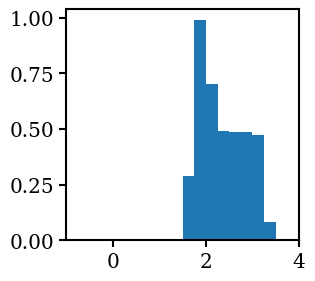

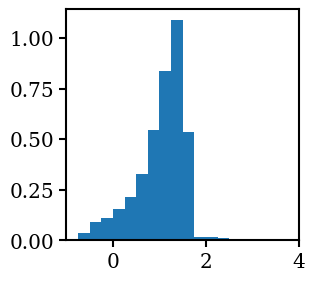

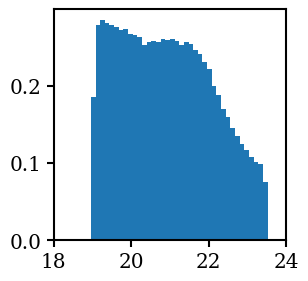

In [269]:
plt.figure(figsize = (3,3))
plt.hist(np.log10(model_tot["HALPHA_FLUX"]),density=True,range=(-1,4),bins = 20)
plt.xlim([-1,4])
plt.show()

plt.figure(figsize = (3,3))
plt.hist(np.log10(model_tot["HALPHA_FLUX_scaled"]),density=True,range=(-1,4),bins=20)
plt.xlim([-1,4])
plt.show()

plt.figure(figsize = (3,3))
plt.hist(model_tot["rfib_mags_decam_noatm_new"],density=True,range=(18,24),bins=50)
plt.xlim([18,24])
plt.show()

In [289]:
model_tot = model_tot[model_tot["SCND_TARGET"] == 0]

In [290]:
print(len(model_tot))

280800


 get the catastrophic fractions for the continuum data

In [210]:
sum_nonebi = sum_cont_tot[(sum_cont_tot["age"] >= 3) & (sum_cont_tot["MAG_R"] < 23.5) & (sum_cont_tot["MAG_R"] > 19)]

cf180_cont, cf180_cont_err = get_purity_fracs(sum_nonebi, dchi2_bins, dchi2_lab="DELTACHI2_180s", zwarn_lab = "ZWARN_180s", zrr_lab = "ZRR_180s",return_catas_frac=True)
cf900_cont, cf900_cont_err = get_purity_fracs(sum_nonebi, dchi2_bins, dchi2_lab="DELTACHI2_900s", zwarn_lab = "ZWARN_900s", zrr_lab = "ZRR_900s",return_catas_frac=True)

# what happens if we split the 180 one by fiber magnitude 
cf180_cont_g1, cf180_cont_g1_err = get_purity_fracs(sum_nonebi[sum_nonebi["MAG_R"] > 21], dchi2_bins, dchi2_lab="DELTACHI2_180s", zwarn_lab = "ZWARN_180s", zrr_lab = "ZRR_180s",return_catas_frac=True)
cf180_cont_g2, cf180_cont_g2_err = get_purity_fracs(sum_nonebi[(sum_nonebi["MAG_R"] < 21) & (sum_nonebi["MAG_R"] > 19.5)], dchi2_bins, dchi2_lab="DELTACHI2_180s", zwarn_lab = "ZWARN_180s", zrr_lab = "ZRR_180s",return_catas_frac=True)


/tmp/ipykernel_1218221/1635583943.py:79: RuntimeWarning: invalid value encountered in long_scalars
  pure_frac = np.sum(isgood_zred)/len(isgood_zred)


In [219]:
# what happens if we split the 180 one by fiber magnitude 
cf180_neb_g1, cf180_neb_g1_err = get_purity_fracs(model_tot[(model_tot["rfib_mags_decam_noatm_new"] > 21) & (model_tot["HALPHA_FLUX_scaled"] < 5 )], dchi2_bins, dchi2_lab="DELTACHI2_180s", zwarn_lab = "ZWARN_180s", zrr_lab = "ZRR_180s",return_catas_frac=True)
cf180_neb_g2, cf180_neb_g2_err = get_purity_fracs(model_tot[(model_tot["rfib_mags_decam_noatm_new"] < 21) & (model_tot["rfib_mags_decam_noatm_new"] > 19.5) & (model_tot["HALPHA_FLUX_scaled"] < 5 )], dchi2_bins, dchi2_lab="DELTACHI2_180s", zwarn_lab = "ZWARN_180s", zrr_lab = "ZRR_180s",return_catas_frac=True)


/tmp/ipykernel_1218221/1635583943.py:79: RuntimeWarning: invalid value encountered in long_scalars
  pure_frac = np.sum(isgood_zred)/len(isgood_zred)


In [283]:
dchi2_bins = 10**np.arange(0,4.5,np.log10(9)/2) 
dchi2_cens = 0.5*(dchi2_bins[1:] + dchi2_bins[:-1])


## SPLIT BY HA FLUX
all_yvals_bri = []
all_yvals_bri_err = []

all_yvals_dark = []
all_yvals_dark_err = []

all_hacens = []

halpha_bins = np.arange(0,20,2.5)

for i in range(len(halpha_bins)-1):

    cf180_highemi_j, cf180_highemi_j_err = get_purity_fracs(model_tot[(model_tot["HALPHA_FLUX_scaled"] > halpha_bins[i]) & (model_tot["HALPHA_FLUX_scaled"] < halpha_bins[i+1])], dchi2_bins, 
                                                            dchi2_lab="DELTACHI2_180s", zwarn_lab = "ZWARN_180s", zrr_lab = "ZRR_180s",return_catas_frac=True)
    
    cf900_highemi_j, cf900_highemi_j_err = get_purity_fracs(model_tot[(model_tot["HALPHA_FLUX_scaled"] > halpha_bins[i]) & (model_tot["HALPHA_FLUX_scaled"] < halpha_bins[i+1])], dchi2_bins, 
                                                            dchi2_lab="DELTACHI2_900s", zwarn_lab = "ZWARN_900s", zrr_lab = "ZRR_900s",return_catas_frac=True)
    
    all_hacens.append( 0.5*(halpha_bins[i] + halpha_bins[i+1]) )
    
    all_yvals_bri.append(cf180_highemi_j)
    all_yvals_bri_err.append(cf180_highemi_j_err)
    
    all_yvals_dark.append(cf900_highemi_j)
    all_yvals_dark_err.append(cf900_highemi_j_err)
    

    
#split by rfib mags
    
all_yvals_bri_rfib = []
all_yvals_bri_rfib_err = []

all_yvals_dark_rfib = []
all_yvals_dark_rfib_err = []

all_rfibcens = []
rfib_bins = np.arange(20,23.5,0.25)

for i in range(len(rfib_bins)-1):

    cf180_highemi_j, cf180_highemi_j_err = get_purity_fracs(model_tot[(model_tot["rfib_mags_decam_noatm_new"] > rfib_bins[i]) & (model_tot["rfib_mags_decam_noatm_new"] < rfib_bins[i+1])], dchi2_bins, 
                                                            dchi2_lab="DELTACHI2_180s", zwarn_lab = "ZWARN_180s", zrr_lab = "ZRR_180s",return_catas_frac=True)
    
    cf900_highemi_j, cf900_highemi_j_err = get_purity_fracs(model_tot[(model_tot["rfib_mags_decam_noatm_new"] > rfib_bins[i]) & (model_tot["rfib_mags_decam_noatm_new"] < rfib_bins[i+1])], dchi2_bins, 
                                                            dchi2_lab="DELTACHI2_900s", zwarn_lab = "ZWARN_900s", zrr_lab = "ZRR_900s",return_catas_frac=True)
    
    all_rfibcens.append( 0.5*(rfib_bins[i] + rfib_bins[i+1]) )
    
    all_yvals_bri_rfib.append(cf180_highemi_j)
    all_yvals_bri_rfib_err.append(cf180_highemi_j_err)
    
    all_yvals_dark_rfib.append(cf900_highemi_j)
    all_yvals_dark_rfib_err.append(cf900_highemi_j_err)
    
    
    
### does the catastrophic fraction depend on both rfib and halpha flux or just one??
    

/tmp/ipykernel_1218221/1635583943.py:79: RuntimeWarning: invalid value encountered in long_scalars
  pure_frac = np.sum(isgood_zred)/len(isgood_zred)


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


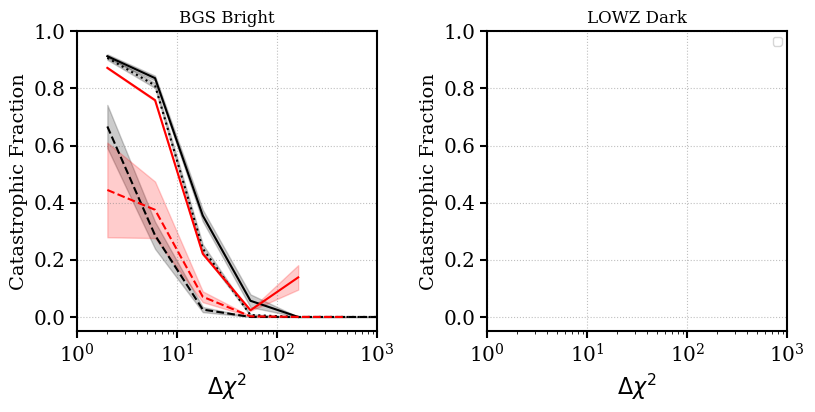

In [220]:
ax = make_subplots(ncol = 2, nrow = 1)

cmap = plt.cm.viridis
colors_spec = cmap(np.linspace(0, 1, len(all_rfibcens)))

plt_between(ax[0], dchi2_cens, np.array(cf180_cont), np.array(cf180_cont_err), color = "k",alpha=0.2,plot_med=True,ls="dotted",label = r"no cont.")

plt_between(ax[0], dchi2_cens, np.array(cf180_cont_g1), np.array(cf180_cont_g1_err), color = "k",alpha=0.2,plot_med=True,ls="-",label = r"no cont. g1")
plt_between(ax[0], dchi2_cens, np.array(cf180_cont_g2), np.array(cf180_cont_g2_err), color = "k",alpha=0.2,plot_med=True,ls="--",label = r"no cont. g2")


# plt_between(ax[0], dchi2_cens, np.array(cf180_cont), np.array(cf180_cont_err), color = "k",alpha=0.2,plot_med=True,ls="dotted",label = r"no cont.")

plt_between(ax[0], dchi2_cens, np.array(cf180_neb_g1), np.array(cf180_neb_g1_err), color = "r",alpha=0.2,plot_med=True,ls="-",label = r"no cont. g1")
plt_between(ax[0], dchi2_cens, np.array(cf180_neb_g2), np.array(cf180_neb_g2_err), color = "r",alpha=0.2,plot_med=True,ls="--",label = r"no cont. g2")


ax[0].set_ylabel(r"Catastrophic Fraction",fontsize = 14)

ax[1].set_ylabel(r"Catastrophic Fraction",fontsize = 14)

ax[0].set_title(r"BGS Bright",fontsize = 12)
ax[1].set_title(r"LOWZ Dark",fontsize = 12)

ax[1].legend(frameon=True,fontsize = 8,loc= "upper right")


for axi in [ax[0],ax[1]]:
    axi.grid(ls = ":",color = "grey",alpha = 0.5)
    axi.set_xscale("log")
    axi.set_xlim([1,1e3])
    axi.set_ylim([-0.05,1.])
    axi.set_xlabel(r"$\Delta\chi^2$",fontsize = 16)
    


In [226]:
model_tot[model_tot["TARGETID"]==39627848159336085][:1]


/global/cfs/cdirs/desi/spectro/redux/iron/healpix/main/bright/276/27654/redrock-main-bright-27654.fits
# 39627848159336085

TARGETID,TARGET_RA,TARGET_DEC,SCND_TARGET,Z,ZWARN,DELTACHI2,SPECTYPE,MAG_R,MAG_G,FIBERFLUX_R,HALPHA_FLUX,HALPHA_FLUX_IVAR,HALPHA_BOXFLUX,HBETA_FLUX,HBETA_BOXFLUX,TSNR2_BGS,TSNR2_LRG,FIBERMAG_R,HEALPIX,MEAN_PSF_TO_FIBER_SPECFLUX,rfib_mags_decam,rfib_mags_decam_noatm,rfib_mags_decam_noatm_nocorr,rfib_mags_decam_noatm_new,DELTACHI2_180s,ZWARN_180s,ZERR_180s,ZRR_180s,ZSUCC_40_180s,ZSUCC_25_180s,ZSUCC_10_180s,DELTACHI2_900s,ZWARN_900s,ZERR_900s,ZRR_900s,ZSUCC_40_900s,ZSUCC_25_900s,ZSUCC_10_900s,HALPHA_FLUX_scaled
int64,float64,float64,int64,float64,int64,float64,bytes6,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int32,float32,float64,float64,float64,float64,float64,int64,float64,float64,int64,int64,int64,float64,int64,float64,float64,int64,int64,int64,float64
39627848159336085,180.9982686661981,2.4376036890999258,0,0.08175056789425522,0,9385.634995639324,GALAXY,15.720873,16.616146,89.641785,55.192596,0.02639669,101.2944,4.1178174,4.1670794,1657.1057,18.420313,17.618725,27654,0.7503157,17.56205850274274,17.566610836951845,17.25472095916835,20.061883704697937,167.8095429702662,0,8.336643610073838e-05,0.08203926445940929,1,1,1,2236.075155252125,0,4.33622536765326e-05,0.08175041264332689,1,1,1,5.543342058085593


In [233]:
Table.read("../../fastspec-example.fits")["HALPHA_FLUX_IVAR"]

0.01233499


In [234]:
1/np.sqrt(0.012)

9.128709291752768

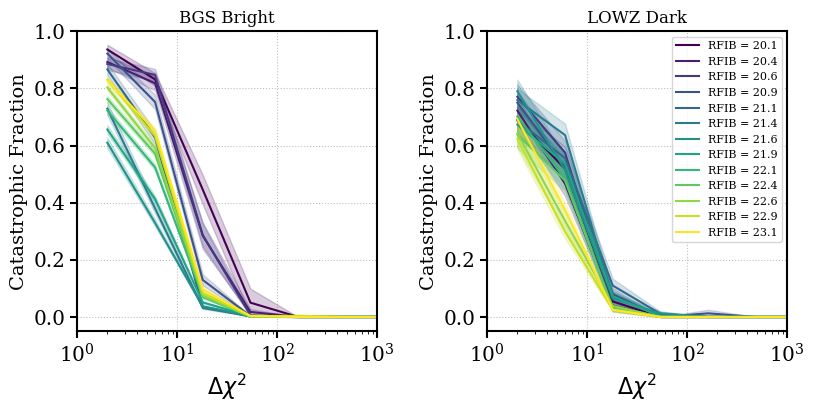

In [274]:
ax = make_subplots(ncol = 2, nrow = 1)

cmap = plt.cm.viridis
colors_spec = cmap(np.linspace(0, 1, len(all_rfibcens)))

# plt_between(ax[0], dchi2_cens, np.array(cf180_cont), np.array(cf180_cont_err), color = "k",alpha=0.2,plot_med=True,ls="dotted",label = r"no cont.")

# plt_between(ax[0], dchi2_cens, np.array(cf180_cont_g1), np.array(cf180_cont_g1_err), color = "k",alpha=0.2,plot_med=True,ls="-",label = r"no cont. g1")
# plt_between(ax[0], dchi2_cens, np.array(cf180_cont_g2), np.array(cf180_cont_g2_err), color = "k",alpha=0.2,plot_med=True,ls="--",label = r"no cont. g2")

for i in range(len(all_rfibcens)):
    plt_between(ax[0], dchi2_cens,np.array(all_yvals_bri_rfib[i]), np.array(all_yvals_bri_rfib_err[i]), color=colors_spec[i],alpha=0.2,plot_med=True,ls="-",label = r"RFIB = %.1f"%(all_rfibcens[i]) )
    
# plt_between(ax[1], dchi2_cens, np.array(cf900_cont), np.array(cf900_cont_err), color = "k",alpha=0.2,plot_med=True,ls="-",label = r"no cont.")

for i in range(len(all_rfibcens)):
    plt_between(ax[1], dchi2_cens,np.array(all_yvals_dark_rfib[i]), np.array(all_yvals_dark_rfib_err[i]), color=colors_spec[i],alpha=0.2,plot_med=True,ls="-",label = r"RFIB = %.1f"%(all_rfibcens[i]) )
    
ax[0].set_ylabel(r"Catastrophic Fraction",fontsize = 14)

ax[1].set_ylabel(r"Catastrophic Fraction",fontsize = 14)

ax[0].set_title(r"BGS Bright",fontsize = 12)
ax[1].set_title(r"LOWZ Dark",fontsize = 12)

ax[1].legend(frameon=True,fontsize = 8,loc= "upper right")


for axi in [ax[0],ax[1]]:
    axi.grid(ls = ":",color = "grey",alpha = 0.5)
    axi.set_xscale("log")
    axi.set_xlim([1,1e3])
    axi.set_ylim([-0.05,1.])
    axi.set_xlabel(r"$\Delta\chi^2$",fontsize = 16)
    


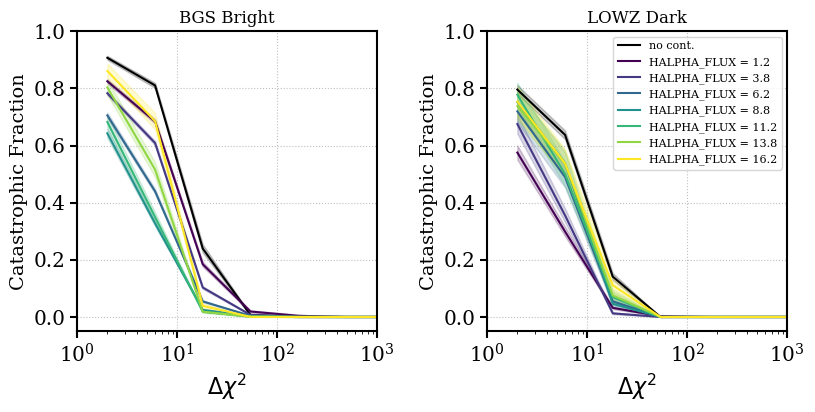

In [284]:
ax = make_subplots(ncol = 2, nrow = 1)

cmap = plt.cm.viridis
colors_spec = cmap(np.linspace(0, 1, len(all_hacens)))

plt_between(ax[0], dchi2_cens, np.array(cf180_cont), np.array(cf180_cont_err), color = "k",alpha=0.2,plot_med=True,ls="-",label = r"no cont.")

for i in range(len(all_hacens)):
    plt_between(ax[0], dchi2_cens,np.array(all_yvals_bri[i]), np.array(all_yvals_bri_err[i]), color=colors_spec[i],alpha=0.2,plot_med=True,ls="-",label = r"HALPHA_FLUX = %.1f"%(all_hacens[i]) )
    
    
plt_between(ax[1], dchi2_cens, np.array(cf900_cont), np.array(cf900_cont_err), color = "k",alpha=0.2,plot_med=True,ls="-",label = r"no cont.")

for i in range(len(all_hacens)):
    plt_between(ax[1], dchi2_cens,np.array(all_yvals_dark[i]), np.array(all_yvals_dark_err[i]), color=colors_spec[i],alpha=0.2,plot_med=True,ls="-",label = r"HALPHA_FLUX = %.1f"%(all_hacens[i]) )
    
    
    
# plt_between(ax[0], dchi2_cens,np.array(pf180_highemi), np.array(pf180_highemi_err), color="k",alpha=0.2,plot_med=True,ls="-" )

# plt_between(ax[0], dchi2_cens,np.array(pf180_highemi_LHA), np.array(pf180_highemi_LHA_err), color="r",alpha=0.2,plot_med=True,ls="-" )
# plt_between(ax[0], dchi2_cens,np.array(pf180_highemi_HHA), np.array(pf180_highemi_HHA_err), color="magenta",alpha=0.2,plot_med=True,ls="-" )

# plt_between(ax[1], dchi2_cens,np.array(pf180_highemi_all), np.array(pf180_highemi_err_all), color="k",alpha=0.2,plot_med=True,ls="-" )

# plt_between(ax[1], dchi2_cens,np.array(pf180_highemi_HHA_all), np.array(pf180_highemi_HHA_err_all), color="magenta",alpha=0.2,plot_med=True,ls="-" )


ax[0].set_ylabel(r"Catastrophic Fraction",fontsize = 14)
ax[1].set_ylabel(r"Catastrophic Fraction",fontsize = 14)


ax[0].set_title(r"BGS Bright",fontsize = 12)
ax[1].set_title(r"LOWZ Dark",fontsize = 12)

ax[1].legend(frameon=True,fontsize = 8,loc= "upper right")


for axi in [ax[0],ax[1]]:
    axi.grid(ls = ":",color = "grey",alpha = 0.5)
    axi.set_xscale("log")
    axi.set_xlim([1,1e3])
    axi.set_ylim([-0.05,1.])
    axi.set_xlabel(r"$\Delta\chi^2$",fontsize = 16)
    


It is interesting that $\Delta\chi^2$ alone does not dictate the catastrophic fraction. It does matter if dark time or bright time, and also on the value of the halpha flux ... 

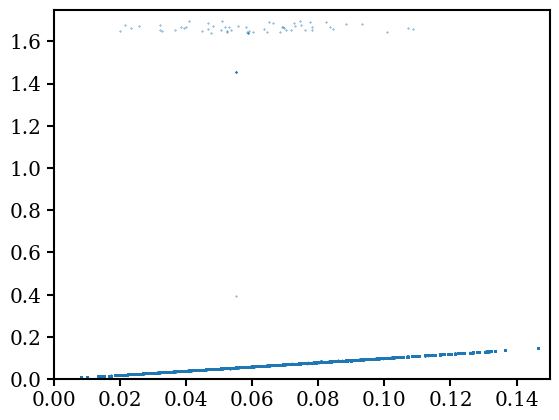

In [280]:


plt.scatter(model_tot["Z"][model_tot["DELTACHI2_180s"] > 40], model_tot["ZRR_180s"][model_tot["DELTACHI2_180s"] > 40],s=0.1)
plt.xlim([0,0.15])
plt.ylim([0,1.75])
plt.show()

In [282]:
# model_tot[(model_tot["DELTACHI2_180s"] > 40) & (model_tot["ZRR_180s"] > 1.6)]
# ## these are some very weird galaxies ...

/tmp/ipykernel_1218221/1635583943.py:79: RuntimeWarning: invalid value encountered in long_scalars
  pure_frac = np.sum(isgood_zred)/len(isgood_zred)


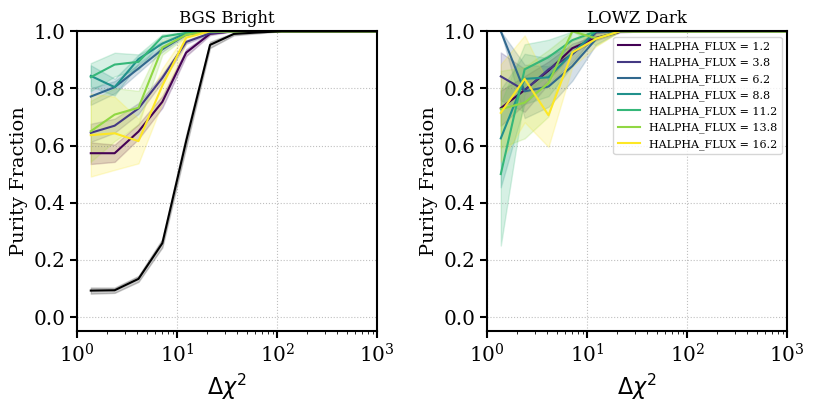

In [297]:
    
    
### make plot
ax = make_subplots(ncol = 2, nrow = 1)

cmap = plt.cm.viridis
colors_spec = cmap(np.linspace(0, 1, len(all_hacens)))

for i in range(len(all_hacens)):
    plt_between(ax[0], dchi2_cens,np.array(all_pw_bri[i]), np.array(all_pw_bri_err[i]), color=colors_spec[i],alpha=0.2,plot_med=True,ls="-",label = r"HALPHA_FLUX = %.1f"%(all_hacens[i]) )
    
plt_between(ax[0], dchi2_cens, np.array(pf180_cont), np.array(pf180_cont_err), color = "k",alpha=0.2,plot_med=True,ls="-",label = r"no cont.")
    
    
for i in range(len(all_hacens)):
    plt_between(ax[1], dchi2_cens,np.array(all_pw_dark[i]), np.array(all_pw_dark_err[i]), color=colors_spec[i],alpha=0.2,plot_med=True,ls="-",label = r"HALPHA_FLUX = %.1f"%(all_hacens[i]) )
    

ax[0].set_ylabel(r"Purity Fraction",fontsize = 14)
ax[1].set_ylabel(r"Purity Fraction",fontsize = 14)


ax[0].set_title(r"BGS Bright",fontsize = 12)
ax[1].set_title(r"LOWZ Dark",fontsize = 12)

ax[1].legend(frameon=True,fontsize = 8,loc= "upper right")


for axi in [ax[0],ax[1]]:
    axi.grid(ls = ":",color = "grey",alpha = 0.5)
    axi.set_xscale("log")
    axi.set_xlim([1,1e3])
    axi.set_ylim([-0.05,1.])
    axi.set_xlabel(r"$\Delta\chi^2$",fontsize = 16)
    


In [16]:

from scipy.stats import binned_statistic_2d

def get_zsucc_obs_cont(lowz_all, rfib_bins, color = "HALPHA_FLUX",fibmag="FIBERMAG_R",num_samp=10,min_count=10):
    '''
    Function computes the redshift failure rate in each 2D bins of rfiber and gr_bins

    '''
    #we can compute the error on this using binomial normal approx.
    sigma_errs = np.array(1/np.sqrt(lowz_all[color + "_IVAR"]))
    sigma_errs[np.isinf(sigma_errs)] = 0.01
    mus = np.array(lowz_all[color])
    
    all_zfail_stat = []
    
    for _ in trange(num_samp):
        zfail_all_i = []
        
        new_mus = np.random.normal(loc=mus, scale= sigma_errs)
        #just make sure they are not negative
        new_mus[new_mus < 0] = 0
        
        #looping over fiber mags 
        for r in range(len(rfib_bins) - 1):
            lowz_ij = lowz_all[(lowz_all[fibmag] >= rfib_bins[r]) & (lowz_all[fibmag] <= rfib_bins[r+1]) ]
            mus_ij = new_mus[ (lowz_all[fibmag] >= rfib_bins[r]) & (lowz_all[fibmag] <= rfib_bins[r+1]) ]
            sig_ij = sigma_errs[ (lowz_all[fibmag] >= rfib_bins[r]) & (lowz_all[fibmag] <= rfib_bins[r+1]) ]
            
        
            #only select new_mus == 0
            tot_cont_f = np.array(lowz_ij["TOT_COUNT"])[(mus_ij == 0)]
        
            if np.sum(tot_cont_f) > min_count:
                zsucc_cont_f = np.array(lowz_ij["ZSUCC_COUNT"])[(mus_ij == 0)]
                zsucc_i = np.sum(zsucc_cont_f)/np.sum(tot_cont_f)    
                zfail_i = 1 - zsucc_i
            else:
                zfail_i = np.nan 
                
            zfail_all_i.append(zfail_i)
            
        all_zfail_stat.append(zfail_all_i)
        
    all_zfail_stat = np.array(all_zfail_stat)
    #compute the mean and standard deviation along each cell
    zfail_mean = np.nanmedian(all_zfail_stat,axis = 0)
    zfail_std = np.nanstd(all_zfail_stat,axis = 0)
    
    return zfail_mean, zfail_std


In [76]:
bgs_vac = Table.read("/pscratch/sd/v/virajvm/catalog/iron_bgs_bright_vac_halpha.fits")
lowz_vac = Table.read("/pscratch/sd/v/virajvm/catalog/iron_lowz_dark_vac_halpha.fits")


# I want to remove galaxies where HALPHA_FLUX = 0 but BOXFLUX > 0 and HBETA_FLUX > 0
bad_bgs_mask1 = (bgs_vac["HALPHA_FLUX"] == 0) & (bgs_vac["HALPHA_BOXFLUX"] >= 0)
bad_bgs_mask2 = (bgs_vac["HALPHA_FLUX"] == 0) & (bgs_vac["HBETA_FLUX"] > 0)
bad_bgs_mask = bad_bgs_mask1 | bad_bgs_mask2

bad_lowz_mask1 =  (lowz_vac["HALPHA_FLUX"] == 0) & (lowz_vac["HALPHA_BOXFLUX"] >= 0) 
bad_lowz_mask2 = (lowz_vac["HALPHA_FLUX"] == 0) & (lowz_vac["HBETA_FLUX"] > 0)
bad_lowz_mask = bad_lowz_mask1 | bad_lowz_mask2

print(np.sum(bad_bgs_mask),np.sum(bad_lowz_mask))

bgs_vac = bgs_vac[~bad_bgs_mask]
lowz_vac = lowz_vac[~bad_lowz_mask]

#also remove galaxies with incomplete wavelength coverage or other warnings that would interfere

bgs_vac = bgs_vac[(bgs_vac["ZWARN"] == 0) | (bgs_vac["ZWARN"] == 4) ]
lowz_vac = lowz_vac[(lowz_vac["ZWARN"] == 0) | (lowz_vac["ZWARN"] == 4)  ]

print(len(bgs_vac),len(lowz_vac))

print(np.unique(bgs_vac["ZWARN"]))


def zsuccess_mask(gals, dchi2): 
    crit_zwarn = (gals['ZWARN'] == 0)
    crit_dchi2 = (gals['DELTACHI2'] > dchi2)
    crit_stype = (gals['SPECTYPE'] == 'GALAXY') | (gals['SPECTYPE'] == 'QSO')
    crit_z_lim = (gals['Z'] > 0.)
    # crit_z_err = (gals['ZERR'] < (0.0005 * (1. + gals['Z'])))
    zsuccess   = (crit_zwarn & crit_dchi2 & crit_stype & crit_z_lim)
    # zsuccess   = (crit_zwarn & crit_dchi2 & crit_z_lim)
    
    return zsuccess


bgs_vac["TOT_COUNT"] = np.ones(len(bgs_vac))
bgs_vac["ZSUCC_COUNT"] = zsuccess_mask(bgs_vac, 40)

lowz_vac["TOT_COUNT"] = np.ones(len(lowz_vac))
lowz_vac["ZSUCC_COUNT"] = zsuccess_mask(lowz_vac, 40)


466455 4964
4041113 96838
ZWARN
-----
    0
    4


In [16]:

zfail_bgs_cont_mean, zfail_bgs_cont_std = get_zsucc_obs_cont(bgs_vac[bgs_vac["Z"] < 0.1], rfib_bins, color = "HALPHA_FLUX",fibmag="FIBERMAG_R",num_samp=25,min_count=5)
zfail_lowz_cont_mean, zfail_lowz_cont_std = get_zsucc_obs_cont(lowz_vac[lowz_vac["Z"] < 0.1], rfib_bins, color = "HALPHA_FLUX",fibmag="FIBERMAG_R",num_samp=25,min_count=5)



/tmp/ipykernel_2121802/3764072960.py:9: RuntimeWarning: divide by zero encountered in true_divide
  sigma_errs = np.array(1/np.sqrt(lowz_all[color + "_IVAR"]))
100%|██████████| 25/25 [00:12<00:00,  2.06it/s]
/global/common/software/desi/perlmutter/desiconda/20230111-2.1.0/conda/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1218: RuntimeWarning: All-NaN slice encountered
  r, k = function_base._ureduce(a, func=_nanmedian, axis=axis, out=out,
/global/common/software/desi/perlmutter/desiconda/20230111-2.1.0/conda/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
100%|██████████| 25/25 [00:00<00:00, 49.42it/s]


In [17]:
def plot_contour(ax,xvals, yvals, yerrs, alpha = 0.2, color = "mediumblue"):
    ax.fill_between(xvals,yvals - yerrs,yvals + yerrs,alpha = alpha, color = color)
    return

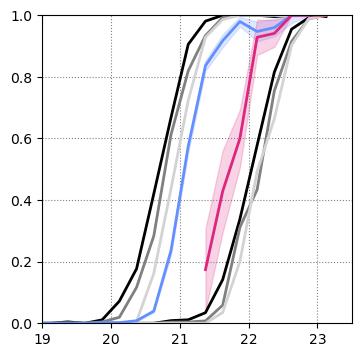

In [18]:

bgs_col = "#648FFF" #DC267F
lowz_col = "#DC267F"

fig,ax = plt.subplots(1,1,figsize = (4,4))
# plt.errorbar(rfib_cens, y=zfail_180_model, yerr = zfail_err_180_model, color = "k",capsize=3,ls="none",marker=".",markersize=5 )
ax.plot(rfib_cens,zfail_180_model_1,color = "k",lw = 2)
ax.plot(rfib_cens,zfail_180_model_2,color = "grey",lw = 2)
ax.plot(rfib_cens,zfail_180_model_3,color = "lightgrey",lw = 2)

# plt.errorbar(rfib_cens, y=zfail_900_model, yerr = zfail_err_900_model, color = "k",capsize=3,ls="none",marker=".",markersize=5 )
ax.plot(rfib_cens,zfail_900_model_1,color = "k",lw=2)
ax.plot(rfib_cens,zfail_900_model_2,color = "grey",lw=2)
ax.plot(rfib_cens,zfail_900_model_3,color = "lightgrey",lw=2)

ax.plot(rfib_cens, zfail_bgs_cont_mean, color = bgs_col, lw = 2)
plot_contour(ax,rfib_cens, zfail_bgs_cont_mean, zfail_bgs_cont_std, color = bgs_col)

ax.plot(rfib_cens, zfail_lowz_cont_mean, color = lowz_col, lw = 2)
plot_contour(ax,rfib_cens, zfail_lowz_cont_mean, zfail_lowz_cont_std, color = lowz_col)

ax.grid(ls = ":",color = "grey")
ax.set_xlim([19,23.5])
ax.set_ylim([0,1])

plt.show()


In [78]:
bgs_vac["g-r"] = bgs_vac["MAG_G"]- bgs_vac["MAG_R"]
lowz_vac["g-r"] = lowz_vac["MAG_G"]- lowz_vac["MAG_R"]

## the color distributions are probably not the same ...

In [79]:
bgs_temp = bgs_vac[bgs_vac["Z"] < 0.15]
lowz_temp = lowz_vac[lowz_vac["Z"] < 0.15]


In [81]:
import numpy as np
from sklearn.neighbors import NearestNeighbors

# Example data
# Dataset 1 (reference dataset)
# data1 = np.array([ bgs_temp["Z"], bgs_temp["FIBERMAG_R"], bgs_temp["g-r"] ]).T  # 100 points with 3 variables (x, y, z)
data_bgs = np.array([ bgs_temp["Z"], bgs_temp["FIBERMAG_R"]]).T  # 100 points with 3 variables (x, y, z)
data_lowz = np.array([ lowz_temp["Z"], lowz_temp["FIBERMAG_R"]]).T  # 100 points with 3 variables (x, y, z)

# Dataset 2 (target dataset)
# data2 = np.array([ sum_cont_tot["Z"], sum_cont_tot["MAG_R"], sum_cont_tot["g-r"] ]).T  # 200 points with 3 variables (x, y, z)
data2_lowz = np.array([ sum_cont_tot[sum_cont_tot["ZRR_900s"] < 0.15]["ZRR_900s"],  sum_cont_tot[sum_cont_tot["ZRR_900s"] < 0.15]["MAG_R"] ]).T  # 200 points with 3 variables (x, y, z)
data2_bgs = np.array([ sum_cont_tot[sum_cont_tot["ZRR_180s"] < 0.15]["ZRR_180s"],  sum_cont_tot[sum_cont_tot["ZRR_180s"] < 0.15]["MAG_R"] ]).T  # 200 points with 3 variables (x, y, z)

# Initialize the nearest neighbors model
# Setting n_neighbors=1 to find the closest point for each reference point in data1
nn_model_bgs = NearestNeighbors(n_neighbors=4)
nn_model_bgs.fit(data2_bgs)

nn_model_lowz = NearestNeighbors(n_neighbors=4)
nn_model_lowz.fit(data2_lowz)

# Find nearest neighbors in data2 for each point in data1
distances, indices_bgs = nn_model_bgs.kneighbors(data_bgs)
distances, indices_lowz = nn_model_lowz.kneighbors(data_lowz)

# Matched points in data2
matched_points_bgs = data2_bgs[indices_bgs.flatten()]
matched_points_lowz = data2_lowz[indices_lowz.flatten()]



In [88]:
# plt.hist(bgs_temp["FIBERMAG_R"],range=(18,24),bins = 10,density=True)
# plt.hist(matched_points_bgs[:,1],range=(18,24),bins = 10,density=True)
# plt.show()

# plt.hist(bgs_temp["Z"],range=(0,0.15),bins = 10,density=True)
# plt.hist(matched_points_bgs[:,0],range=(0,0.15),bins = 10,density=True)
# plt.show()

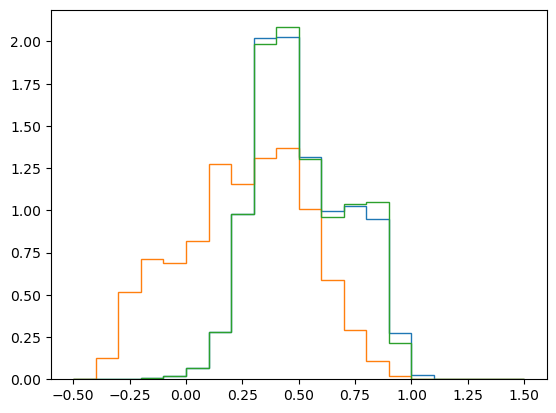

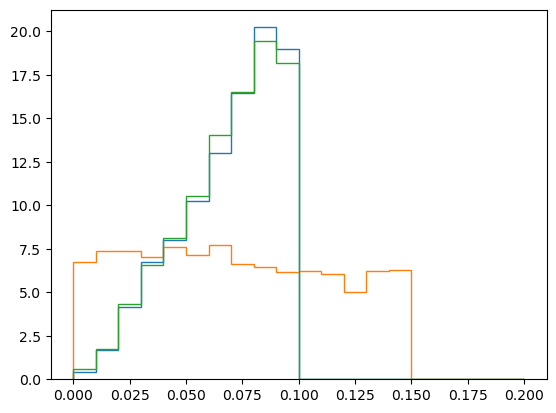

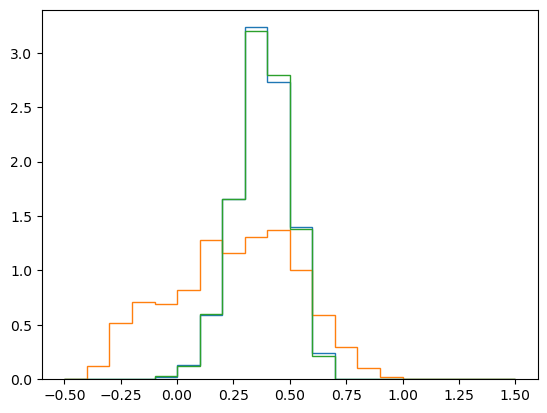

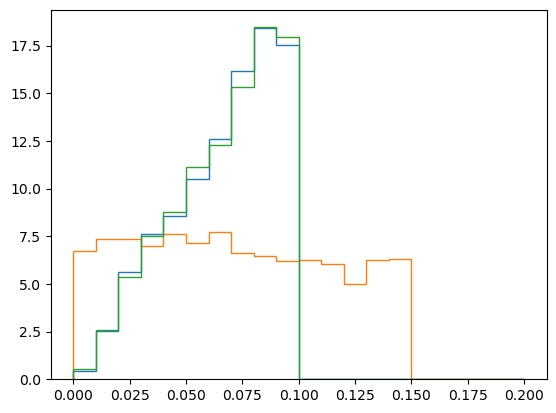

In [24]:
plt.hist(bgs_temp["g-r"], bins = 20,density = True,histtype = "step",range = (-0.5, 1.5))
plt.hist(sum_cont_tot[sum_cont_tot["Z"] < 0.15]["g-r"], bins = 20,density = True,histtype = "step",range = (-0.5, 1.5))
plt.hist(matched_points_bgs[:,1], bins = 20,density = True,histtype = "step",range = (-0.5, 1.5))
plt.show()

plt.hist(bgs_temp["Z"], bins = 20,density = True,histtype = "step",range = (0, 0.2))
plt.hist(sum_cont_tot[sum_cont_tot["Z"] < 0.15]["Z"], bins = 20,density = True,histtype = "step",range = (0, 0.2))
plt.hist(matched_points_bgs[:,0], bins = 20,density = True,histtype = "step",range = (0, 0.2))
plt.show()

####

plt.hist(lowz_temp["g-r"], bins = 20,density = True,histtype = "step",range = (-0.5, 1.5))
plt.hist(sum_cont_tot[sum_cont_tot["Z"] < 0.15]["g-r"], bins = 20,density = True,histtype = "step",range = (-0.5, 1.5))
plt.hist(matched_points_lowz[:,1], bins = 20,density = True,histtype = "step",range = (-0.5, 1.5))
plt.show()

plt.hist(lowz_temp["Z"], bins = 20,density = True,histtype = "step",range = (0, 0.2))
plt.hist(sum_cont_tot[sum_cont_tot["Z"] < 0.15]["Z"], bins = 20,density = True,histtype = "step",range = (0, 0.2))
plt.hist(matched_points_lowz[:,0], bins = 20,density = True,histtype = "step",range = (0, 0.2))
plt.show()


In [25]:
sum_cont_bgs = sum_cont_tot[indices_bgs.flatten()]
sum_cont_lowz = sum_cont_tot[indices_lowz.flatten()]

mc = 5
_,zfail_bgsmat_180_model, _=  get_zsucc_trends(sum_cont_bgs, rfib_bins, fibmag="MAG_R",min_count = mc,zsucc_flag = "ZSUCC_40_180s")
_,zfail_lowzmat_900_model, zfail_err_lowzmat_900_model=  get_zsucc_trends(sum_cont_lowz, rfib_bins, fibmag="MAG_R",min_count = mc,zsucc_flag = "ZSUCC_40_900s")



In [26]:
len(sum_cont_lowz)

95628

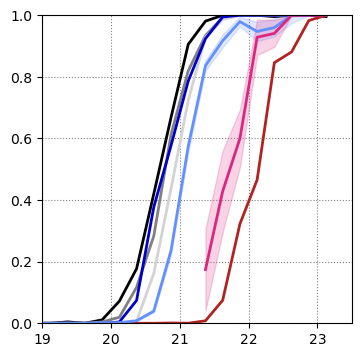

In [27]:

bgs_col = "#648FFF" #DC267F
lowz_col = "#DC267F"

fig,ax = plt.subplots(1,1,figsize = (4,4))
# plt.errorbar(rfib_cens, y=zfail_180_model, yerr = zfail_err_180_model, color = "k",capsize=3,ls="none",marker=".",markersize=5 )
ax.plot(rfib_cens,zfail_180_model_1,color = "k",lw = 2)
ax.plot(rfib_cens,zfail_180_model_2,color = "grey",lw = 2)
ax.plot(rfib_cens,zfail_180_model_3,color = "lightgrey",lw = 2)


ax.plot(rfib_cens,zfail_bgsmat_180_model,color = "mediumblue",lw = 2)
ax.plot(rfib_cens,zfail_lowzmat_900_model,color = "firebrick",lw = 2)

# plt.errorbar(rfib_cens, y=zfail_900_model, yerr = zfail_err_900_model, color = "k",capsize=3,ls="none",marker=".",markersize=5 )
# ax.plot(rfib_cens,zfail_900_model_1,color = "k",lw=2)
# ax.plot(rfib_cens,zfail_900_model_2,color = "grey",lw=2)
# ax.plot(rfib_cens,zfail_900_model_3,color = "lightgrey",lw=2)

ax.plot(rfib_cens, zfail_bgs_cont_mean, color = bgs_col, lw = 2)
plot_contour(ax,rfib_cens, zfail_bgs_cont_mean, zfail_bgs_cont_std, color = bgs_col)

ax.plot(rfib_cens, zfail_lowz_cont_mean, color = lowz_col, lw = 2)
plot_contour(ax,rfib_cens, zfail_lowz_cont_mean, zfail_lowz_cont_std, color = lowz_col)

ax.grid(ls = ":",color = "grey")
ax.set_xlim([19,23.5])
ax.set_ylim([0,1])

plt.show()


## get COSMOS-dw1 spectra from DESI

In [243]:
# import DESI related modules - 
from desimodel.footprint import radec2pix      # For getting healpix values
import desispec.io                             # Input/Output functions related to DESI spectra
from desispec import coaddition                # Functions related to coadding the spectra
from astropy.convolution import convolve, Gaussian1DKernel
from astropy.table import QTable

specprod = 'iron'    # Internal name for the EDR
specprod_dir = '/global/cfs/cdirs/desi/spectro/redux/iron'

zpix_cat = Table.read(f'{specprod_dir}/zcatalog/zall-pix-{specprod}.fits', hdu="ZCATALOG")
# zpix_cat = Table.read(f'{specprod_dir}/zcatalog/zpix-main-dark.fits', hdu="ZCATALOG")

healpix_dir = f'{specprod_dir}/healpix'


In [248]:
## a quick aside on figuring out the exposure time for BGS BRIGHT and LOWZ DARK objects so now what to really simulate ...

from desitarget.targetmask import bgs_mask

In [249]:
lowz_mask = (zpix_cat["SCND_TARGET"] == 2**15) | (zpix_cat["SCND_TARGET"] == 2**16) | (zpix_cat["SCND_TARGET"] == 2**17)
bgs_mask2 = (zpix_cat["BGS_TARGET"] & bgs_mask["BGS_BRIGHT"]) != 0

# lowz_exptime = 12.15 * zpix_cat["TSNR2_LRG"][lowz_mask]
bgs_exptime = 12.15 * zpix_cat["TSNR2_LRG"][bgs_mask2]

##see section 4.14 of https://arxiv.org/pdf/2209.14482 for reference on this


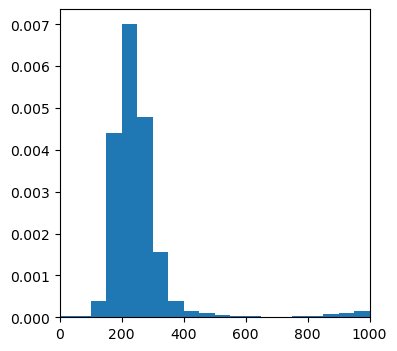

In [251]:
## for lowz it peak around 1000s.
## for bgs bright, it seems to peak around 220
## but this is due to some definitional issues that Changhoon mentioned over slack .. so just assume the typical 180 and 900s

## these are a little higher than the nominal defitions I know of ... 

plt.figure(figsize = (4,4))
plt.hist(bgs_exptime,bins = 100,range = (0,5000),density = True)
plt.xlim([0,1000])
plt.show()


In [404]:
tgid = 39627841603636730

In [97]:

def get_spectra(tgid_interest,zpix_cat, plot=True,save=False,save_path=""):
    '''
    Function that gets the spectra for the single object.
    
    The following need to be run before this function
    
    # import DESI related modules - 
    from desimodel.footprint import radec2pix      # For getting healpix values
    import desispec.io                             # Input/Output functions related to DESI spectra
    from desispec import coaddition                # Functions related to coadding the spectra
    from astropy.convolution import convolve, Gaussian1DKernel

    specprod = 'iron'    # Internal name for the EDR
    specprod_dir = '/global/cfs/cdirs/desi/spectro/redux/iron/'

    zpix_cat = Table.read(f'{specprod_dir}/zcatalog/zall-pix-{specprod}.fits', hdu="ZCATALOG")  
    healpix_dir = f'{specprod_dir}/healpix'
    
    '''
    ## let us look for a specific targetid now 
    # tgid_interest = 39633544431013755 #39627959681680829 # 2706251414765568


    # Selecting the redshift catalogs rows for the particular targetid
    rows = zpix_cat['TARGETID'] == tgid_interest
    zcat_sel = zpix_cat[rows]
        
    zred_tgt = np.array(zcat_sel["Z"])
    delta_chi2 = np.array(zcat_sel["DELTACHI2"])
    print(zred_tgt,delta_chi2)
    
    if len(zcat_sel) > 1:
        zred_tgt = zred_tgt[0]

    print("Number of spectra found = ", len(zcat_sel))
    
    survey_col = zcat_sel['SURVEY'].astype(str)
    program_col = zcat_sel['PROGRAM'].astype(str)
    hpx_col = zcat_sel['HEALPIX']

    # Selecting the primary spectra - 
    is_primary = zcat_sel['ZCAT_PRIMARY']

    # Information needed to access the spectra 
    survey = survey_col[is_primary][0]
    program = program_col[is_primary][0]
    hpx = hpx_col[is_primary][0]    ## This is same for all the rows, given its the same TARGET. But, just to be consistent.

    # Let us explore the target directory
    # Note that the target directory is different for the different spectra.
    # We first explore the primary spectra and look at the other spectra later.
    tgt_dir = f'{healpix_dir}/{survey}/{program}/{hpx//100}/{hpx}'
    
    coadd_filename = f'coadd-{survey}-{program}-{hpx}.fits'    
    
    h_coadd = fits.open(f'{tgt_dir}/{coadd_filename}')
    
    coadd_obj = desispec.io.read_spectra(f'{tgt_dir}/{coadd_filename}')
    coadd_tgts = coadd_obj.target_ids().data
    #coadd the spec now 
    
    # Selecting the particular spectra of the targetid
    row = (coadd_tgts == tgid_interest)
    coadd_spec = coadd_obj[row]
    
    spec_combined = coaddition.coadd_cameras(coadd_spec)    
    
    
    if plot==True:
        plt.figure(figsize = (20, 7))
        # Plot the combined spectrum in maroon
        plt.plot(spec_combined.wave['brz'], spec_combined.flux['brz'][0], color = 'grey', alpha = 0.6)
        plt.plot(spec_combined.wave['brz'], 1/np.sqrt(spec_combined.ivar['brz'][0]),color = "darkorange",alpha = 0.6)
        # Over-plotting smoothed spectra 
        plt.plot(spec_combined.wave['brz'], convolve(spec_combined.flux['brz'][0], Gaussian1DKernel(3)) , color = 'k', lw = 1.25)

        plt.text(6000,np.max(spec_combined.flux['brz'][0][500:-500])*0.7,r"$z = %.4f$, TARGETID = %d"%(zred_tgt,tgid_interest),fontsize = 22)

        ## we need to plot the restframe lines here
        # plt.vlines(x = 6562.8, ymin = -1,ymax = 10,lw = 1,alpha = 0.75,ls = "--",color ="slateblue",zorder = -10)
        # plt.vlines(x = 4861.4, ymin = -1,ymax = 10,lw = 1,alpha = 0.75,ls = "--",color ="slateblue",zorder = -10)
        # plt.vlines(x = 4340.5, ymin = -1,ymax = 10,lw = 1,alpha = 0.75,ls = "--",color ="slateblue",zorder = -10)
        # plt.vlines(x = 4959, ymin = -1,ymax = 10,lw = 2,alpha = .75,ls = "--",color ="slateblue",zorder = -10)
        # plt.vlines(x = 5007, ymin = -1,ymax = 10,lw = 2,alpha = .75,ls = "--",color ="slateblue",zorder = -10)
        # plt.vlines(x = 3729, ymin = -1,ymax = 10,lw = 2,alpha = .75,ls = "--",color ="slateblue",zorder = -10)

        plt.xlim([3550, 9400])
        plt.ylim([-0.2,np.max(spec_combined.flux['brz'][0][500:-500])*0.8])
        plt.xlabel('Rest-Frame Wavelength [$\AA$]',fontsize = 22)
        plt.ylabel('$F_{\lambda}$ [$10^{-17} erg\ s^{-1}\ cm^{-2}\ \AA^{-1}$]',fontsize = 22)
        plt.xticks(fontsize = 20)
        plt.yticks(fontsize = 20)
        if save:
            plt.savefig(save_path + "plot_%d.png"%tgid_interest)
            plt.close()
        else:
            plt.show()
            
    if save:
        spec_tab = QTable([spec_combined.wave['brz'], spec_combined.flux['brz'][0], spec_combined.ivar['brz'][0]],names=('wave', 'flux', 'ivar') )
        spec_tab.write(save_path + "spectra_%d.fits"%tgid_interest,overwrite=True)

    return spec_combined, zcat_sel
    
    

In [644]:
hbeta_w = 4861.333
hgamma_w = 4340.471
hdelta_w = 4101.742



[1.2265707  0.02493285] [12.70342247  0.94565523]
Number of spectra found =  2
INFO:spectra.py:291:read_spectra: iotime 0.297 sec to read coadd-sv1-bright-27258.fits at 2024-10-13T23:20:57.738738


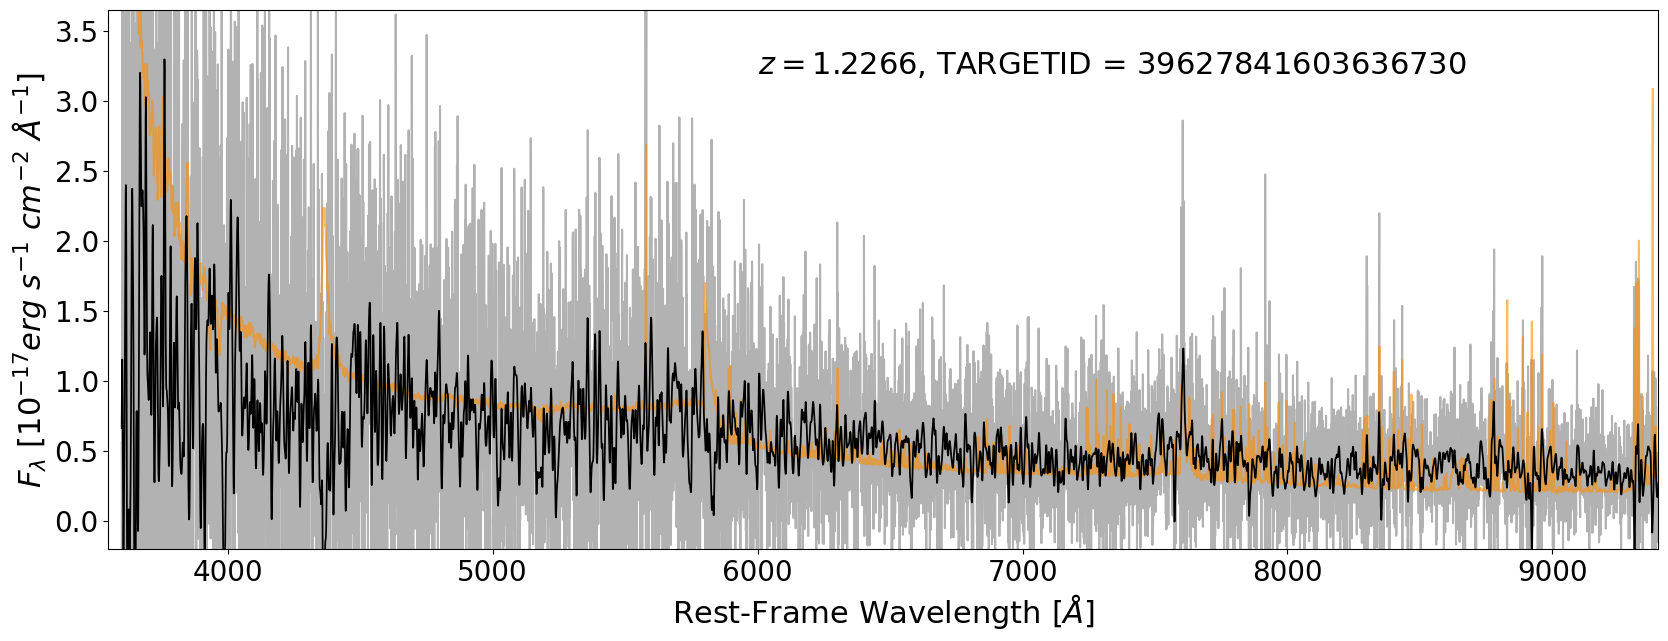

In [418]:
spec_combined,zcat_sel = get_spectra(tgid,zpix_cat)

In [419]:
zcat_sel

TARGETID,SURVEY,PROGRAM,HEALPIX,SPGRPVAL,Z,ZERR,ZWARN,CHI2,COEFF,NPIXELS,SPECTYPE,SUBTYPE,NCOEFF,DELTACHI2,COADD_FIBERSTATUS,TARGET_RA,TARGET_DEC,PMRA,PMDEC,REF_EPOCH,FA_TARGET,FA_TYPE,OBJTYPE,SUBPRIORITY,OBSCONDITIONS,RELEASE,BRICKNAME,BRICKID,BRICK_OBJID,MORPHTYPE,EBV,FLUX_G,FLUX_R,FLUX_Z,FLUX_W1,FLUX_W2,FLUX_IVAR_G,FLUX_IVAR_R,FLUX_IVAR_Z,FLUX_IVAR_W1,FLUX_IVAR_W2,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,FIBERTOTFLUX_G,FIBERTOTFLUX_R,FIBERTOTFLUX_Z,MASKBITS,SERSIC,SHAPE_R,SHAPE_E1,SHAPE_E2,REF_ID,REF_CAT,GAIA_PHOT_G_MEAN_MAG,GAIA_PHOT_BP_MEAN_MAG,GAIA_PHOT_RP_MEAN_MAG,PARALLAX,PHOTSYS,PRIORITY_INIT,NUMOBS_INIT,CMX_TARGET,DESI_TARGET,BGS_TARGET,MWS_TARGET,SCND_TARGET,SV1_DESI_TARGET,SV1_BGS_TARGET,SV1_MWS_TARGET,SV1_SCND_TARGET,SV2_DESI_TARGET,SV2_BGS_TARGET,SV2_MWS_TARGET,SV2_SCND_TARGET,SV3_DESI_TARGET,SV3_BGS_TARGET,SV3_MWS_TARGET,SV3_SCND_TARGET,PLATE_RA,PLATE_DEC,COADD_NUMEXP,COADD_EXPTIME,COADD_NUMNIGHT,COADD_NUMTILE,MEAN_DELTA_X,RMS_DELTA_X,MEAN_DELTA_Y,RMS_DELTA_Y,MEAN_FIBER_RA,STD_FIBER_RA,MEAN_FIBER_DEC,STD_FIBER_DEC,MEAN_PSF_TO_FIBER_SPECFLUX,TSNR2_GPBDARK_B,TSNR2_ELG_B,TSNR2_GPBBRIGHT_B,TSNR2_LYA_B,TSNR2_BGS_B,TSNR2_GPBBACKUP_B,TSNR2_QSO_B,TSNR2_LRG_B,TSNR2_GPBDARK_R,TSNR2_ELG_R,TSNR2_GPBBRIGHT_R,TSNR2_LYA_R,TSNR2_BGS_R,TSNR2_GPBBACKUP_R,TSNR2_QSO_R,TSNR2_LRG_R,TSNR2_GPBDARK_Z,TSNR2_ELG_Z,TSNR2_GPBBRIGHT_Z,TSNR2_LYA_Z,TSNR2_BGS_Z,TSNR2_GPBBACKUP_Z,TSNR2_QSO_Z,TSNR2_LRG_Z,TSNR2_GPBDARK,TSNR2_ELG,TSNR2_GPBBRIGHT,TSNR2_LYA,TSNR2_BGS,TSNR2_GPBBACKUP,TSNR2_QSO,TSNR2_LRG,MAIN_NSPEC,MAIN_PRIMARY,SV_NSPEC,SV_PRIMARY,ZCAT_NSPEC,ZCAT_PRIMARY
int64,bytes7,bytes6,int32,int32,float64,float64,int64,float64,float64[10],int64,bytes6,bytes20,int64,float64,int32,float64,float64,float32,float32,float32,int64,uint8,bytes3,float64,int32,int16,bytes8,int32,int32,bytes4,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,float32,float32,int64,bytes2,float32,float32,float32,float32,bytes1,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,float64,float64,int16,float32,int16,int16,float32,float32,float32,float32,float64,float32,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int32,bool,int32,bool,int64,bool
39627841603636730,sv1,bright,27258,27258,1.2265706971481438,8.746026325084095e-05,0,8144.043029427528,-115.72512499804385 .. -27.893473343736495,7927,GALAXY,--,10,12.703422471880913,0,150.12523156786887,2.1497127579184987,0.0,0.0,2021.0883,1152921504606846976,1,TGT,0.9134090253947429,4,9010,1501p022,343928,3578,EXP,0.017784242,50.240005,57.75293,63.74134,32.93649,31.481897,12.256941,3.6828845,0.44637087,0.49424005,0.13057442,0.7443646,0.8556774,0.94440275,0.7443646,0.8556774,0.94440275,2048,1.0,7.9914565,0.04811792,-0.16278817,0,--,0.0,0.0,0.0,0.0,S,2000,1,0,0,0,0,0,1152921504606846976,655370,0,0,0,0,0,0,0,0,0,0,150.12523156786887,2.1497127579184987,7,6330.382,3,1,0.0014945568,0.00754392,0.00053260924,0.0030596538,150.12523389285977,0.09428737,2.1497121933120225,0.044937477,0.7462736,66.24785,0.039874822,13.176635,38.214302,222.81123,116.17798,1.0875149,0.33816332,4872.1494,11.5225935,948.22723,0.017004726,1083.2623,7830.4927,3.4491255,16.24467,8.09382e-06,51.501427,1.6068511e-06,0.0,2176.4739,1.4099146e-05,10.388711,22.198053,4938.3975,63.063896,961.4039,38.231308,3482.5474,7946.671,14.925351,38.780888,0,False,2,True,2,True
39627841603636730,sv3,bright,27258,27258,0.024932853034993218,5.993024800997649e-05,4,8237.607362251118,503.13362529513256 .. 23.068484418393,7838,GALAXY,--,10,0.9456552310439292,0,150.12523156786887,2.1497127579184987,0.0,0.0,2015.5,1152921504606846976,1,TGT,0.5027745323523478,516,9010,1501p022,343928,3578,EXP,0.017784242,50

In [432]:
22.5 - 2.5*np.log10(zcat_sel["FIBERFLUX_R"])

22.669226
22.669226


In [433]:
22.5 - 2.5*np.log10(zcat_sel["FLUX_R"])

18.096066
18.096066


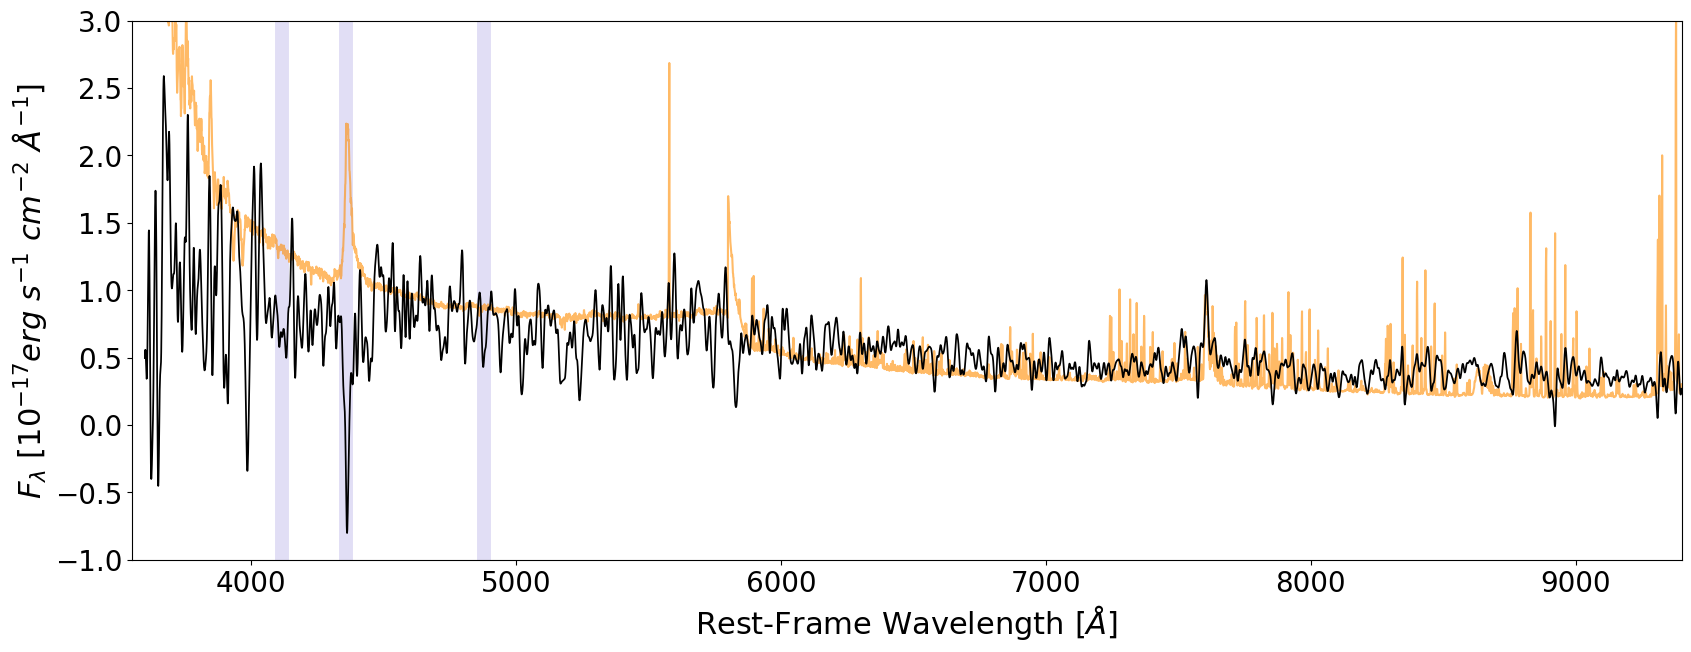

In [445]:
zred_cdw1 = 1222/299792


plt.figure(figsize = (20, 7))
# Plot the combined spectrum in maroon
# plt.plot(spec_combined.wave['brz'], spec_combined.flux['brz'][0], color = 'grey', alpha = 0.6)
plt.plot(spec_combined.wave['brz'], 1/np.sqrt(spec_combined.ivar['brz'][0]),color = "darkorange",alpha = 0.6)
# Over-plotting smoothed spectra 
plt.plot(spec_combined.wave['brz'], convolve(spec_combined.flux['brz'][0], Gaussian1DKernel(5)) , color = 'k', lw = 1.25)


## we need to plot the restframe lines here
plt.vlines(x = hbeta_w*(1+zred_cdw1), ymin = -1,ymax = 15,lw = 10,alpha = 0.2,ls = "-",color ="slateblue",zorder = -10)
plt.vlines(x = hgamma_w*(1+zred_cdw1), ymin = -1,ymax = 15,lw = 10,alpha = 0.2,ls = "-",color ="slateblue",zorder = -10)
plt.vlines(x = hdelta_w*(1+zred_cdw1), ymin = -1,ymax = 15,lw = 10,alpha = 0.2,ls = "-",color ="slateblue",zorder = -10)

plt.xlim([3550, 9400])
plt.ylim([-1,3])
plt.xlabel('Rest-Frame Wavelength [$\AA$]',fontsize = 22)
plt.ylabel('$F_{\lambda}$ [$10^{-17} erg\ s^{-1}\ cm^{-2}\ \AA^{-1}$]',fontsize = 22)
plt.xticks(fontsize = 20)
plt.yticks(fontsize = 20)
plt.show()